In [130]:
#masukan data set yang kita bbutuh kan

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
data_model = pd.read_csv('student_burnout_raw.csv')
data_model.head(10) #MELIAHT 10 DATA TERATAS

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,...,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk,stress_group,support_group,age_group
0,19,Male,3,2.030106,4.138178,69.017263,2.484045,2.496214,0.895800,6.562231,...,5.370280,7.070916,5.291764,0.160748,7.988778,Low,0.263191,High (8-10),Medium (4-7),<20
1,24,Male,2,4.741128,4.987684,72.490227,4.629141,2.398246,0.311902,6.834371,...,7.403425,4.061701,6.661210,0.485187,7.335299,Low,1.746935,Medium (4-7),Low (0-3),>23
2,18,Female,2,2.012132,5.128034,57.920845,3.132996,2.536153,0.000000,3.479124,...,5.560717,4.929563,4.948017,1.510606,7.985956,Low,1.367676,Medium (4-7),Medium (4-7),<20
3,29,Other,1,1.593905,3.634422,63.143634,3.665429,2.012320,0.000000,6.173479,...,6.737295,3.934302,6.985398,0.782130,7.930132,Low,0.000000,Medium (4-7),Medium (4-7),>23
4,27,Female,2,4.255324,7.106627,69.115354,1.788327,1.658673,0.000000,8.413767,...,4.095589,4.292705,4.710767,0.000000,8.787067,Low,1.963668,Medium (4-7),Medium (4-7),>23
5,26,Male,3,7.002016,7.897296,64.456575,5.078230,3.261736,1.259023,5.366262,...,8.279764,6.723999,3.563869,2.328771,6.612480,Low,1.467832,Medium (4-7),Medium (4-7),>23
6,22,Female,3,5.382034,6.692248,76.186627,3.551074,3.031946,3.264998,7.761519,...,2.485125,4.459492,6.554645,0.817123,6.690487,Low,2.044025,Medium (4-7),Medium (4-7),21-23
7,27,Female,3,8.678087,8.611009,68.079281,5.839613,3.941571,1.862585,7.119970,...,7.942189,7.599492,7.646842,3.968801,5.922908,Medium,3.020217,High (8-10),Medium (4-7),>23
8,29,Female,1,5.450319,6.672775,66.641212,7.726995,6.190140,1.509069,7.348032,...,3.179531,10.000000,5.132639,5.072452,4.599439,Medium,3.338520,High (8-10),Medium (4-7),>23
9,28,Female,1,5.210264,5.837993,72.034783,6.777654,4.483352,2.564990,5.353140,...,5.120947,8.319975,3.261639,2.902750,5.174436,Low,1.503363,High (8-10),Medium (4-7),>23


In [131]:
#data clanning
data_model.info() #melihat informasi tentang data set kita
data_model.describe() #melihat statistik data seprti mean, median, juumlah data, data unique, dll

#non-null dalam data_model adalah 1000, artinya tidak ada data yang kosong atau null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   2000 non-null   int64  
 1   gender                2000 non-null   object 
 2   academic_year         2000 non-null   int64  
 3   study_hours_per_day   2000 non-null   float64
 4   exam_pressure         2000 non-null   float64
 5   academic_performance  2000 non-null   float64
 6   stress_level          2000 non-null   float64
 7   anxiety_score         2000 non-null   float64
 8   depression_score      2000 non-null   float64
 9   sleep_hours           2000 non-null   float64
 10  physical_activity     2000 non-null   float64
 11  social_support        2000 non-null   float64
 12  screen_time           2000 non-null   float64
 13  internet_usage        2000 non-null   float64
 14  financial_stress      2000 non-null   float64
 15  family_expectation   

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,23.123500,2.496500,5.053696,6.013848,71.188627,4.249693,2.998652,1.210566,6.494371,3.035811,5.062296,5.022895,5.053038,4.960860,6.015235,1.777939,7.037357,1.284941
std,3.751304,1.124553,1.972440,1.515496,5.771210,1.693113,1.512283,1.182801,1.468596,1.475617,1.976939,1.946190,2.167219,2.000509,1.930282,1.646959,1.309188,1.319340
min,17.000000,1.000000,0.000000,1.000000,51.152841,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.322454,0.000000
25%,20.000000,1.000000,3.801194,4.963589,67.174415,3.066673,1.915644,0.000000,5.456508,2.006190,3.732100,3.607011,3.459713,3.586155,4.702690,0.113956,6.144697,0.000000
50%,23.000000,2.000000,5.058053,6.035416,71.146992,4.239276,2.978928,0.975916,6.508586,2.998184,5.016462,4.957523,5.014610,4.929497,6.027004,1.501155,7.105498,0.967882
75%,26.000000,4.000000,6.291511,7.056786,75.161810,5.433716,4.056862,2.024659,7.489788,4.047712,6.389969,6.381985,6.574857,6.309095,7.372487,2.905624,8.000931,2.074059
max,29.000000,4.000000,11.020377,10.000000,89.324159,9.776181,7.732529,6.745497,10.000000,7.000000,10.000000,11.410409,12.075746,10.000000,10.000000,8.784325,10.000000,6.927563


In [132]:
data_model.isnull().sum() #melihat missing value pada data set kita


age                     0
gender                  0
academic_year           0
study_hours_per_day     0
exam_pressure           0
academic_performance    0
stress_level            0
anxiety_score           0
depression_score        0
sleep_hours             0
physical_activity       0
social_support          0
screen_time             0
internet_usage          0
financial_stress        0
family_expectation      0
burnout_score           0
mental_health_index     0
risk_level              0
dropout_risk            0
stress_group            0
support_group           0
age_group               0
dtype: int64

In [133]:
data_model.duplicated().sum() #melihat data duplikat

0

In [134]:
data_model.isna().sum() #melihat data yang kosong

age                     0
gender                  0
academic_year           0
study_hours_per_day     0
exam_pressure           0
academic_performance    0
stress_level            0
anxiety_score           0
depression_score        0
sleep_hours             0
physical_activity       0
social_support          0
screen_time             0
internet_usage          0
financial_stress        0
family_expectation      0
burnout_score           0
mental_health_index     0
risk_level              0
dropout_risk            0
stress_group            0
support_group           0
age_group               0
dtype: int64

In [135]:
data_model.describe()

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,23.123500,2.496500,5.053696,6.013848,71.188627,4.249693,2.998652,1.210566,6.494371,3.035811,5.062296,5.022895,5.053038,4.960860,6.015235,1.777939,7.037357,1.284941
std,3.751304,1.124553,1.972440,1.515496,5.771210,1.693113,1.512283,1.182801,1.468596,1.475617,1.976939,1.946190,2.167219,2.000509,1.930282,1.646959,1.309188,1.319340
min,17.000000,1.000000,0.000000,1.000000,51.152841,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.322454,0.000000
25%,20.000000,1.000000,3.801194,4.963589,67.174415,3.066673,1.915644,0.000000,5.456508,2.006190,3.732100,3.607011,3.459713,3.586155,4.702690,0.113956,6.144697,0.000000
50%,23.000000,2.000000,5.058053,6.035416,71.146992,4.239276,2.978928,0.975916,6.508586,2.998184,5.016462,4.957523,5.014610,4.929497,6.027004,1.501155,7.105498,0.967882
75%,26.000000,4.000000,6.291511,7.056786,75.161810,5.433716,4.056862,2.024659,7.489788,4.047712,6.389969,6.381985,6.574857,6.309095,7.372487,2.905624,8.000931,2.074059
max,29.000000,4.000000,11.020377,10.000000,89.324159,9.776181,7.732529,6.745497,10.000000,7.000000,10.000000,11.410409,12.075746,10.000000,10.000000,8.784325,10.000000,6.927563


In [136]:
data_model.info() #melihat informasi tentang data set kita setelah menghapus kolom student_id

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   2000 non-null   int64  
 1   gender                2000 non-null   object 
 2   academic_year         2000 non-null   int64  
 3   study_hours_per_day   2000 non-null   float64
 4   exam_pressure         2000 non-null   float64
 5   academic_performance  2000 non-null   float64
 6   stress_level          2000 non-null   float64
 7   anxiety_score         2000 non-null   float64
 8   depression_score      2000 non-null   float64
 9   sleep_hours           2000 non-null   float64
 10  physical_activity     2000 non-null   float64
 11  social_support        2000 non-null   float64
 12  screen_time           2000 non-null   float64
 13  internet_usage        2000 non-null   float64
 14  financial_stress      2000 non-null   float64
 15  family_expectation   

In [137]:
data_model.tail(10) #melihat 10 data terakhir pada data set kita

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,...,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk,stress_group,support_group,age_group
1990,26,Other,1,2.661739,4.005875,71.193228,5.225024,3.191265,0.000000,5.718882,...,3.763120,7.625480,7.397306,1.543798,6.952611,Low,0.931404,High (8-10),Medium (4-7),>23
1991,26,Male,1,0.000000,3.288162,66.621626,1.517959,1.492499,1.665530,7.243762,...,4.206389,4.056007,4.192712,0.000000,8.445408,Low,2.289764,Medium (4-7),Low (0-3),>23
1992,29,Male,3,9.236402,8.668191,78.346931,7.828165,5.818298,1.424631,10.000000,...,7.638234,6.802757,6.258004,2.572676,4.695855,Low,0.000000,Medium (4-7),High (8-10),>23
1993,28,Female,4,4.875906,6.836809,69.126434,2.733395,1.770744,0.000000,6.717986,...,7.012966,2.726663,4.358595,1.006501,8.375419,Low,0.000000,Low (0-3),High (8-10),>23
1994,29,Male,3,6.442307,7.619866,72.496907,6.894488,5.388334,3.092573,4.234607,...,4.727129,3.162430,4.646392,4.804762,4.697933,Medium,3.488436,Medium (4-7),Medium (4-7),>23
1995,20,Male,3,5.046854,6.509467,76.495152,5.914936,3.725848,0.000000,6.935516,...,3.185790,3.677964,8.736169,1.050638,6.516271,Low,0.000000,Medium (4-7),High (8-10),<20
1996,27,Female,1,5.168423,5.301932,82.134368,1.936337,1.803376,0.000000,7.507755,...,7.246669,3.391842,3.030248,0.000000,8.684453,Low,0.149530,Medium (4-7),Medium (4-7),>23
1997,19,Female,3,7.853043,7.798159,74.453620,6.028182,5.334227,0.190828,5.083215,...,5.880860,5.629893,9.223472,3.153890,5.931211,Medium,1.131410,Medium (4-7),High (8-10),<20
1998,19,Other,3,4.164175,5.387199,66.475274,5.421578,4.192139,2.931390,5.485738,...,6.758295,4.138668,5.628551,3.848633,5.694310,Medium,2.252356,Medium (4-7),Low (0-3),<20
1999,22,Female,1,3.862623,4.556952,66.449296,1.683297,0.607336,0.000000,6.914701,...,1.715952,5.927354,5.601050,0.000000,9.144480,Low,0.156173,Medium (4-7),High (8-10),21-23


In [138]:
data_model.describe() #melihat statistika dalam data set kita

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,23.123500,2.496500,5.053696,6.013848,71.188627,4.249693,2.998652,1.210566,6.494371,3.035811,5.062296,5.022895,5.053038,4.960860,6.015235,1.777939,7.037357,1.284941
std,3.751304,1.124553,1.972440,1.515496,5.771210,1.693113,1.512283,1.182801,1.468596,1.475617,1.976939,1.946190,2.167219,2.000509,1.930282,1.646959,1.309188,1.319340
min,17.000000,1.000000,0.000000,1.000000,51.152841,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.322454,0.000000
25%,20.000000,1.000000,3.801194,4.963589,67.174415,3.066673,1.915644,0.000000,5.456508,2.006190,3.732100,3.607011,3.459713,3.586155,4.702690,0.113956,6.144697,0.000000
50%,23.000000,2.000000,5.058053,6.035416,71.146992,4.239276,2.978928,0.975916,6.508586,2.998184,5.016462,4.957523,5.014610,4.929497,6.027004,1.501155,7.105498,0.967882
75%,26.000000,4.000000,6.291511,7.056786,75.161810,5.433716,4.056862,2.024659,7.489788,4.047712,6.389969,6.381985,6.574857,6.309095,7.372487,2.905624,8.000931,2.074059
max,29.000000,4.000000,11.020377,10.000000,89.324159,9.776181,7.732529,6.745497,10.000000,7.000000,10.000000,11.410409,12.075746,10.000000,10.000000,8.784325,10.000000,6.927563


In [139]:
data_model.isna().sum() #melihat data yang kosong pada data set kita


age                     0
gender                  0
academic_year           0
study_hours_per_day     0
exam_pressure           0
academic_performance    0
stress_level            0
anxiety_score           0
depression_score        0
sleep_hours             0
physical_activity       0
social_support          0
screen_time             0
internet_usage          0
financial_stress        0
family_expectation      0
burnout_score           0
mental_health_index     0
risk_level              0
dropout_risk            0
stress_group            0
support_group           0
age_group               0
dtype: int64

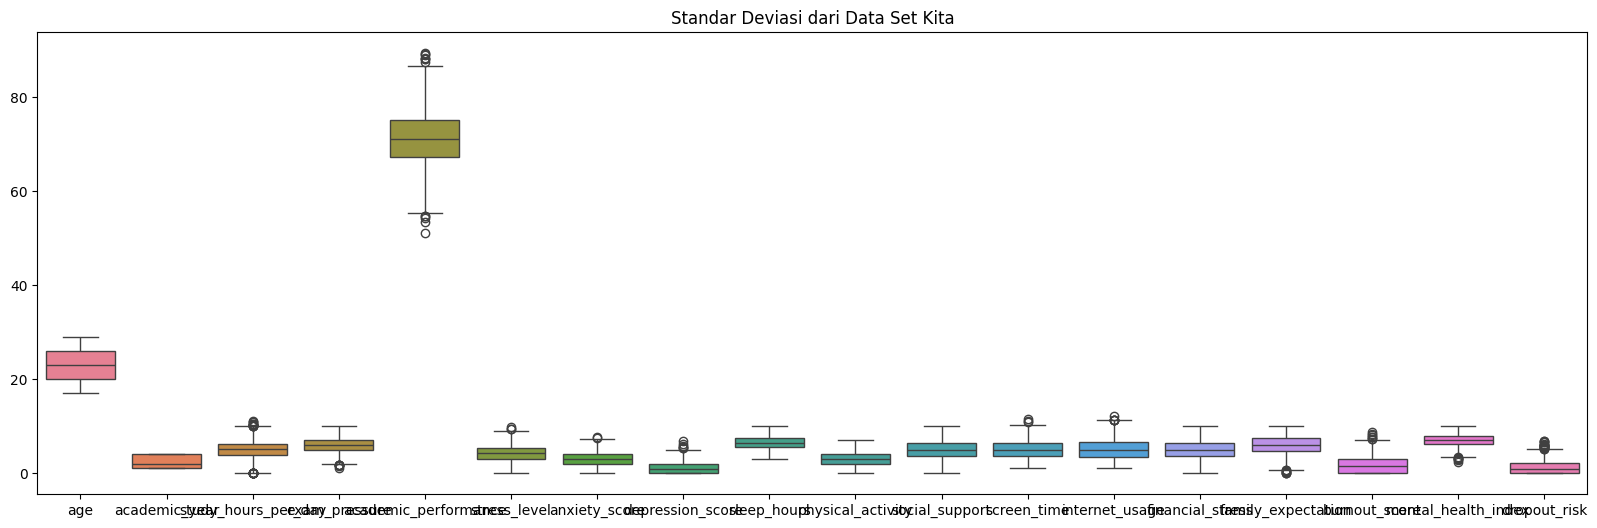

In [140]:
plt.figure(figsize=(20,6))
plt.title('Standar Deviasi dari Data Set Kita')
sns.boxplot(data=data_model)
plt.show() #melihat boxplot dari data set kita

In [141]:

data_object = data_model.select_dtypes(include='object') #melihat data yang bertipe object pada data set kita
#menampilkan data yang bertipe object pada data set kita
print(data_object)

      gender risk_level  stress_group support_group age_group
0       Male        Low   High (8-10)  Medium (4-7)       <20
1       Male        Low  Medium (4-7)     Low (0-3)       >23
2     Female        Low  Medium (4-7)  Medium (4-7)       <20
3      Other        Low  Medium (4-7)  Medium (4-7)       >23
4     Female        Low  Medium (4-7)  Medium (4-7)       >23
...      ...        ...           ...           ...       ...
1995    Male        Low  Medium (4-7)   High (8-10)       <20
1996  Female        Low  Medium (4-7)  Medium (4-7)       >23
1997  Female     Medium  Medium (4-7)   High (8-10)       <20
1998   Other     Medium  Medium (4-7)     Low (0-3)       <20
1999  Female        Low  Medium (4-7)   High (8-10)     21-23

[2000 rows x 5 columns]


In [142]:
for i in data_object.columns:
   print(f'====== distribusi frekuensi dari vareabel {i} ======')
   print(data_object[i].value_counts())

====== distribusi frekuensi dari vareabel gender ======
gender
Male      968
Female    960
Other      72
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel risk_level ======
risk_level
Low       1529
Medium     447
High        24
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel stress_group ======
stress_group
Medium (4-7)    1356
Low (0-3)        333
High (8-10)      311
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel support_group ======
support_group
Medium (4-7)    1369
High (8-10)      334
Low (0-3)        297
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel age_group ======
age_group
>23      959
<20      593
21-23    448
Name: count, dtype: int64


In [143]:
data_numerik = data_model.select_dtypes(include=['float64', 'int64']) #melihat data yang bertipe numerik pada data set kita
print(data_numerik) #melihat 10 data teratas pada data numerik


      age  academic_year  study_hours_per_day  exam_pressure  \
0      19              3             2.030106       4.138178   
1      24              2             4.741128       4.987684   
2      18              2             2.012132       5.128034   
3      29              1             1.593905       3.634422   
4      27              2             4.255324       7.106627   
...   ...            ...                  ...            ...   
1995   20              3             5.046854       6.509467   
1996   27              1             5.168423       5.301932   
1997   19              3             7.853043       7.798159   
1998   19              3             4.164175       5.387199   
1999   22              1             3.862623       4.556952   

      academic_performance  stress_level  anxiety_score  depression_score  \
0                69.017263      2.484045       2.496214          0.895800   
1                72.490227      4.629141       2.398246          0.311902   


In [144]:
for i in data_numerik.columns:
    data_numerik[i].unique() #melihat data unik pada data numerik
    print(f"Data unik pada variabel {i}: {data_numerik[i].unique()}")

Data unik pada variabel age: [19 24 18 29 27 26 22 28 21 17 23 20 25]
Data unik pada variabel academic_year: [3 2 1 4]
Data unik pada variabel study_hours_per_day: [2.03010571 4.74112776 2.01213201 ... 7.85304323 4.16417507 3.86262332]
Data unik pada variabel exam_pressure: [4.13817801 4.98768364 5.12803352 ... 7.79815918 5.38719886 4.55695229]
Data unik pada variabel academic_performance: [69.01726312 72.49022695 57.92084463 ... 74.45361999 66.47527358
 66.44929556]
Data unik pada variabel stress_level: [2.48404457 4.62914099 3.13299571 ... 6.02818163 5.42157819 1.68329673]
Data unik pada variabel anxiety_score: [2.49621443 2.39824574 2.5361531  ... 5.33422696 4.19213855 0.60733635]
Data unik pada variabel depression_score: [0.89579978 0.31190247 0.         ... 3.09257323 0.19082811 2.93139022]
Data unik pada variabel sleep_hours: [6.56223147 6.83437052 3.47912415 ... 5.08321496 5.48573839 6.91470062]
Data unik pada variabel physical_activity: [1.96271399 6.97720413 3.33321585 ... 5.6

In [145]:
#pemisangan data alami dan data yang tidak memiliki makan

batas_dataalami = 15 

data_distrik =[]
data_kontinu = []

for i in data_numerik:
    data_unik = data_numerik[i].nunique()
    if data_unik < batas_dataalami:
        data_distrik.append(i)
    else:
        data_kontinu.append(i)
    print(f' {i}: {data_unik} data unik')

print(f'Data Distrik: {data_distrik}')
print(f'Data Kontinu: {data_kontinu}')


 age: 13 data unik
 academic_year: 4 data unik
 study_hours_per_day: 1986 data unik
 exam_pressure: 1987 data unik
 academic_performance: 2000 data unik
 stress_level: 1989 data unik
 anxiety_score: 1948 data unik
 depression_score: 1466 data unik
 sleep_hours: 1962 data unik
 physical_activity: 1945 data unik
 social_support: 1969 data unik
 screen_time: 1966 data unik
 internet_usage: 1931 data unik
 financial_stress: 1977 data unik
 family_expectation: 1950 data unik
 burnout_score: 1532 data unik
 mental_health_index: 1994 data unik
 dropout_risk: 1476 data unik
Data Distrik: ['age', 'academic_year']
Data Kontinu: ['study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'burnout_score', 'mental_health_index', 'dropout_risk']


In [146]:
for i in data_distrik:
    print(f'====== distribusi frekuensi dari vareabel {i} ======')
    print(data_numerik[i].value_counts())
    

====== distribusi frekuensi dari vareabel age ======
age
27    170
18    163
25    163
28    162
19    157
29    157
24    154
26    153
22    152
23    151
21    145
17    140
20    133
Name: count, dtype: int64
====== distribusi frekuensi dari vareabel academic_year ======
academic_year
4    509
2    506
1    505
3    480
Name: count, dtype: int64


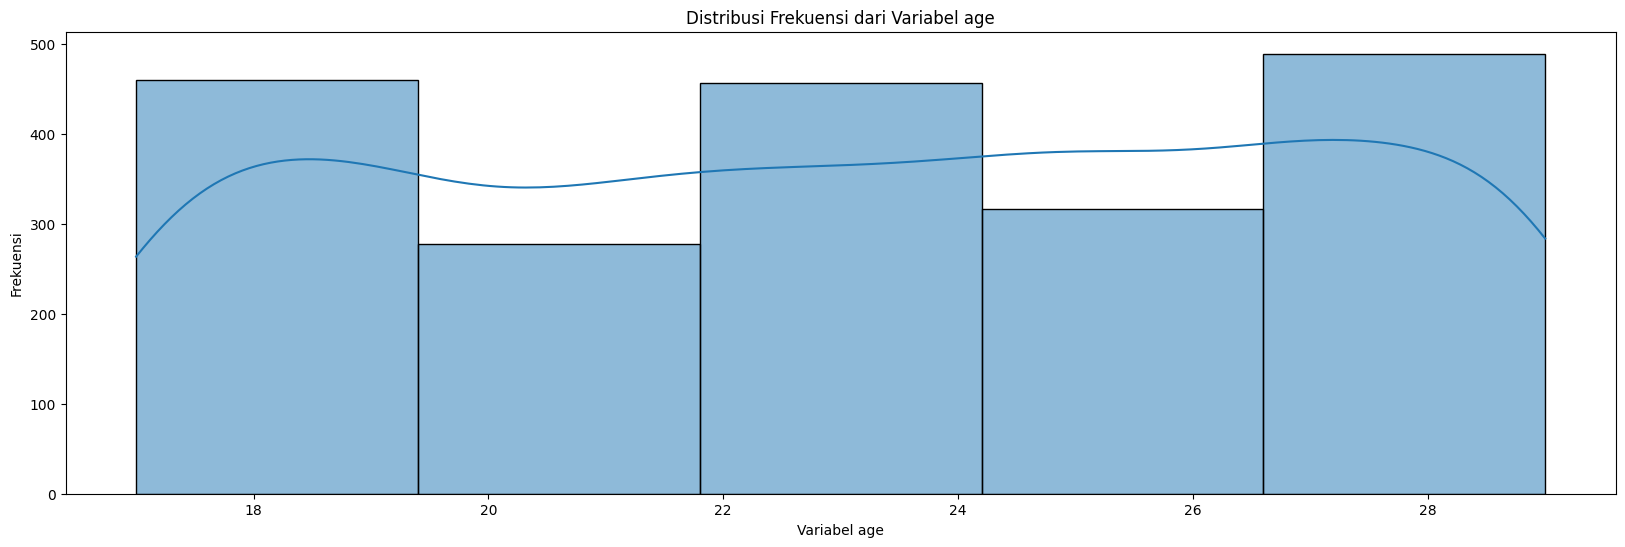

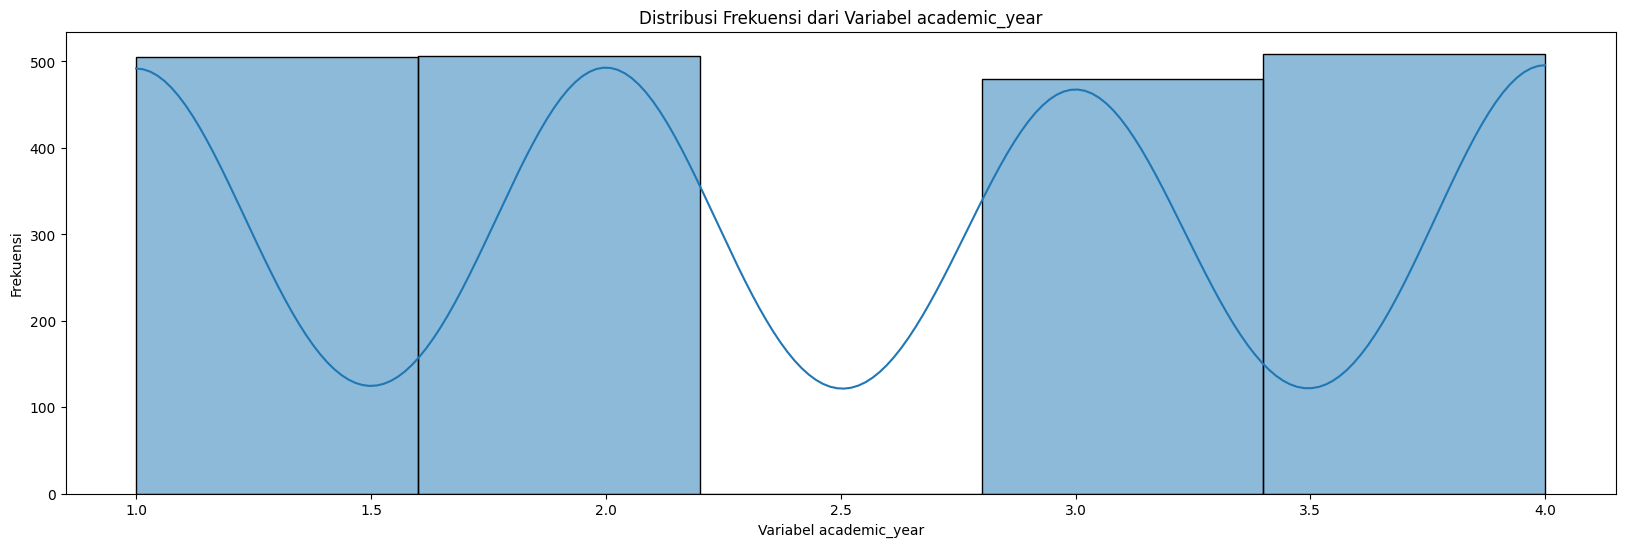

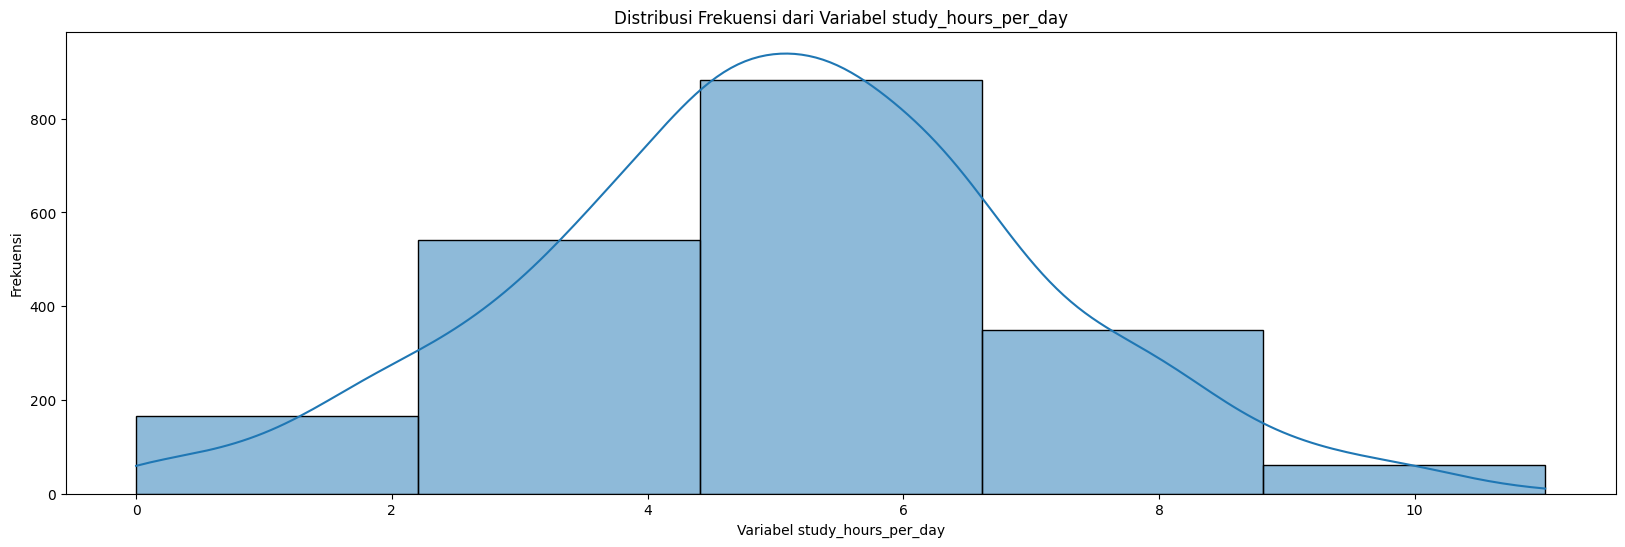

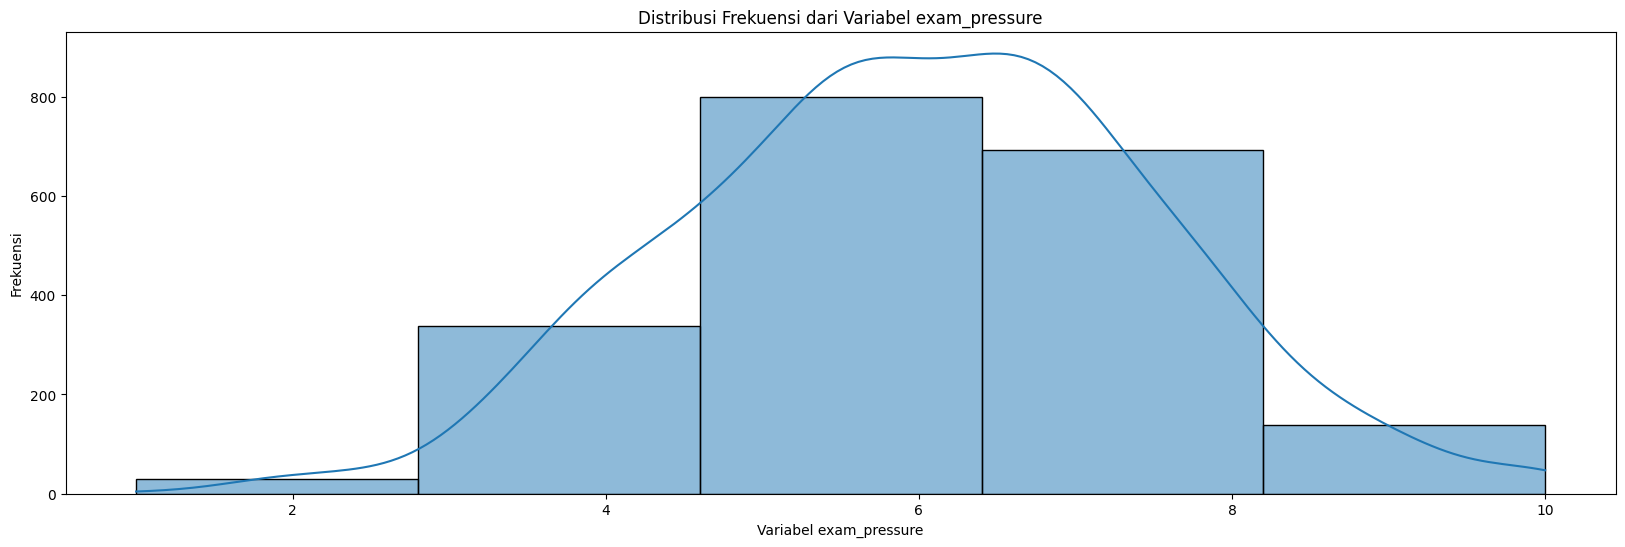

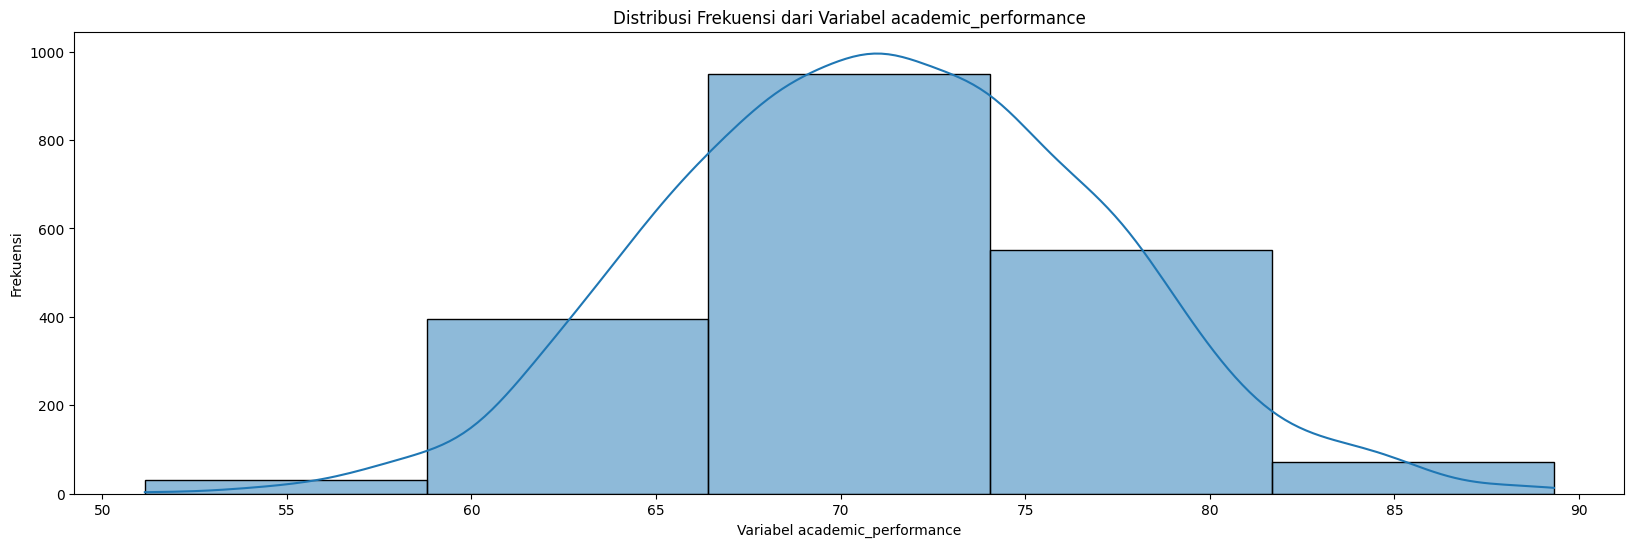

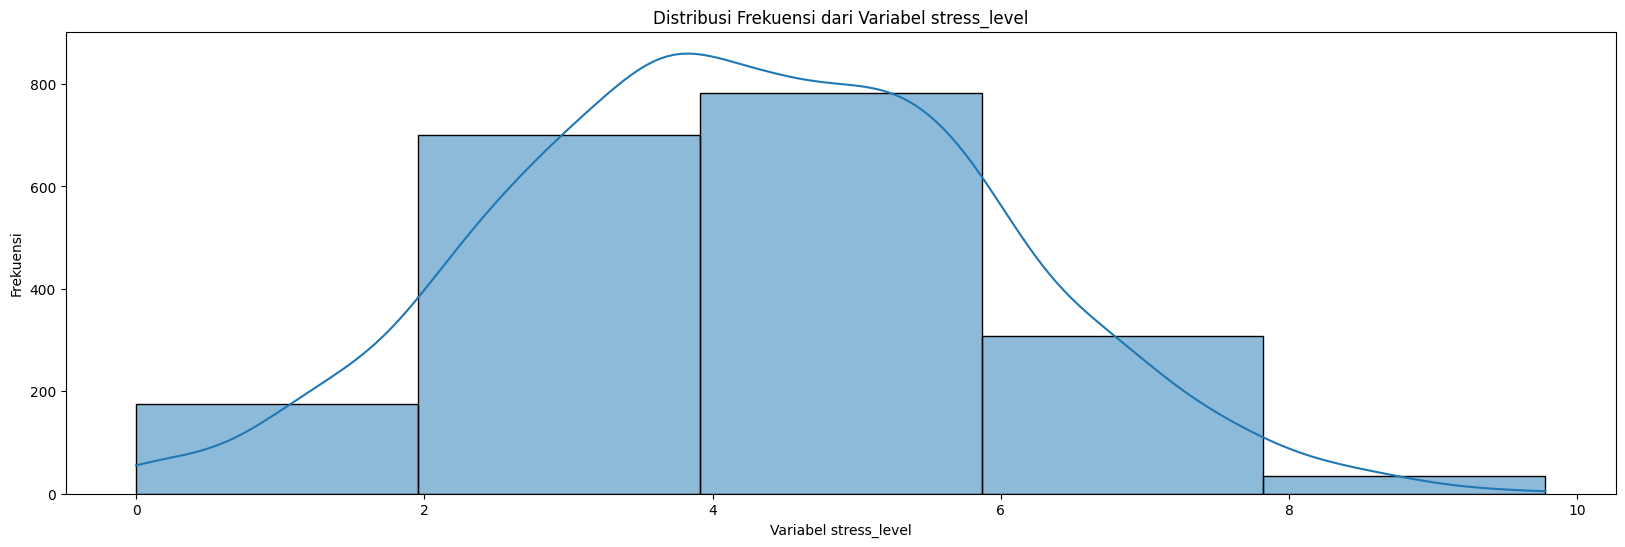

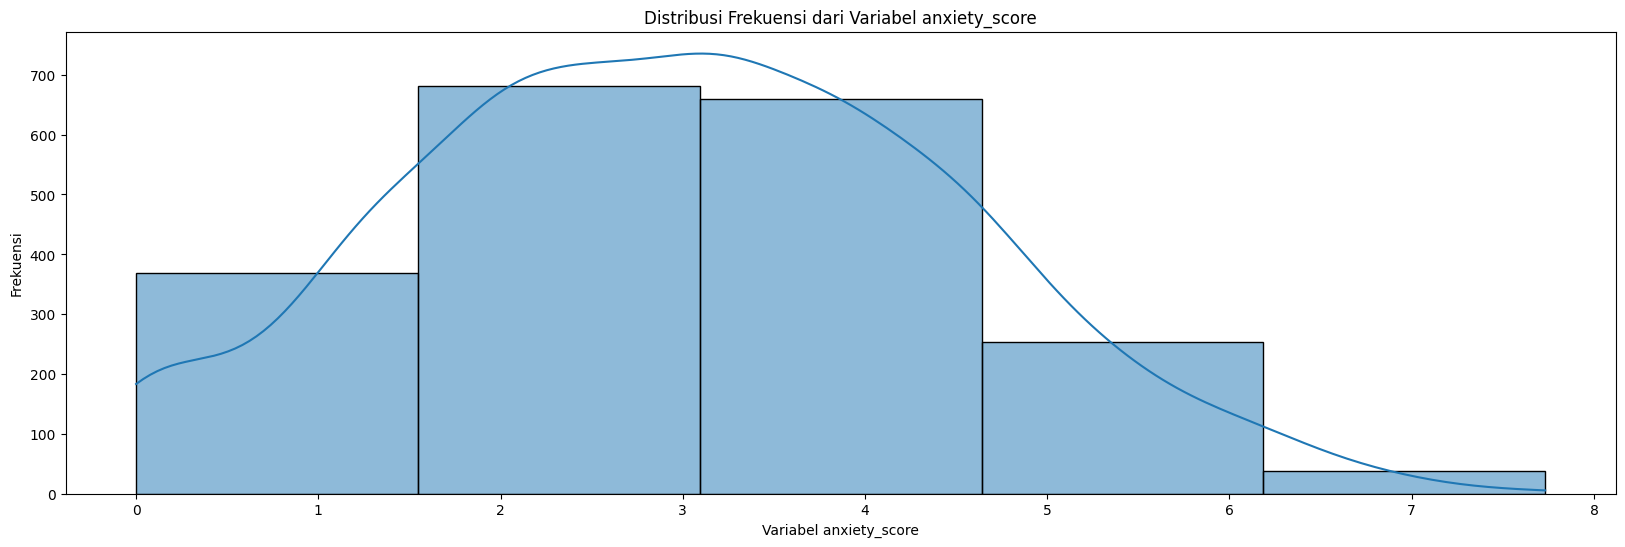

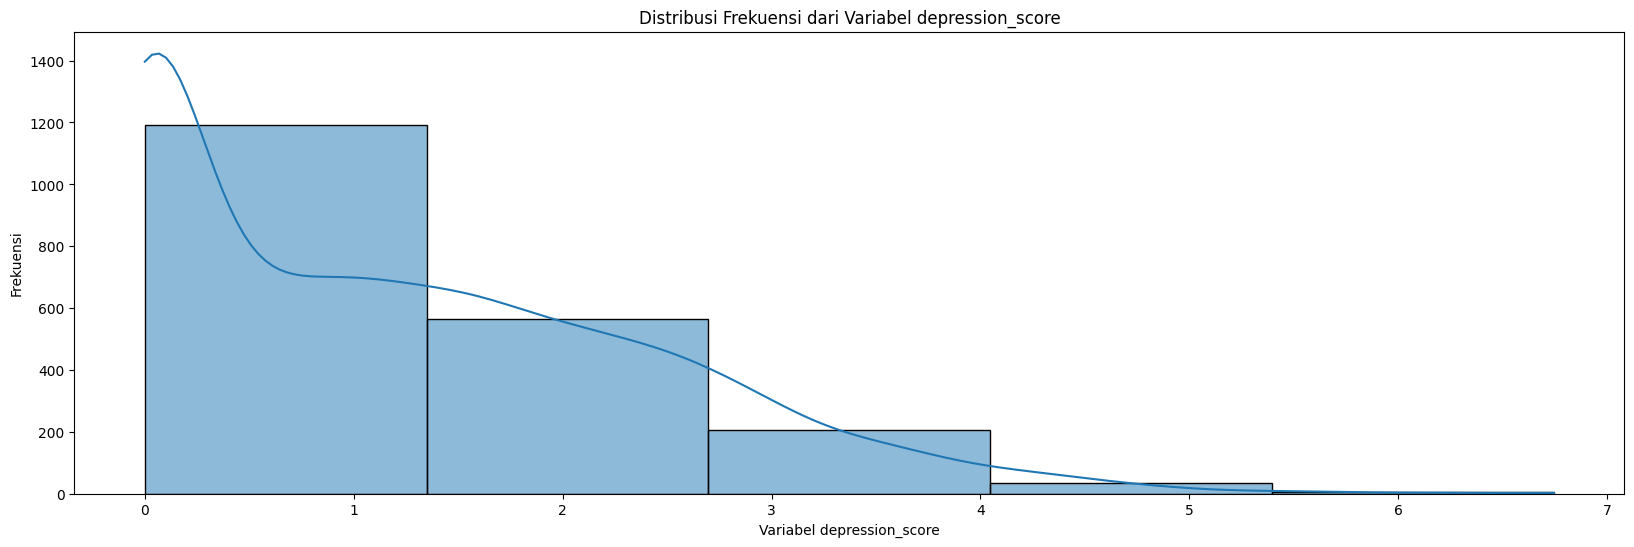

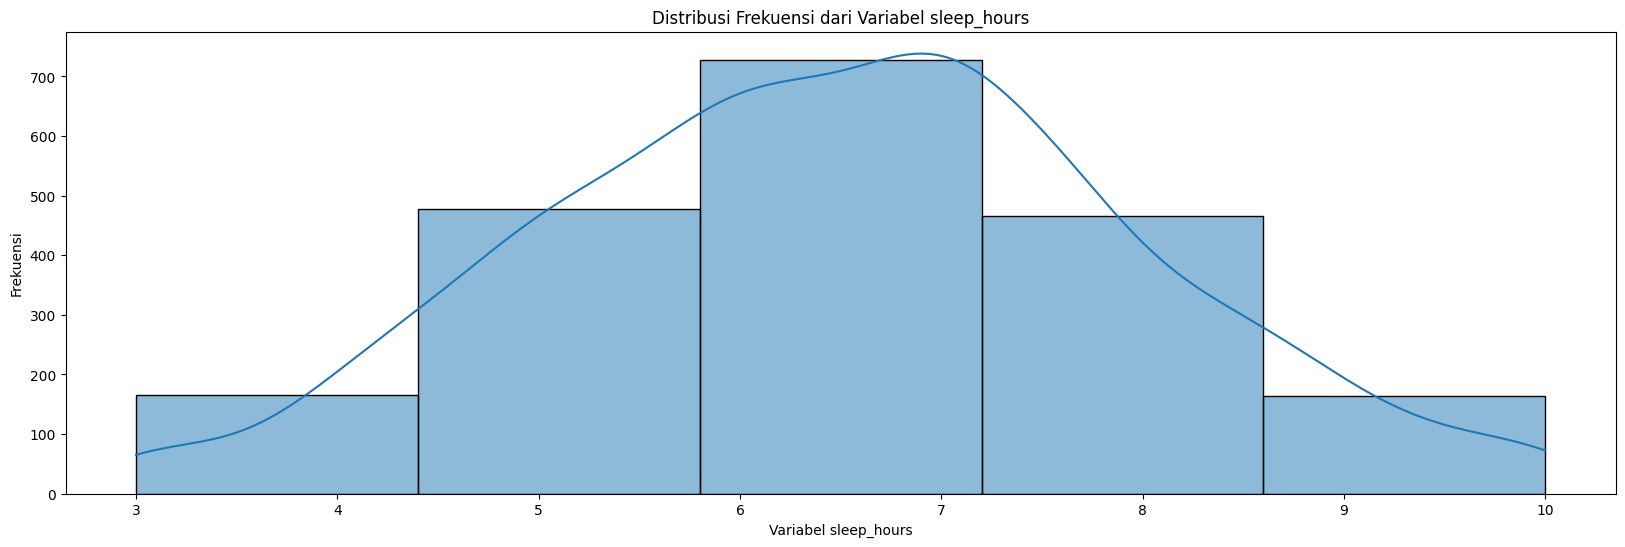

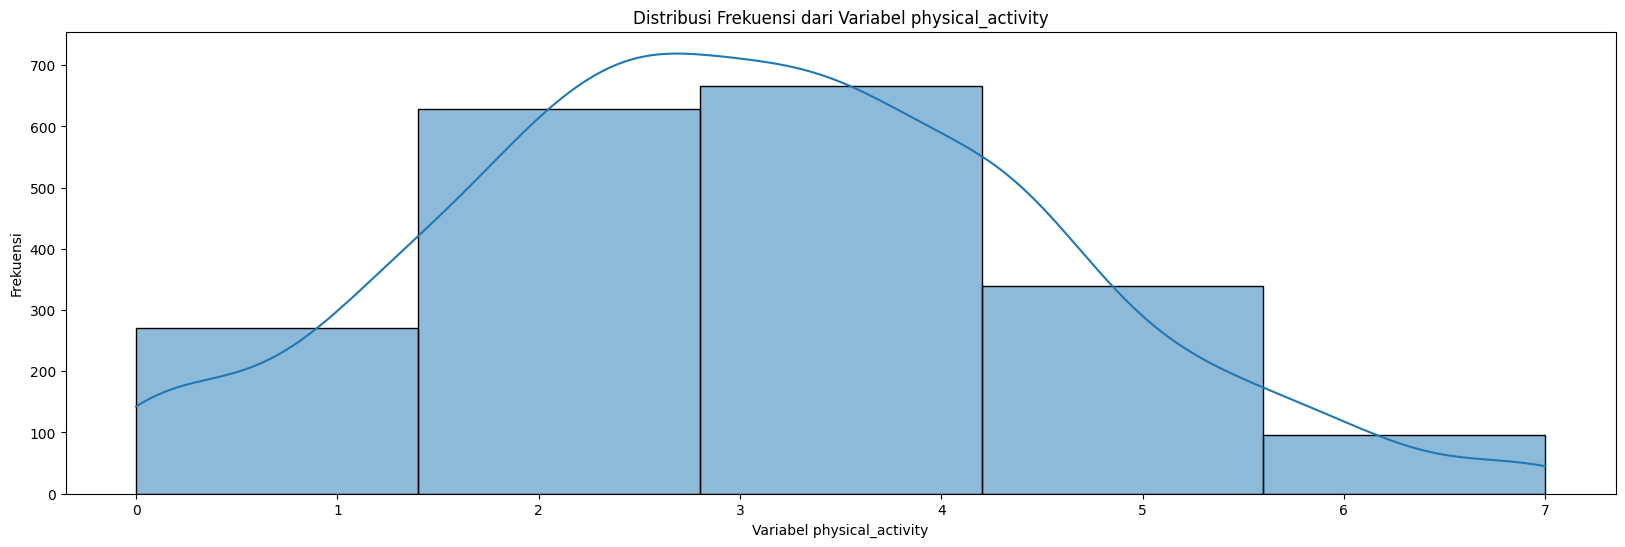

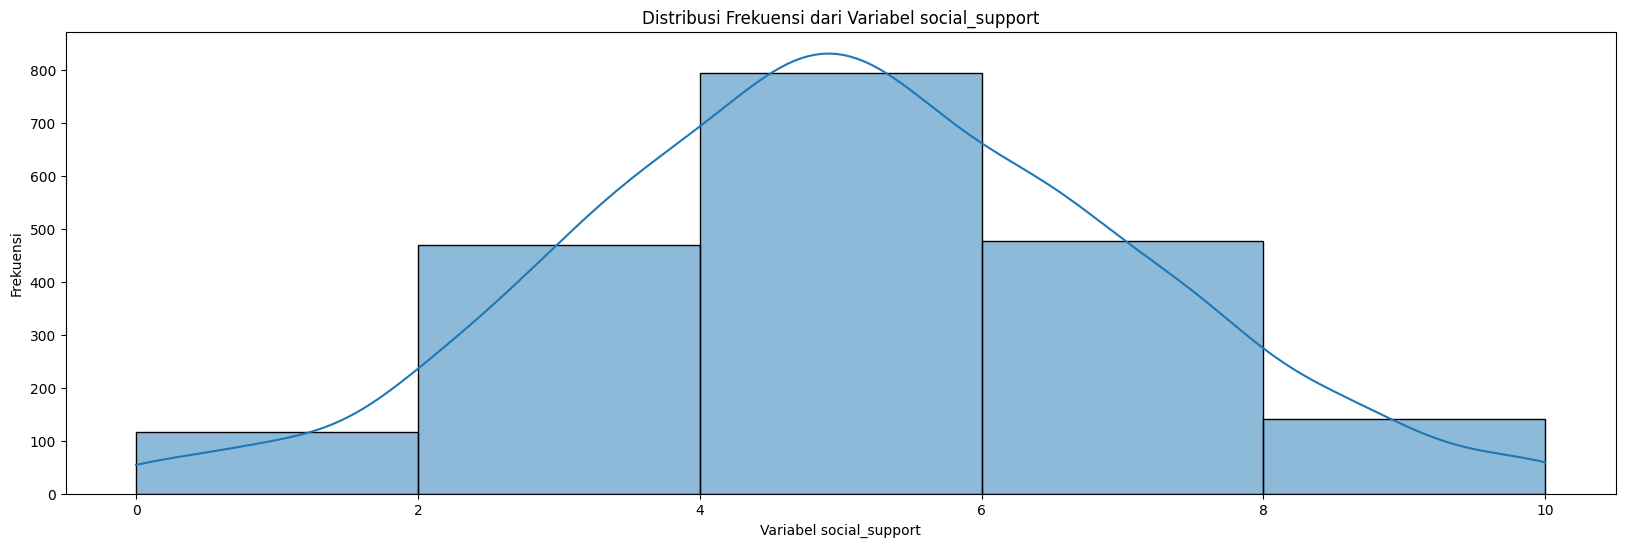

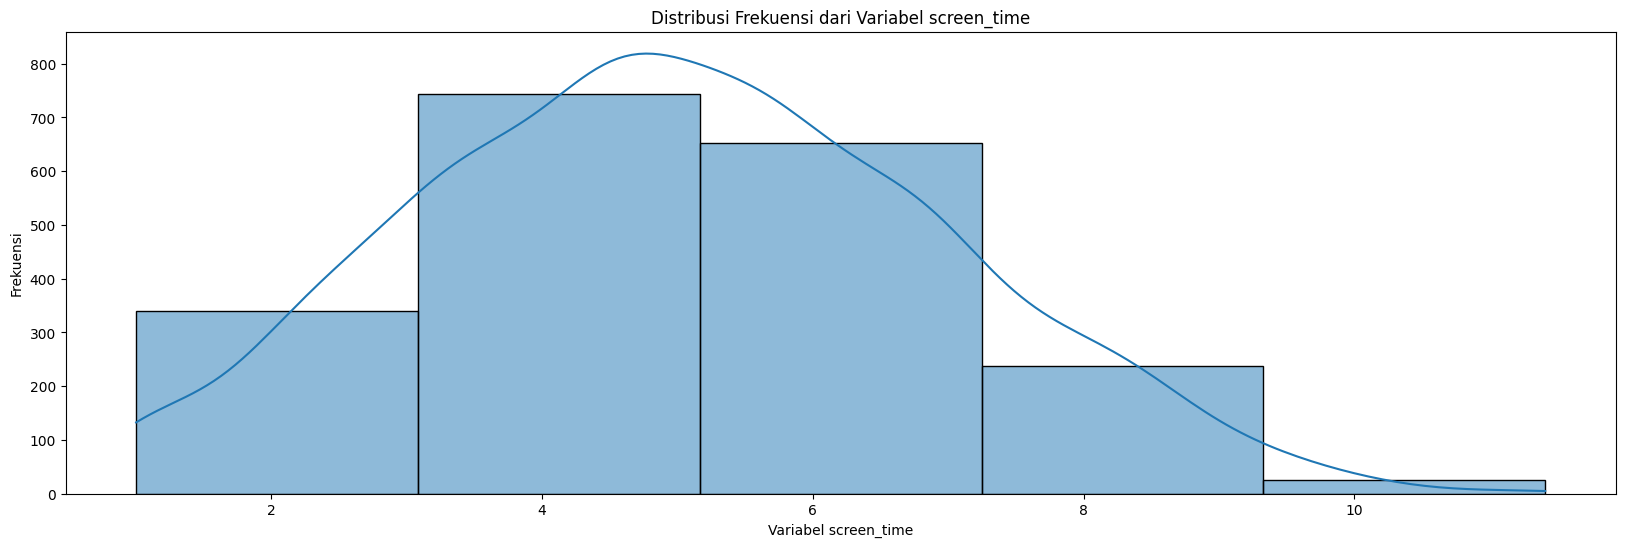

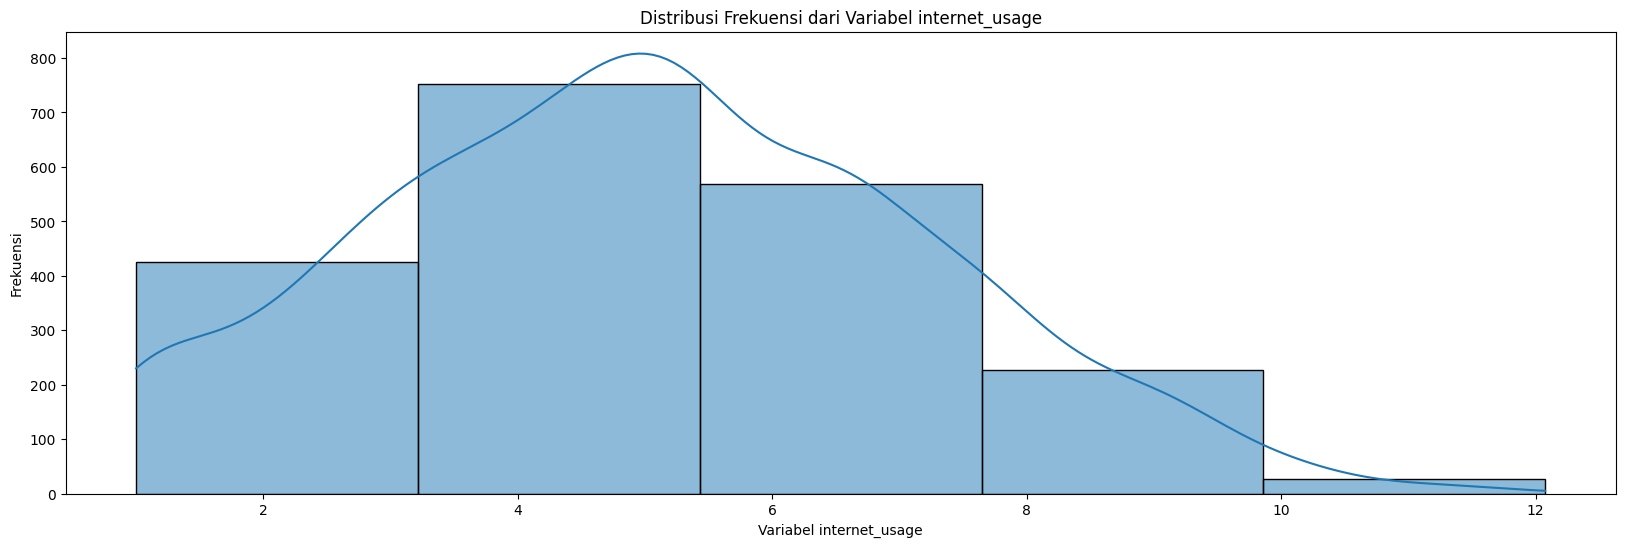

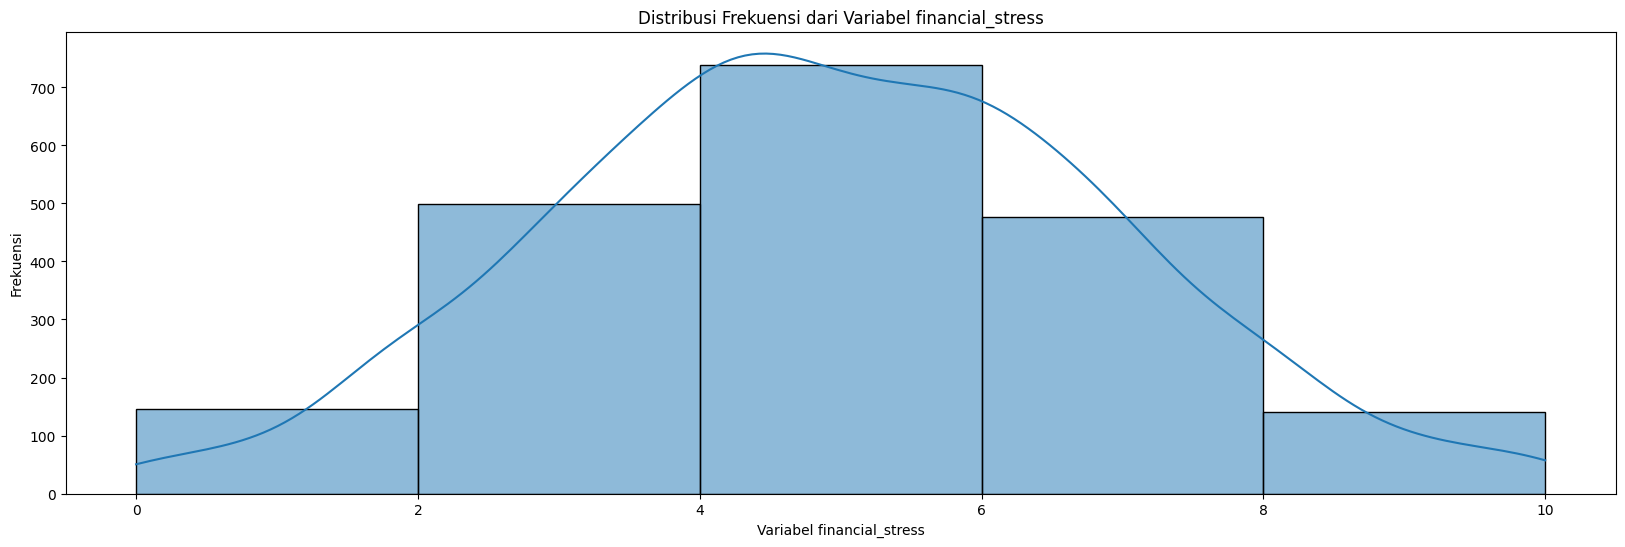

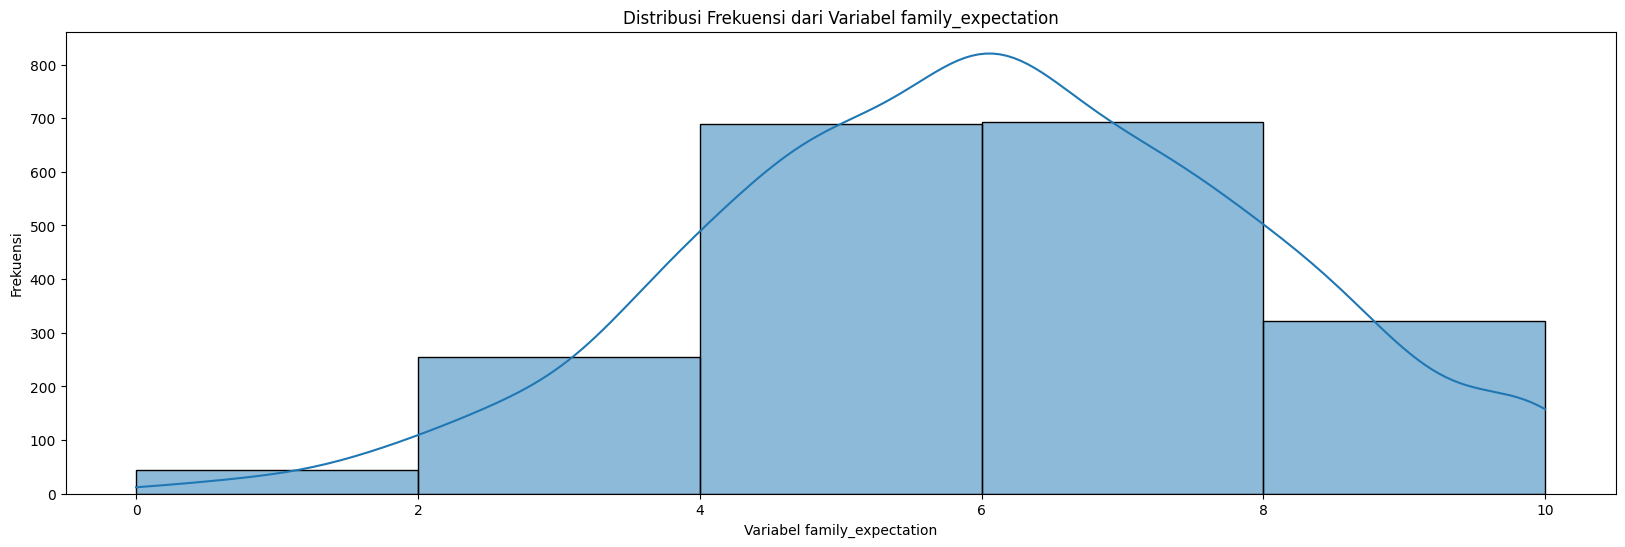

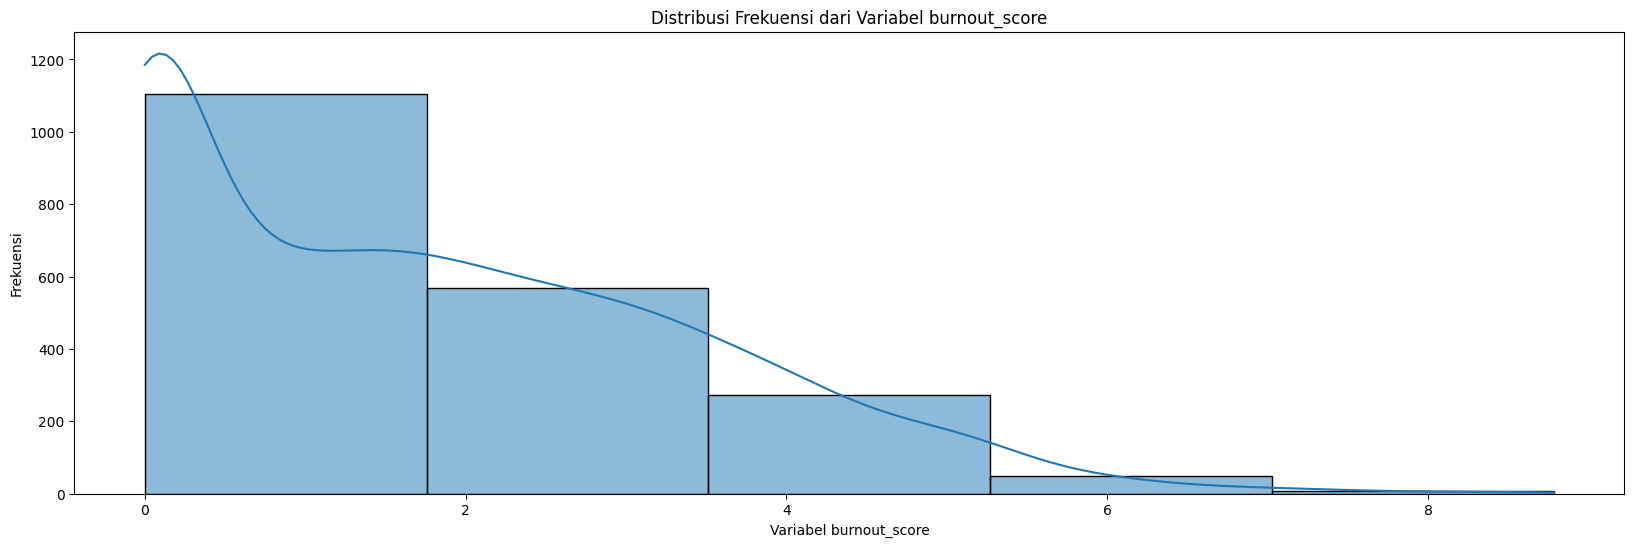

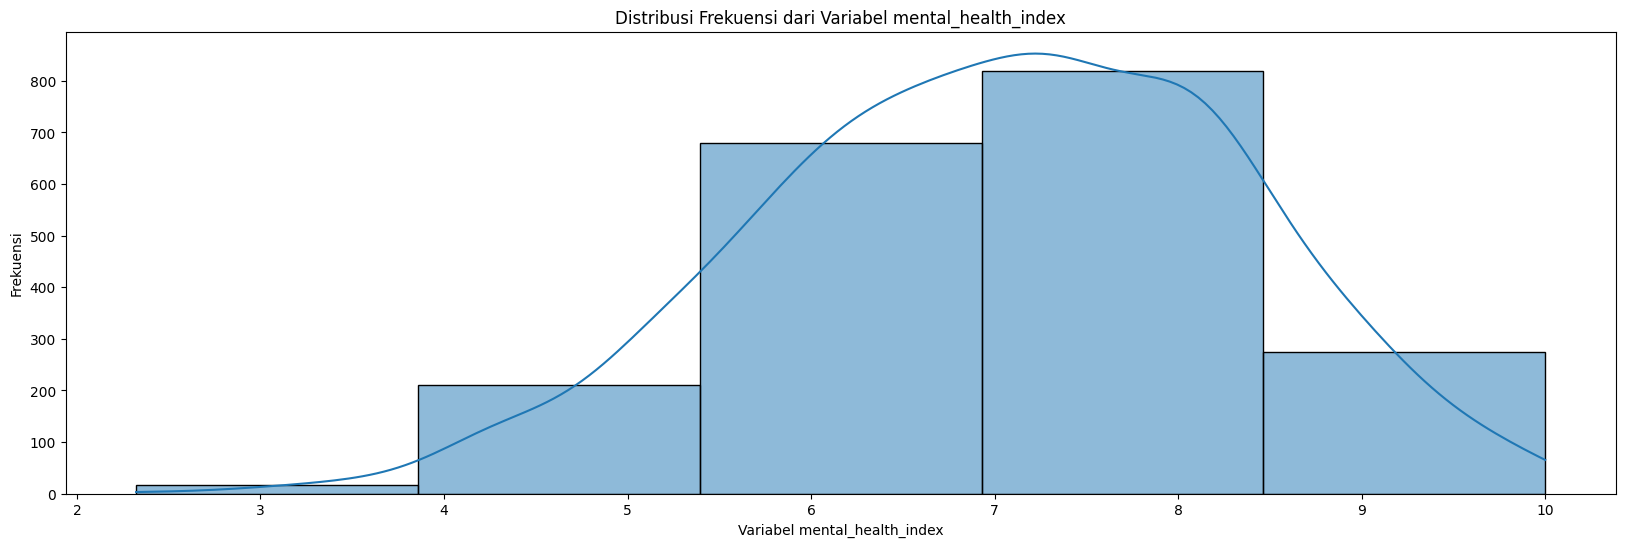

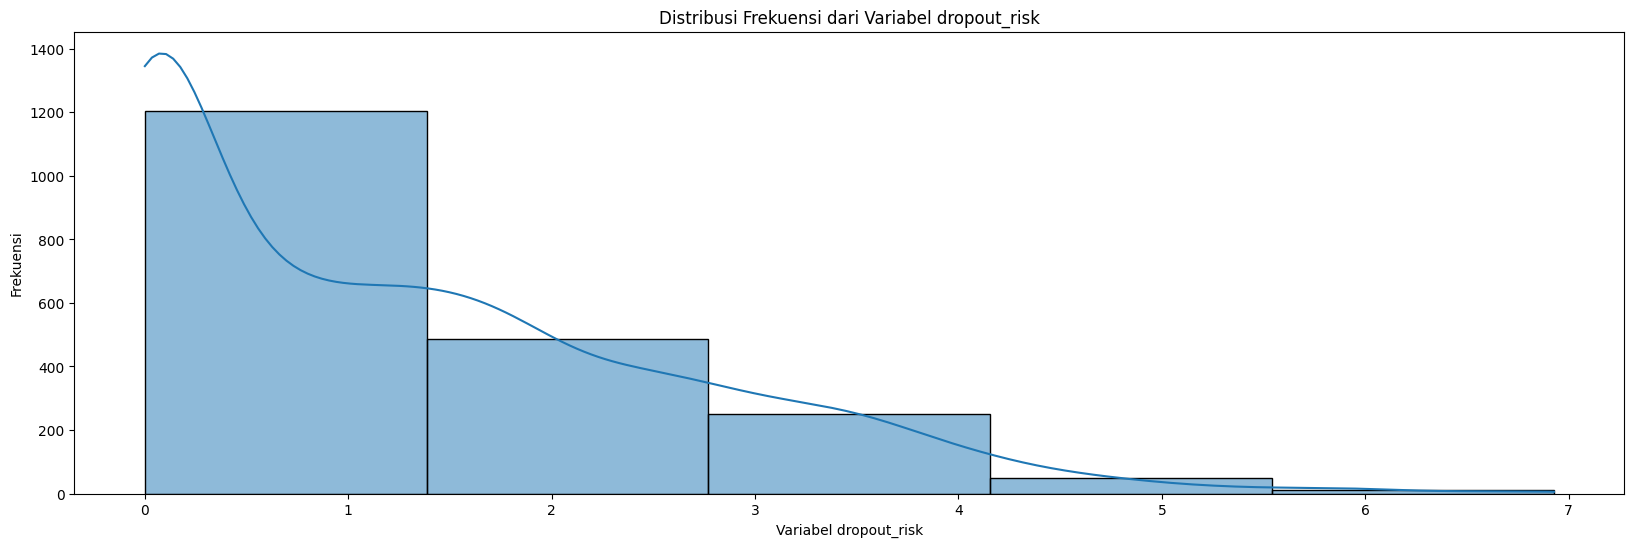

In [147]:
for i in data_numerik:
    plt.figure(figsize=(20,6))
    plt.title(f'Distribusi Frekuensi dari Variabel {i}')
    sns.histplot(data=data_numerik, x=i, bins=5, kde=True)
    plt.xlabel(f'Variabel {i}')
    plt.ylabel('Frekuensi')
    plt.show() #melihat distribusi frekuensi dari data kontinu kita

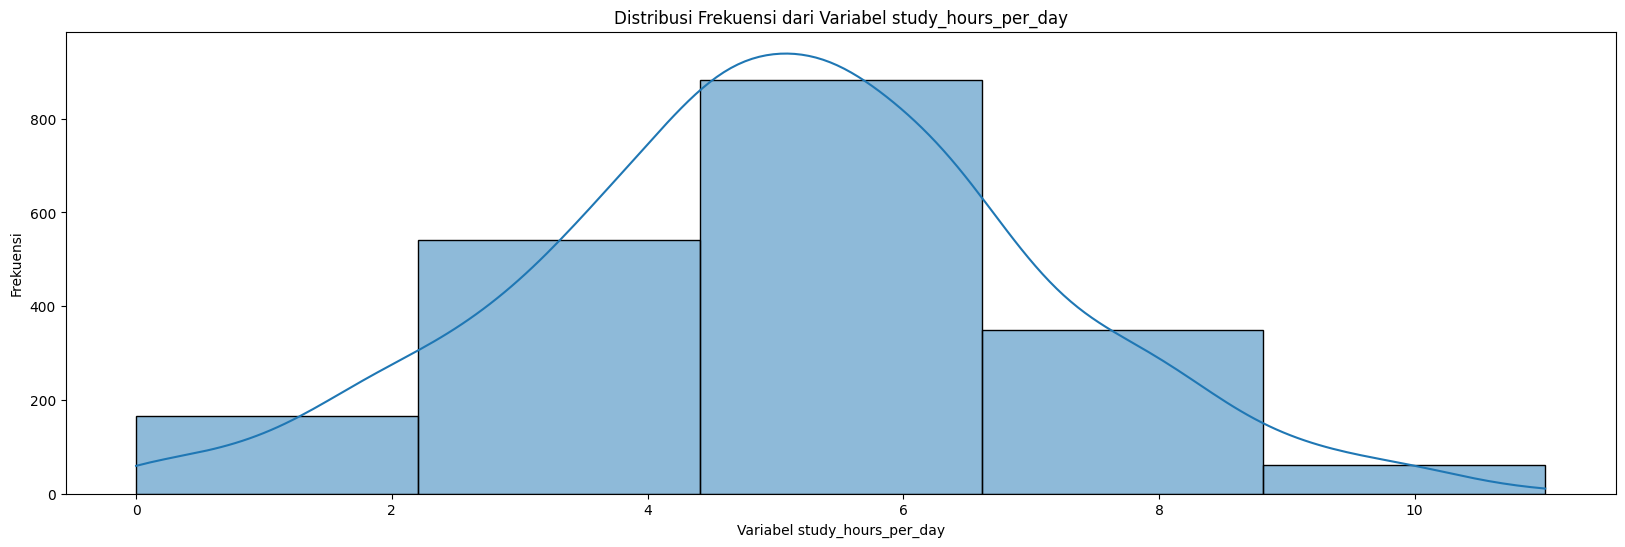

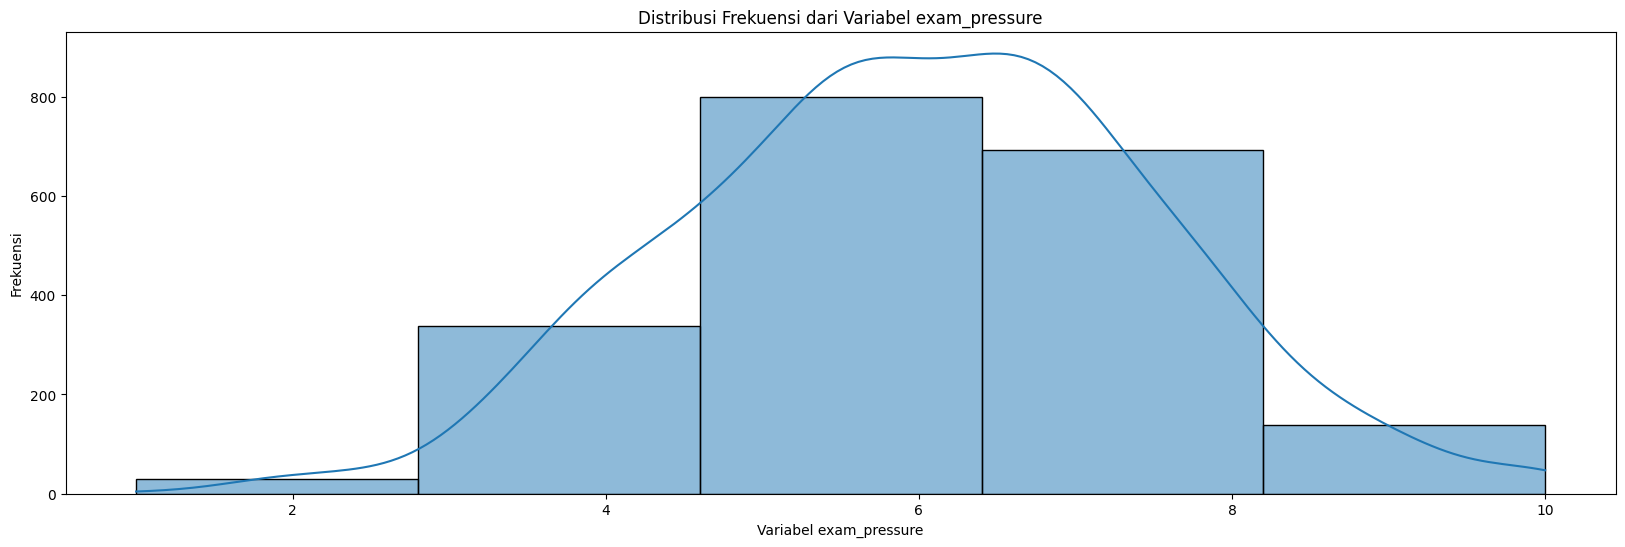

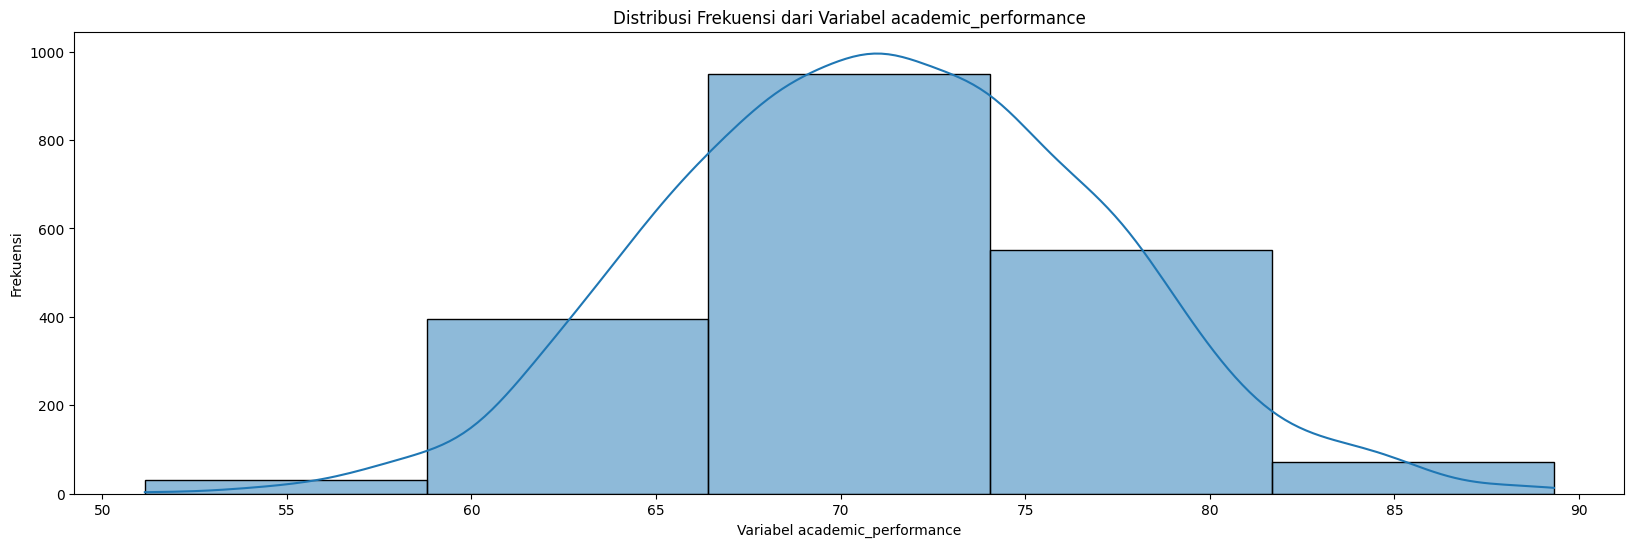

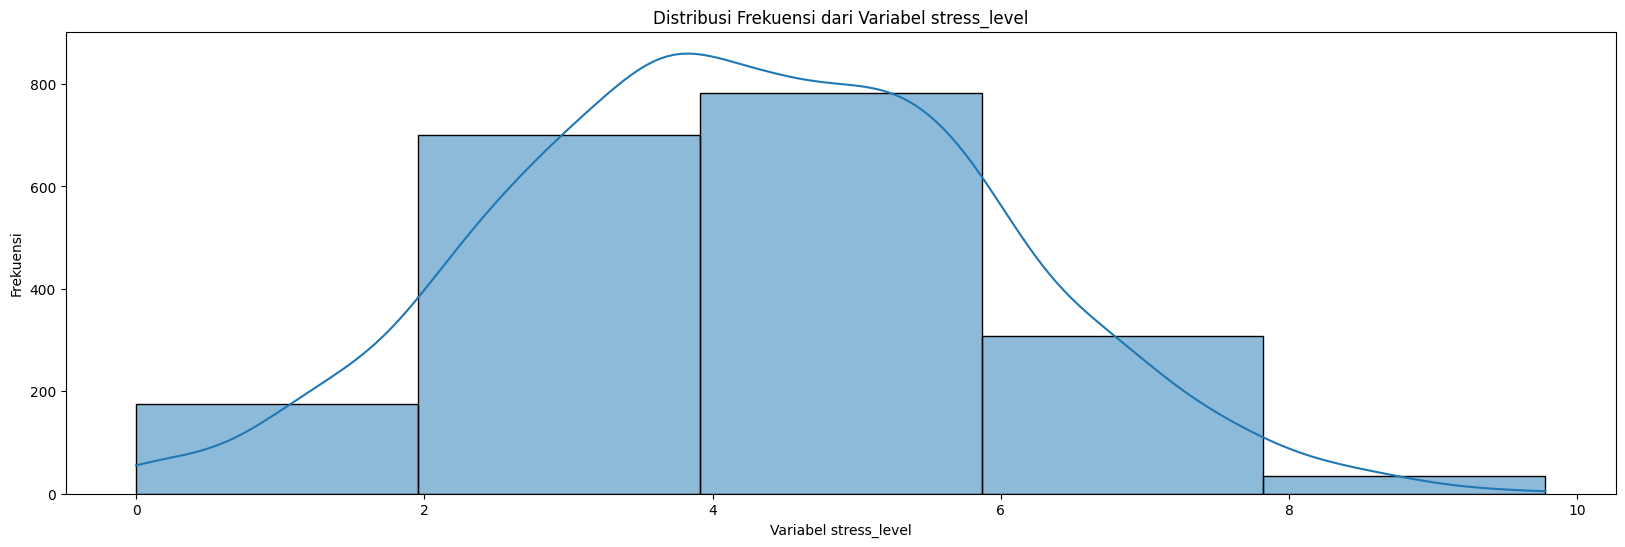

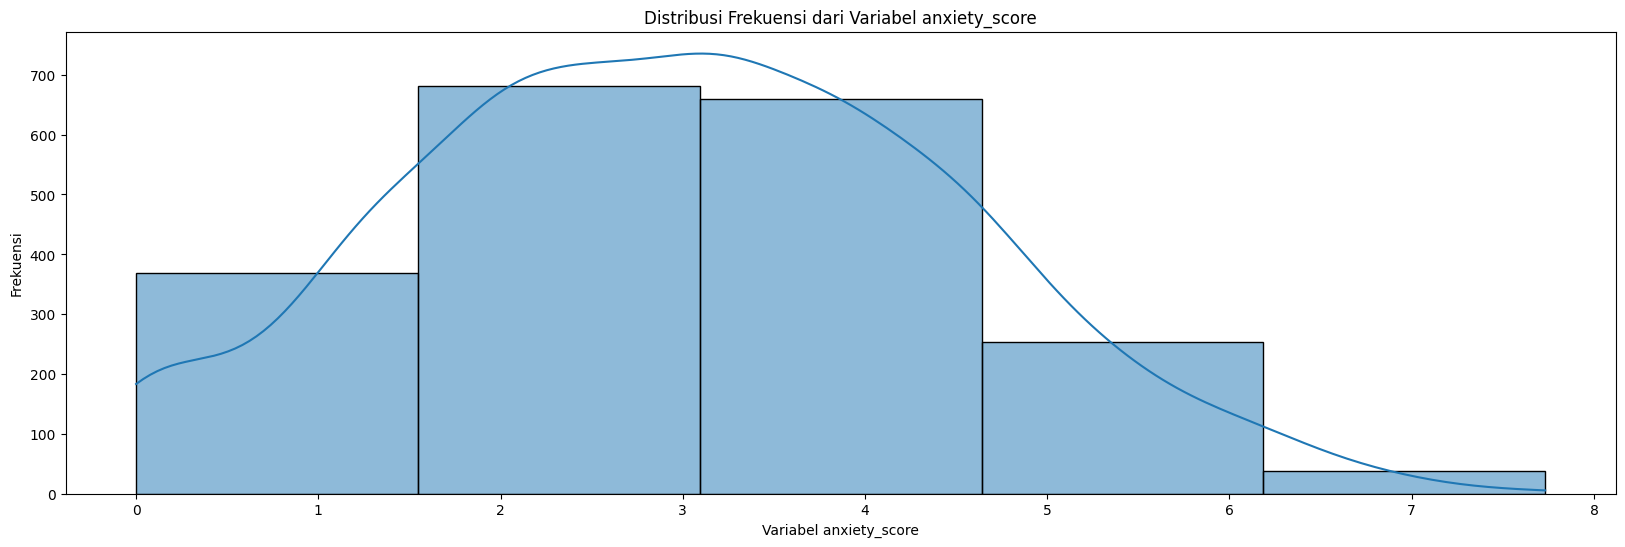

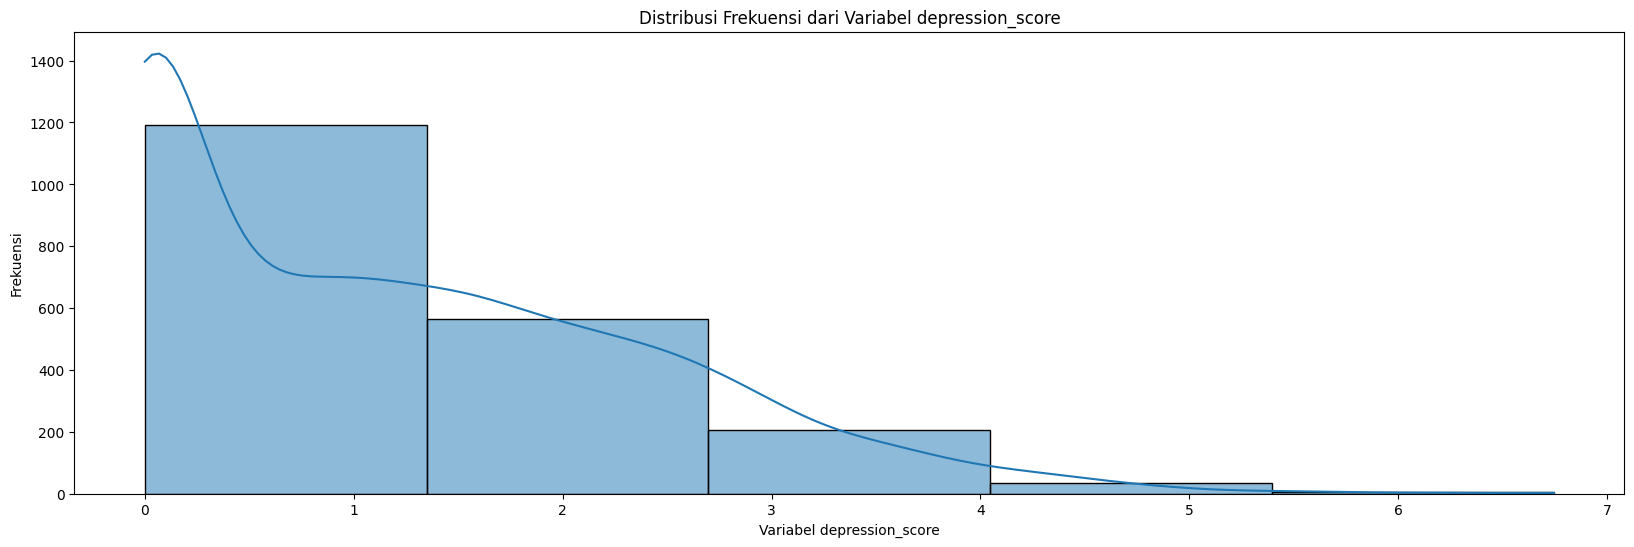

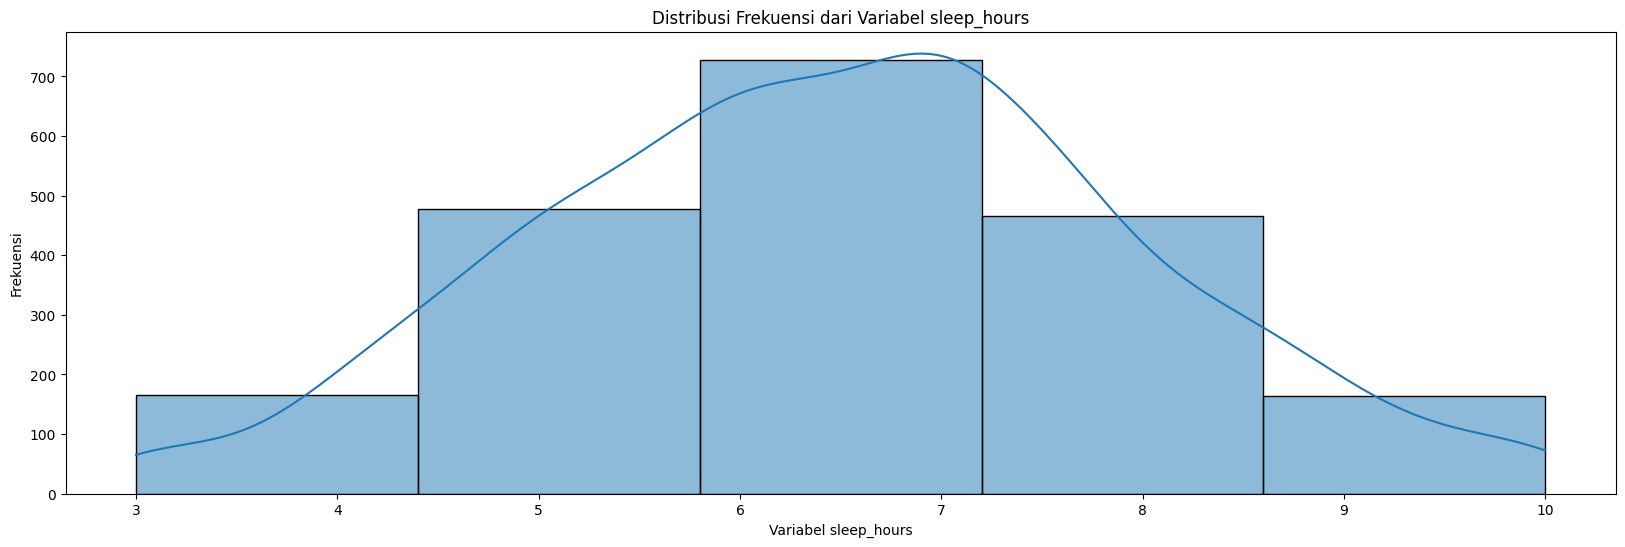

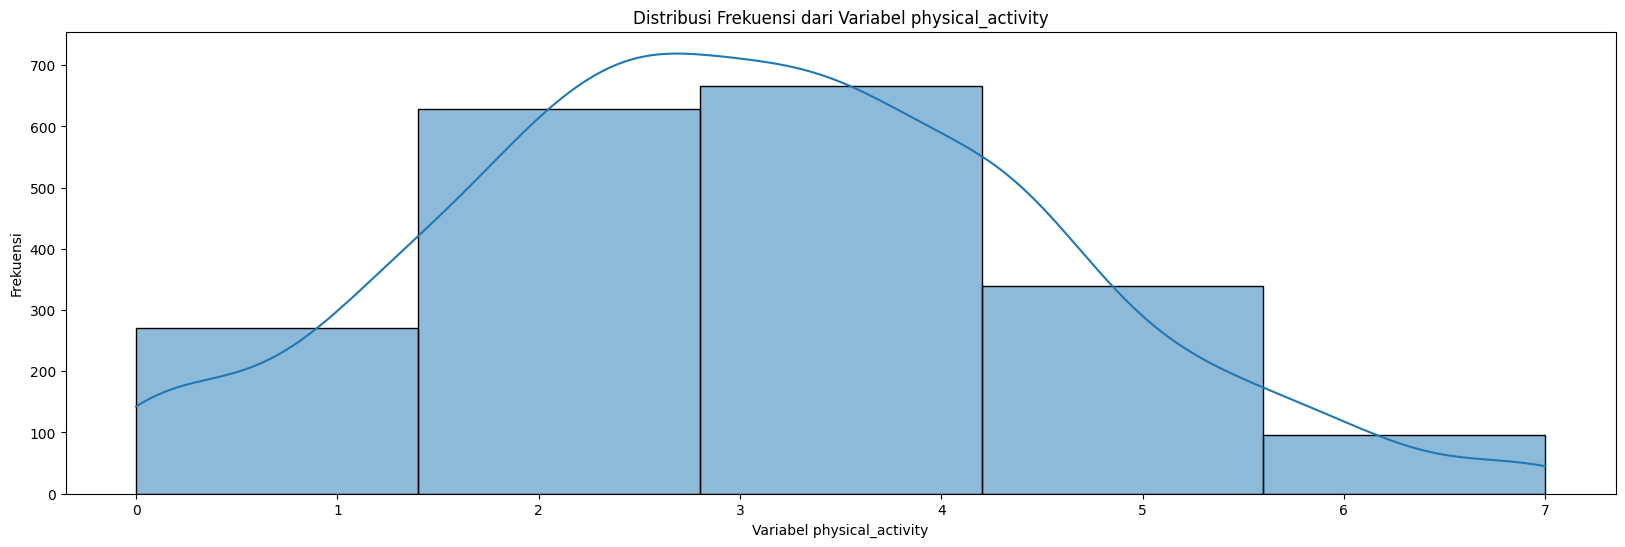

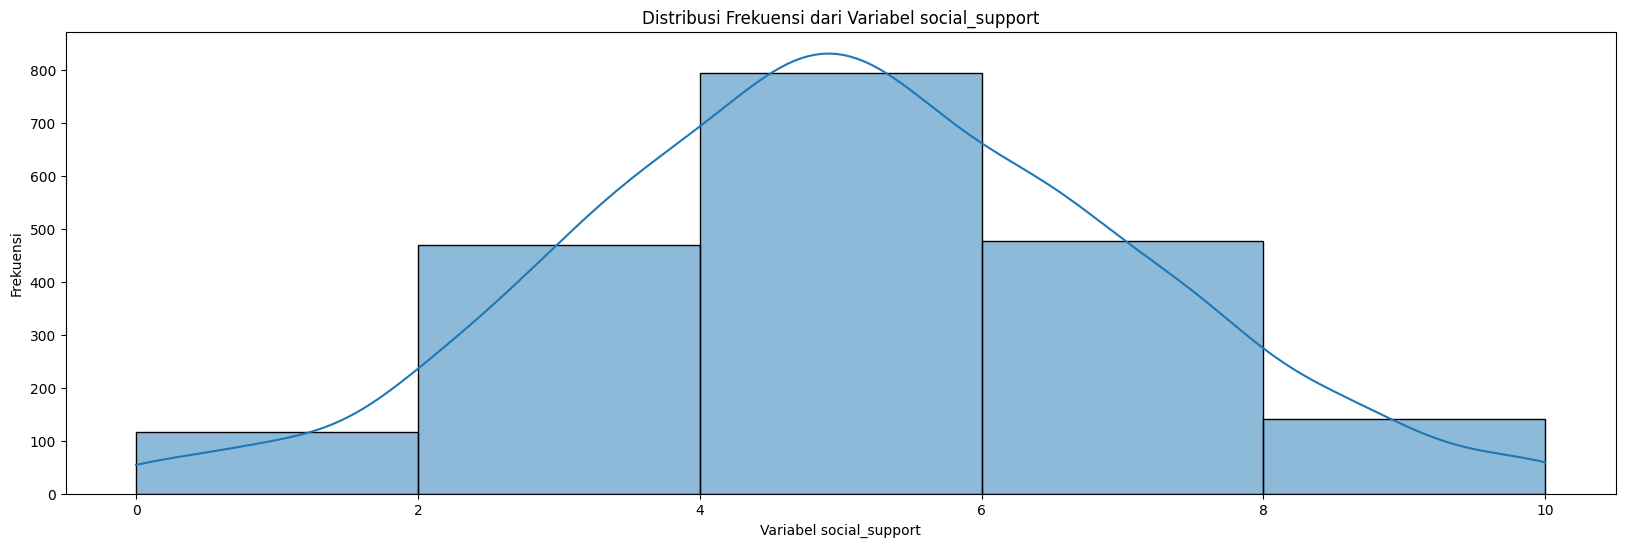

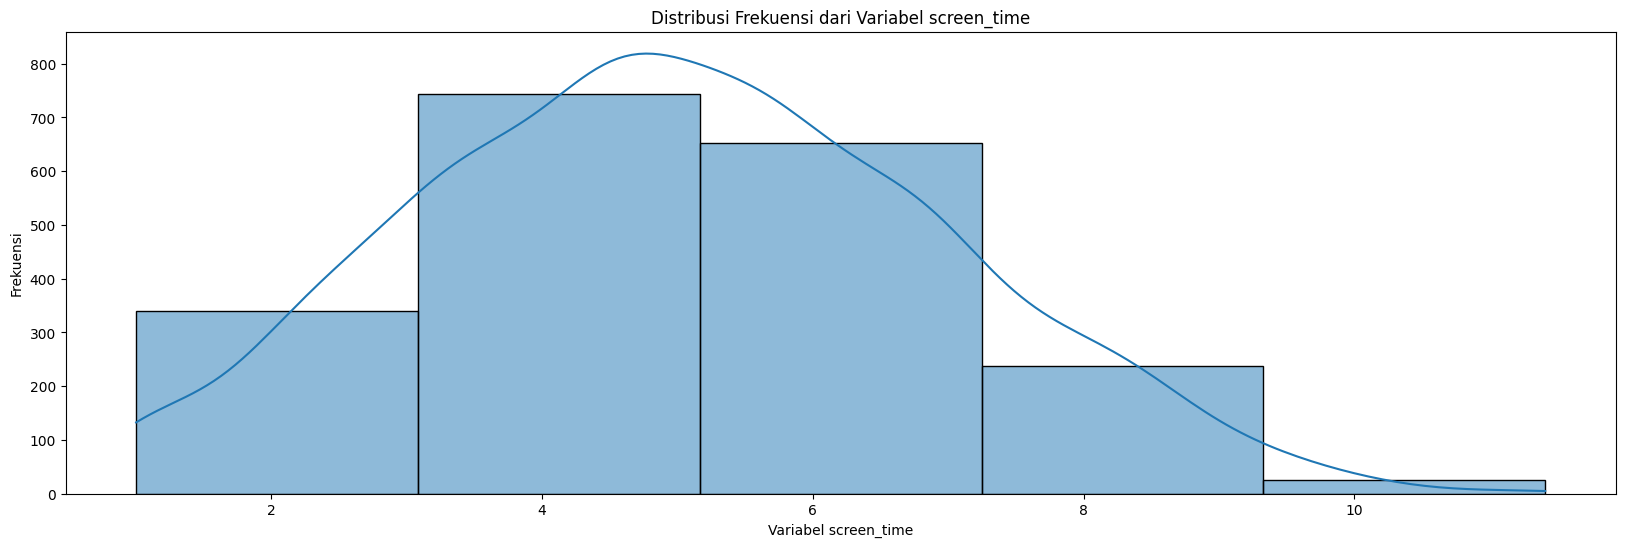

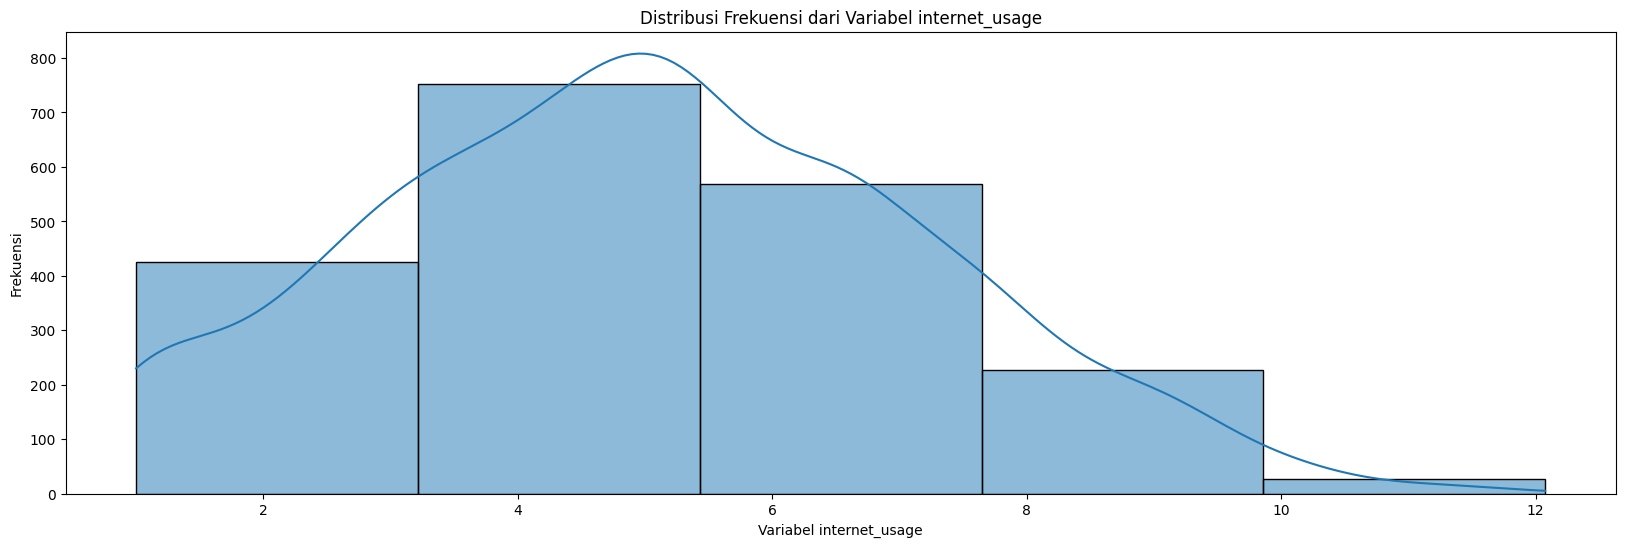

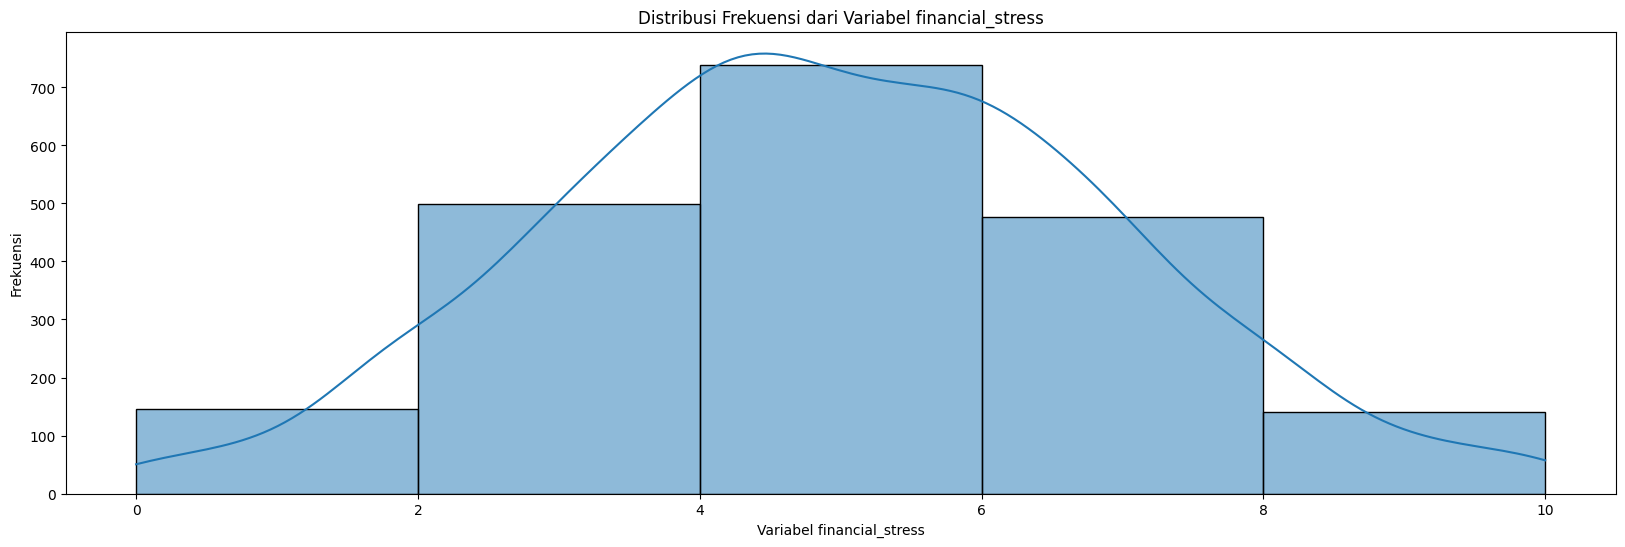

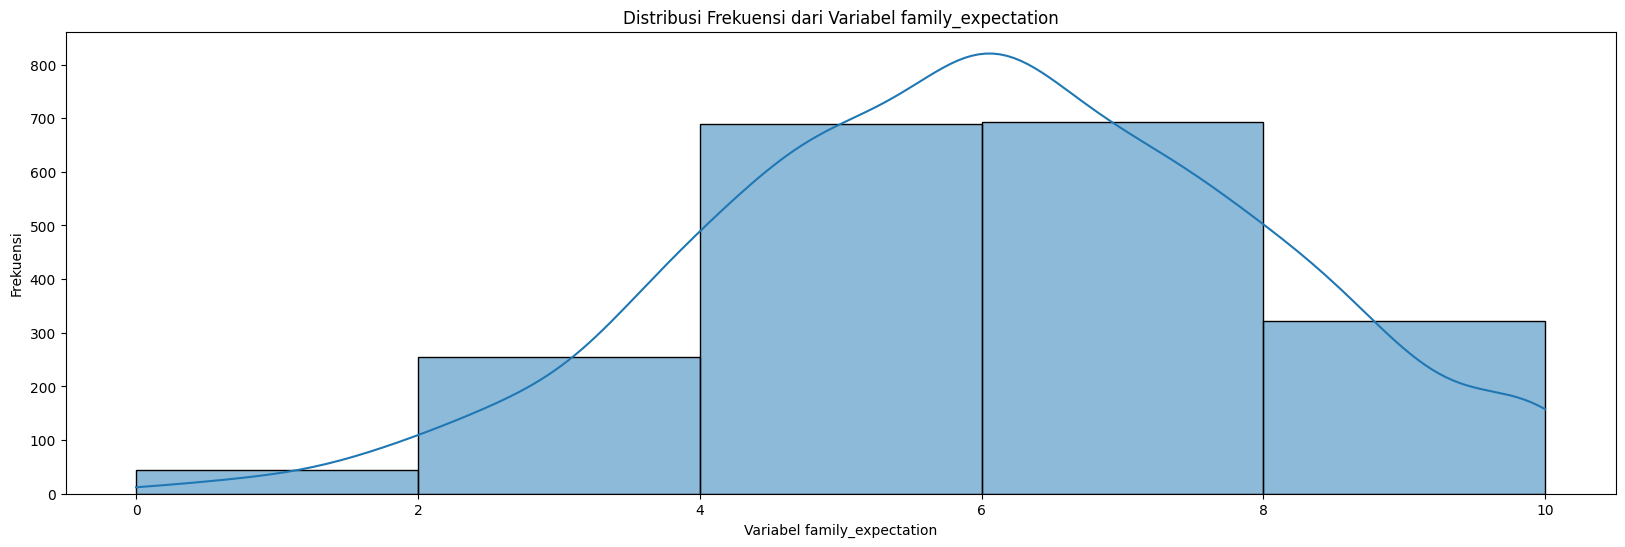

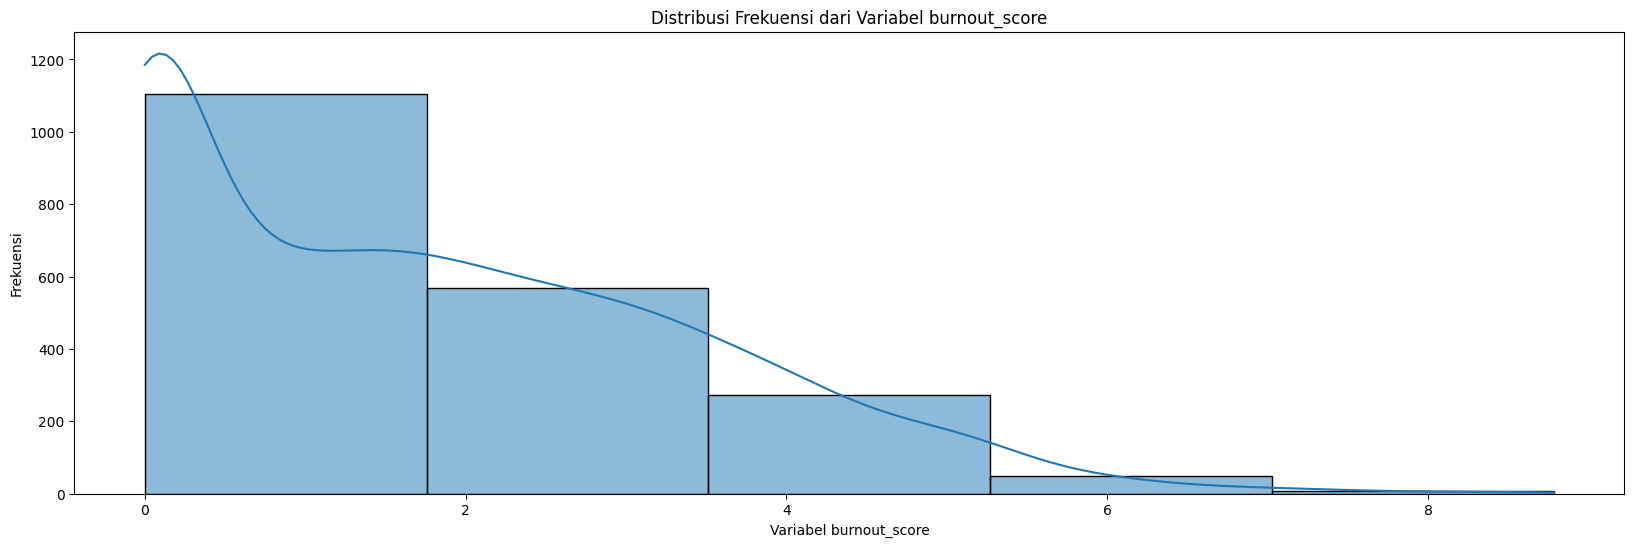

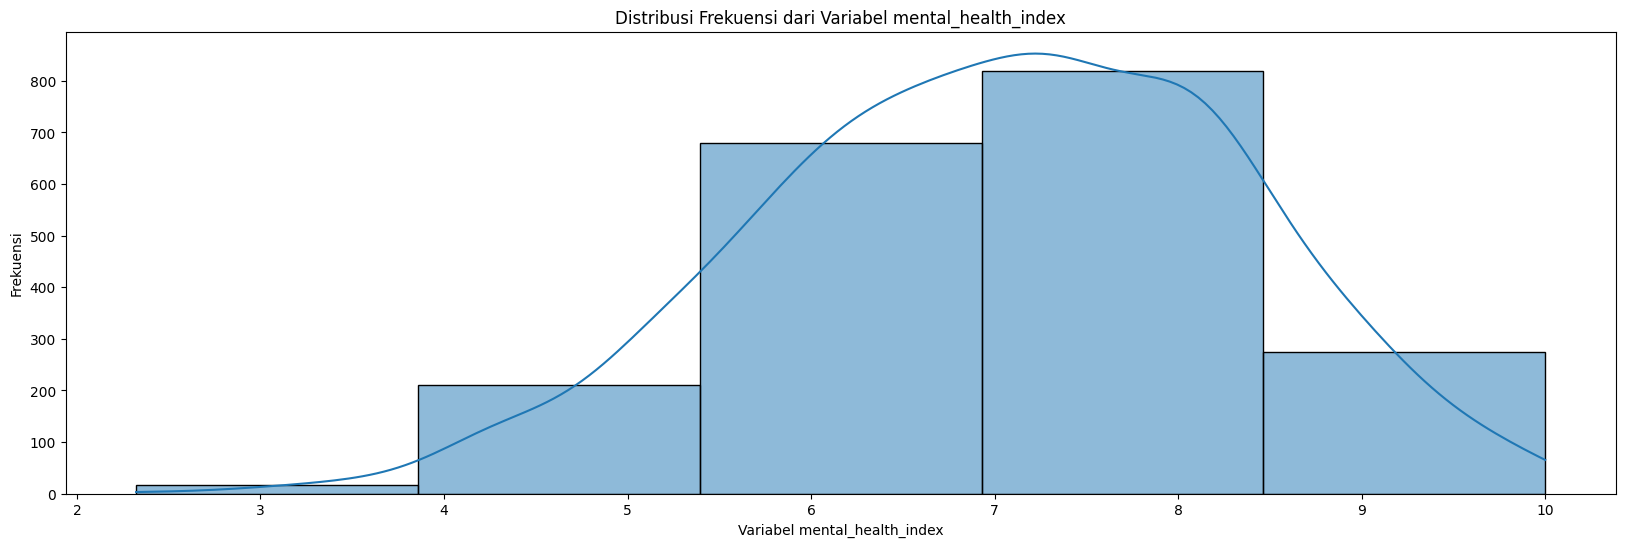

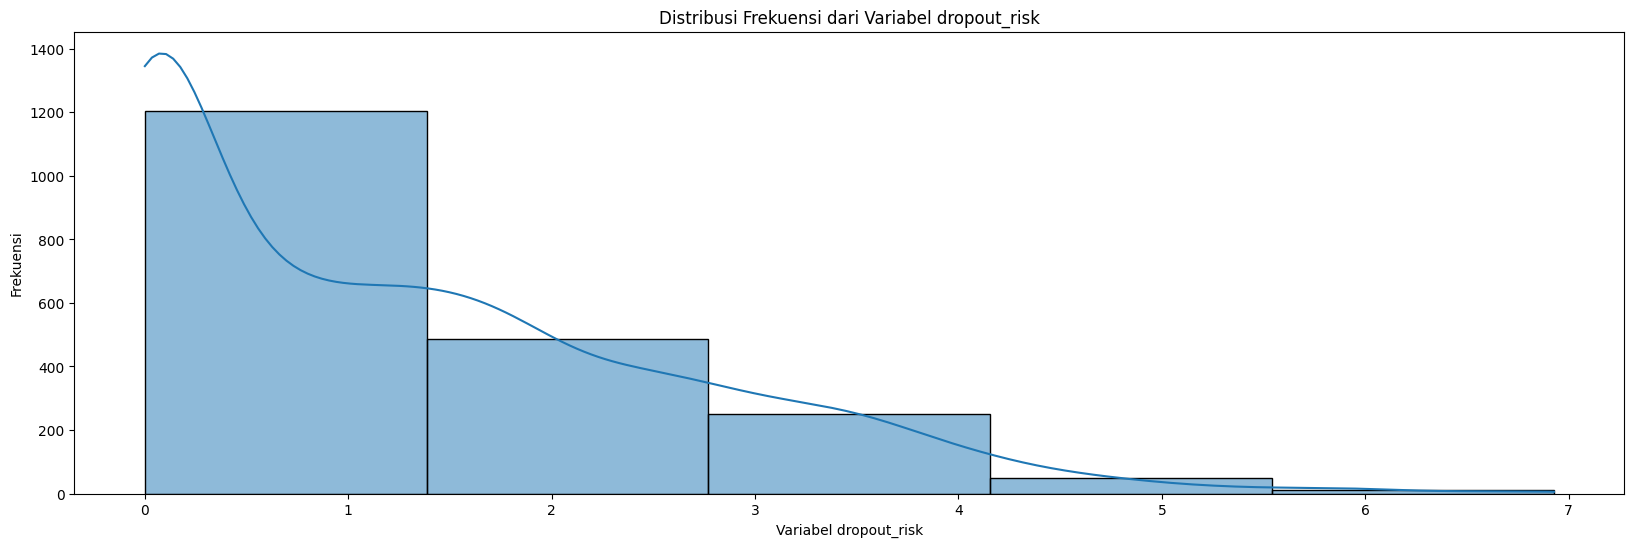

In [148]:
for i in data_kontinu:
    plt.figure(figsize=(20,6))
    plt.title(f'Distribusi Frekuensi dari Variabel {i}')
    sns.histplot(data=data_numerik, x=i, bins=5, kde=True)
    plt.xlabel(f'Variabel {i}')
    plt.ylabel('Frekuensi')
    plt.show() #melihat distribusi frekuensi dari data kontinu kita

In [149]:
for i in data_kontinu:
    print(data_numerik[i].skew()) #melihat statistika dari data kontinu kita

-0.007447197109646631
-0.03971028386470464
0.048224900082669504
0.04104604318859159
0.1219759813991973
0.8623337363532372
0.01971830167199712
0.16153402382915277
0.014256592050493313
0.15703835616614922
0.17968109151883158
0.04776661306889579
-0.12314688107591072
0.7706956719614251
-0.2298908615238027
1.0171820598829011


In [150]:
#ukuran pemusatan data di data ketegorial
for i in data_object.columns:
   print(f'====== ukuran pemusatan data dari vareabel {i} ======')
   print(data_object[i].mode()[0])

====== ukuran pemusatan data dari vareabel gender ======
Male
====== ukuran pemusatan data dari vareabel risk_level ======
Low
====== ukuran pemusatan data dari vareabel stress_group ======
Medium (4-7)
====== ukuran pemusatan data dari vareabel support_group ======
Medium (4-7)
====== ukuran pemusatan data dari vareabel age_group ======
>23


In [151]:
#ukuran pemusatan data di data numerik
for i in data_numerik.columns:
    print(f'====== UKURAN PEMUSATAN DATA DARI VARIABEL {i} ======')
    print(f'====== mean ========')
    print(data_numerik[i].mean())
    print(f'====== median ========')
    print(data_numerik[i].median()) 
    print(f'====== modus ========')
    print(data_numerik[i].mode()[0])

====== UKURAN PEMUSATAN DATA DARI VARIABEL age ======
====== mean ========
23.1235
====== median ========
23.0
====== modus ========
27
====== UKURAN PEMUSATAN DATA DARI VARIABEL academic_year ======
====== mean ========
2.4965
====== median ========
2.0
====== modus ========
4
====== UKURAN PEMUSATAN DATA DARI VARIABEL study_hours_per_day ======
====== mean ========
5.053695802403563
====== median ========
5.0580534056280175
====== modus ========
0.0
====== UKURAN PEMUSATAN DATA DARI VARIABEL exam_pressure ======
====== mean ========
6.013847842932027
====== median ========
6.035415719679921
====== modus ========
10.0
====== UKURAN PEMUSATAN DATA DARI VARIABEL academic_performance ======
====== mean ========
71.18862720195504
====== median ========
71.1469918829988
====== modus ========
51.15284149419776
====== UKURAN PEMUSATAN DATA DARI VARIABEL stress_level ======
====== mean ========
4.24969335568385
====== median ========
4.239276082903238
====== modus ========
0.0
====== UKURAN P

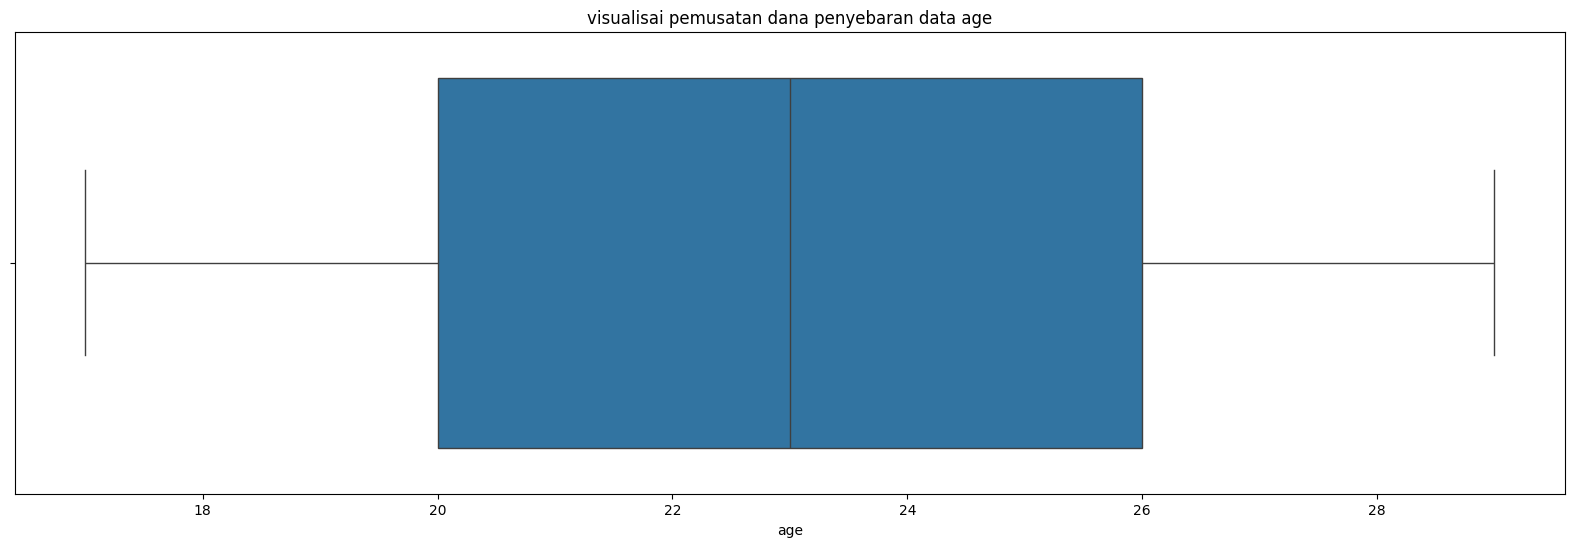

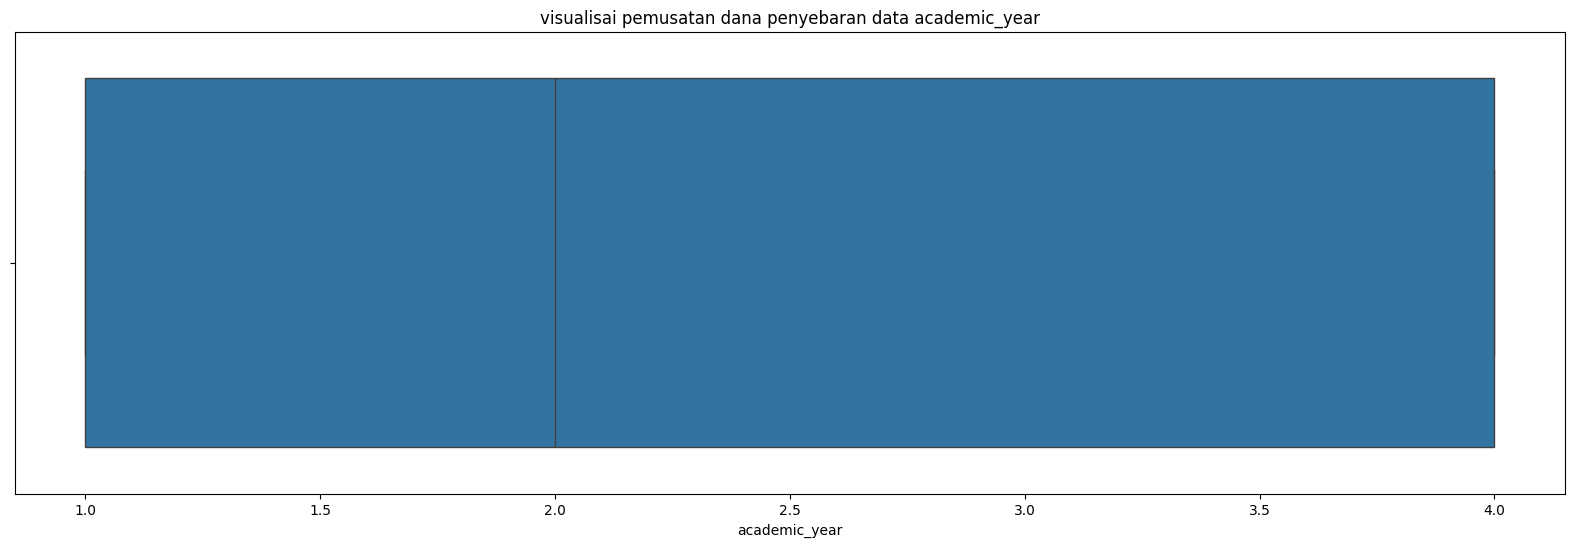

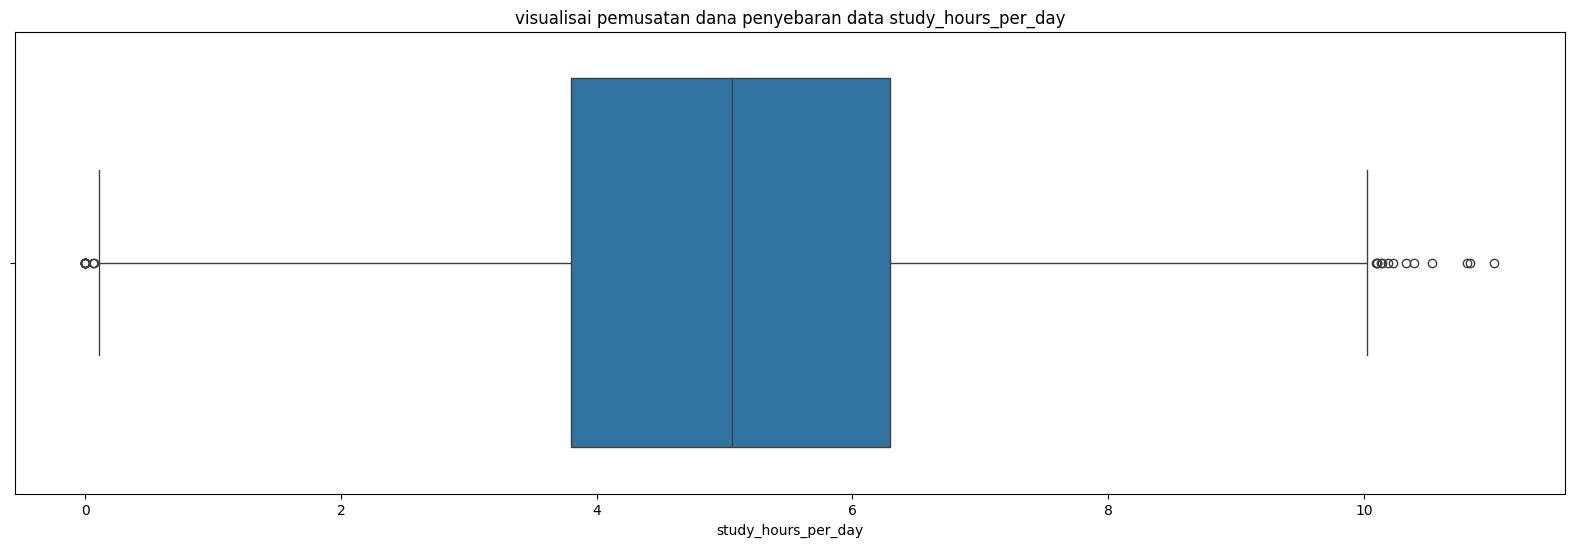

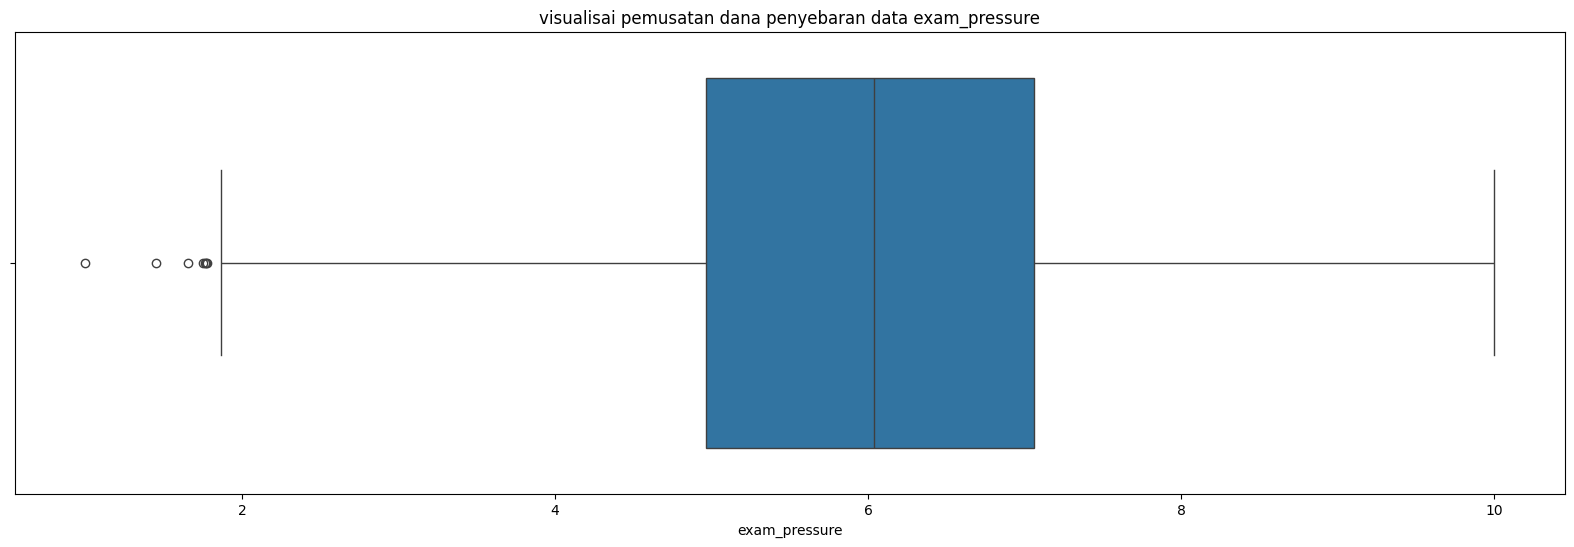

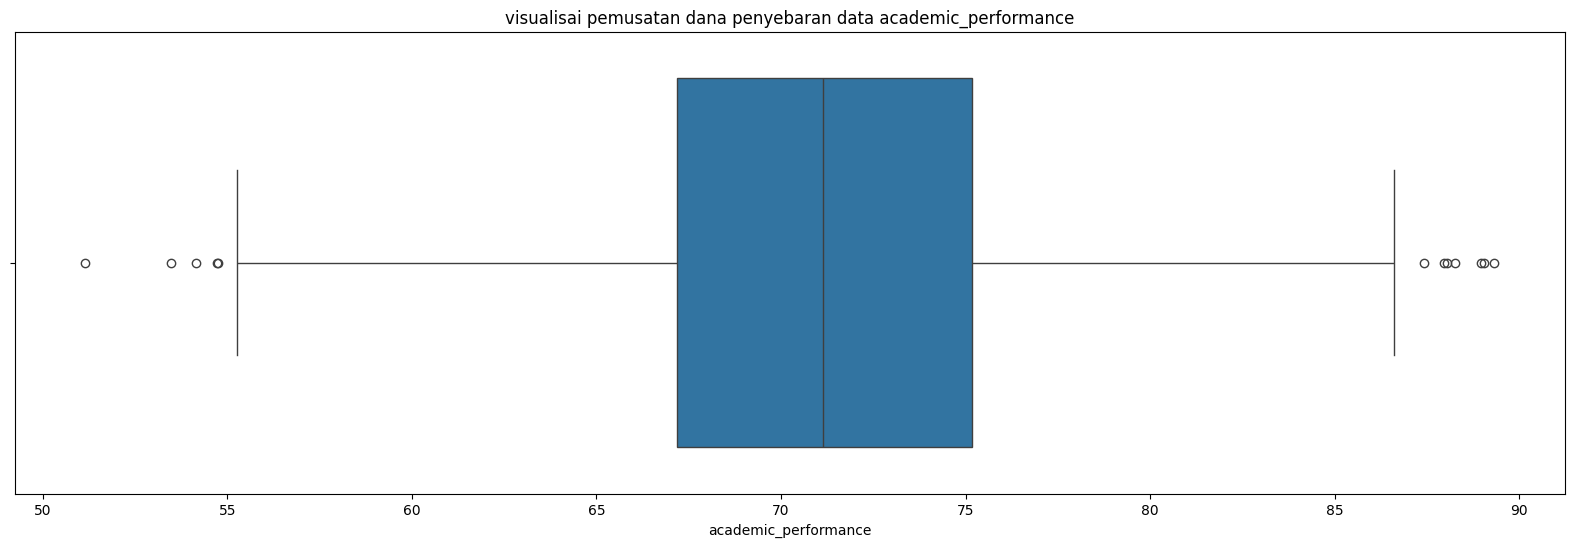

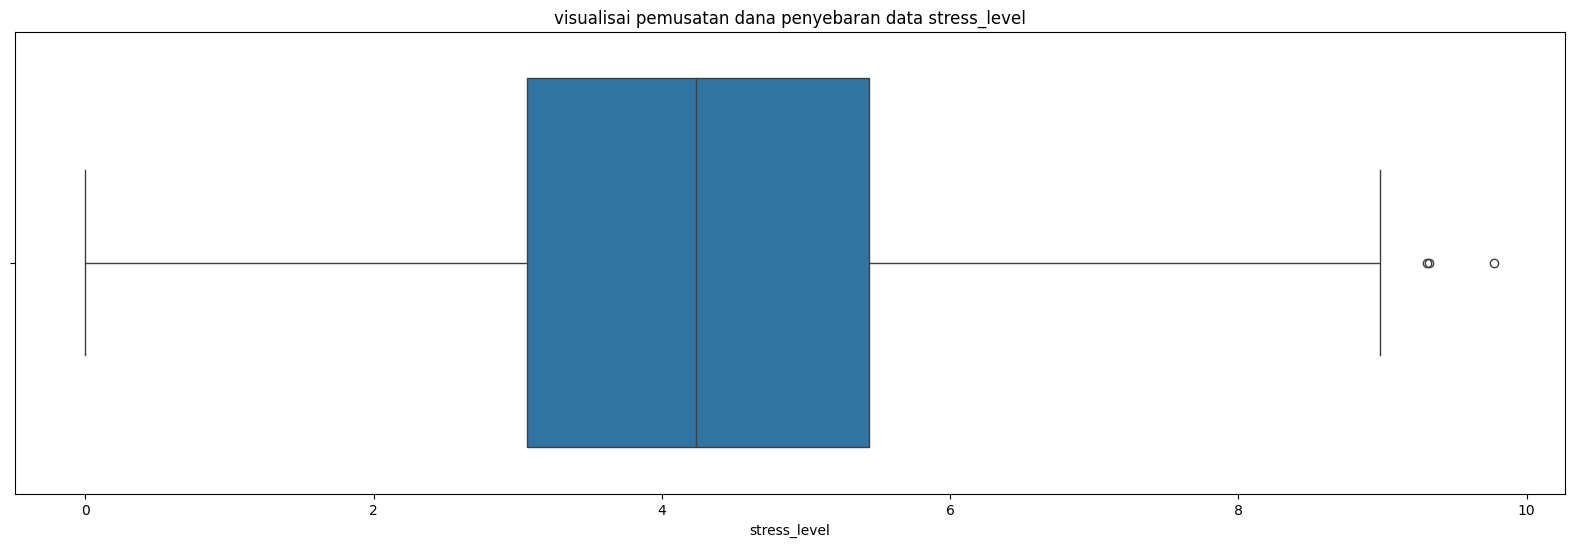

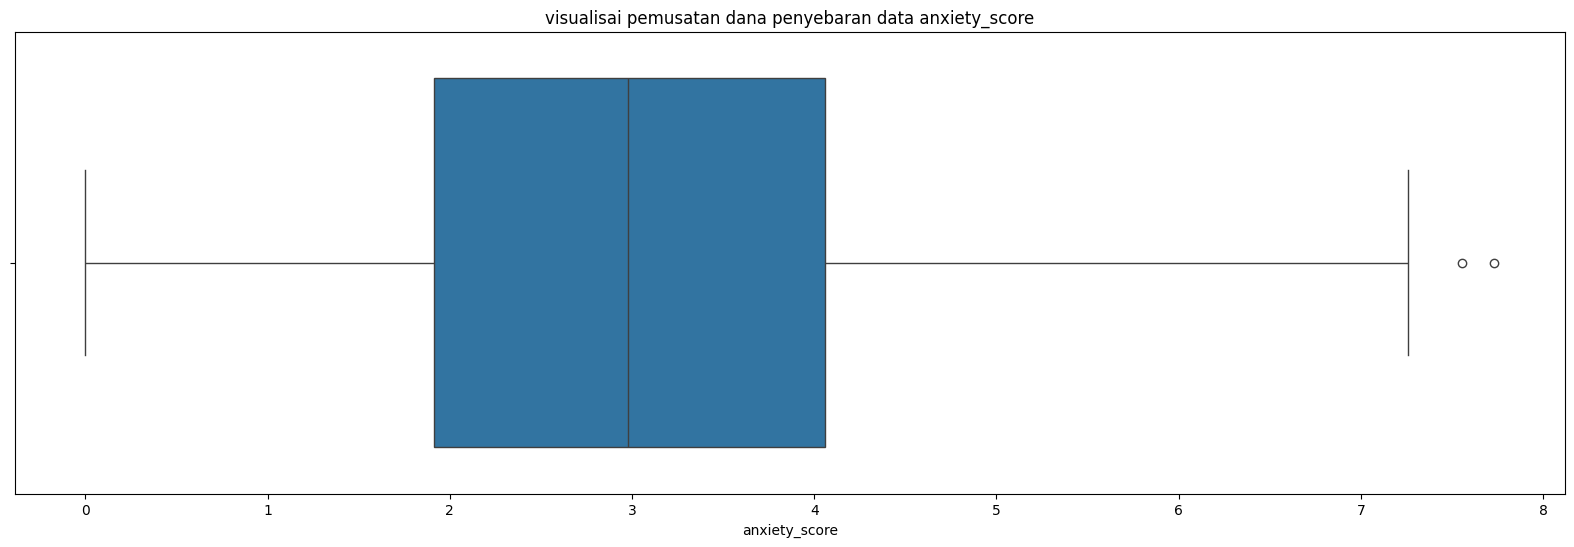

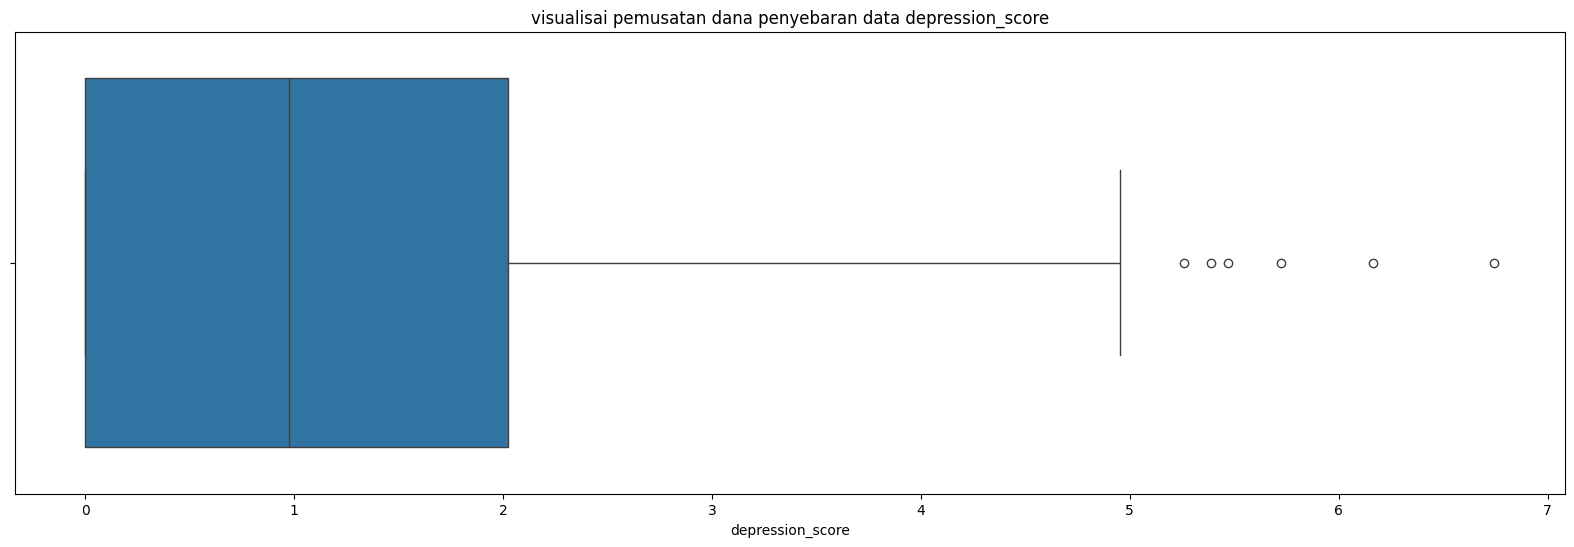

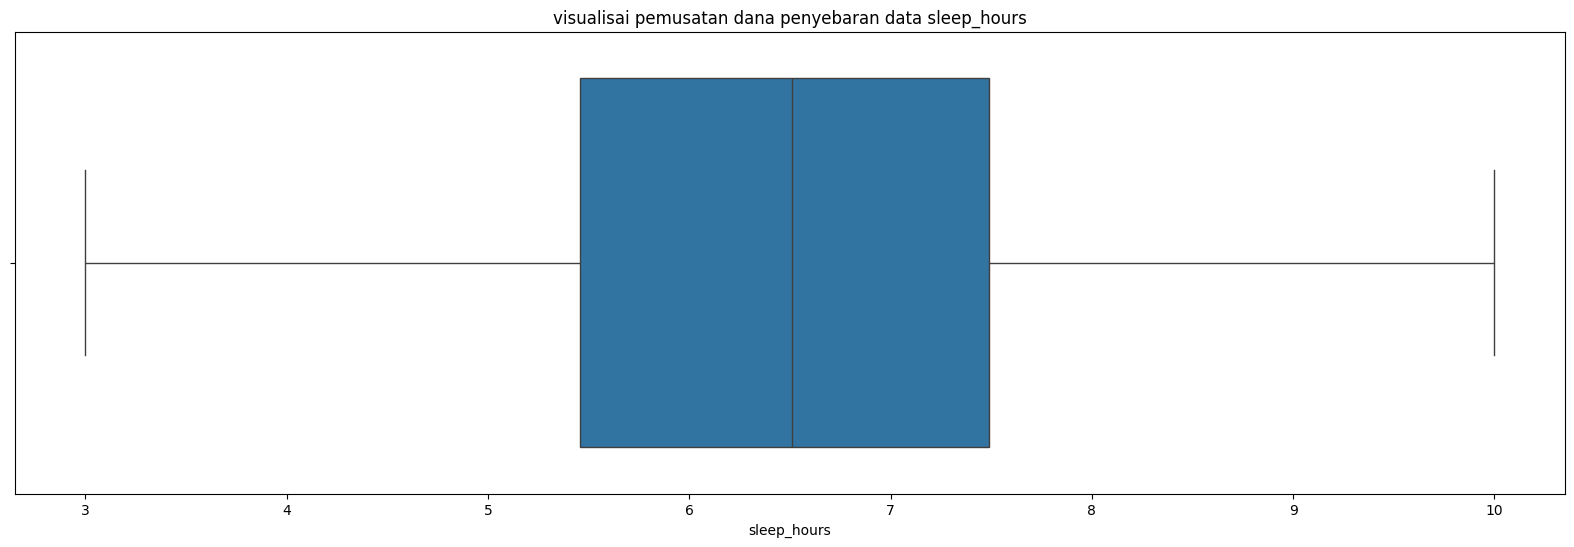

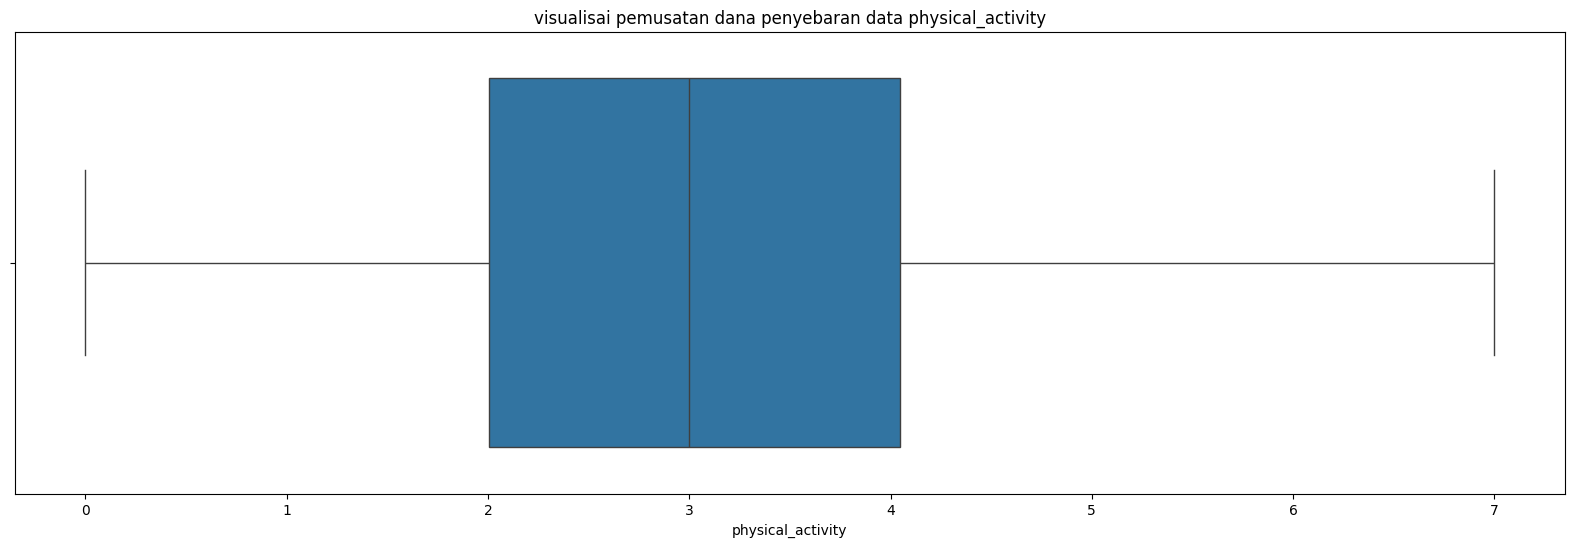

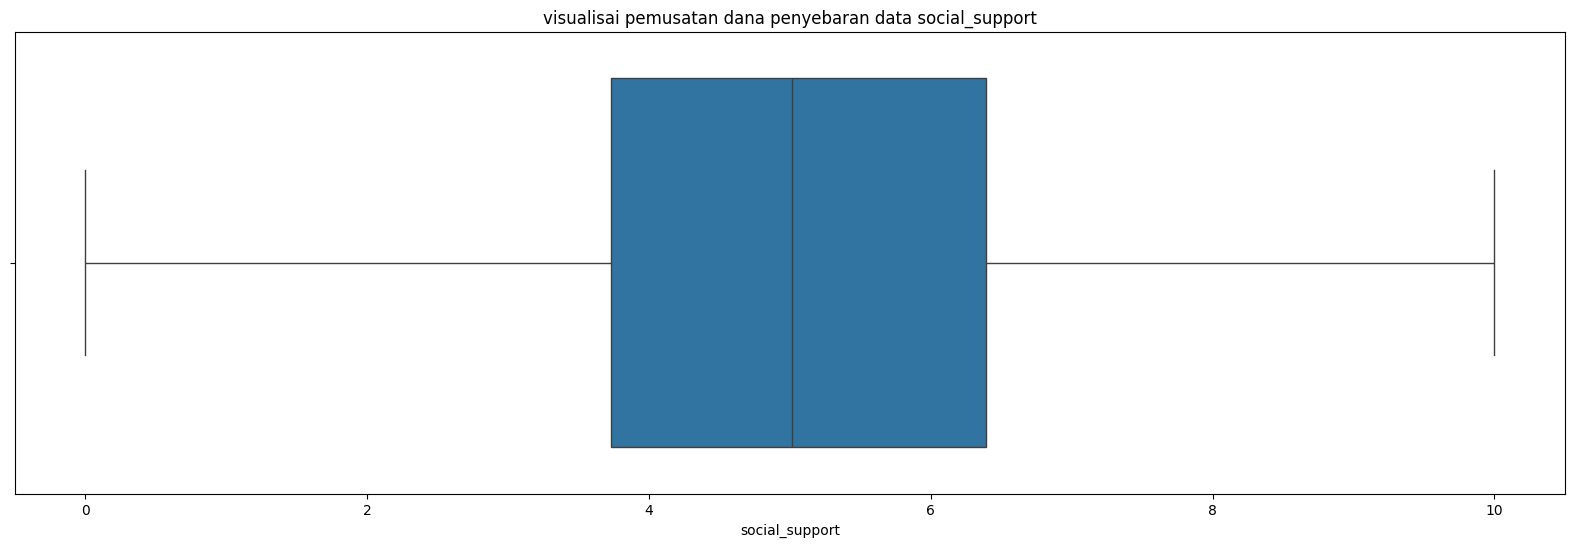

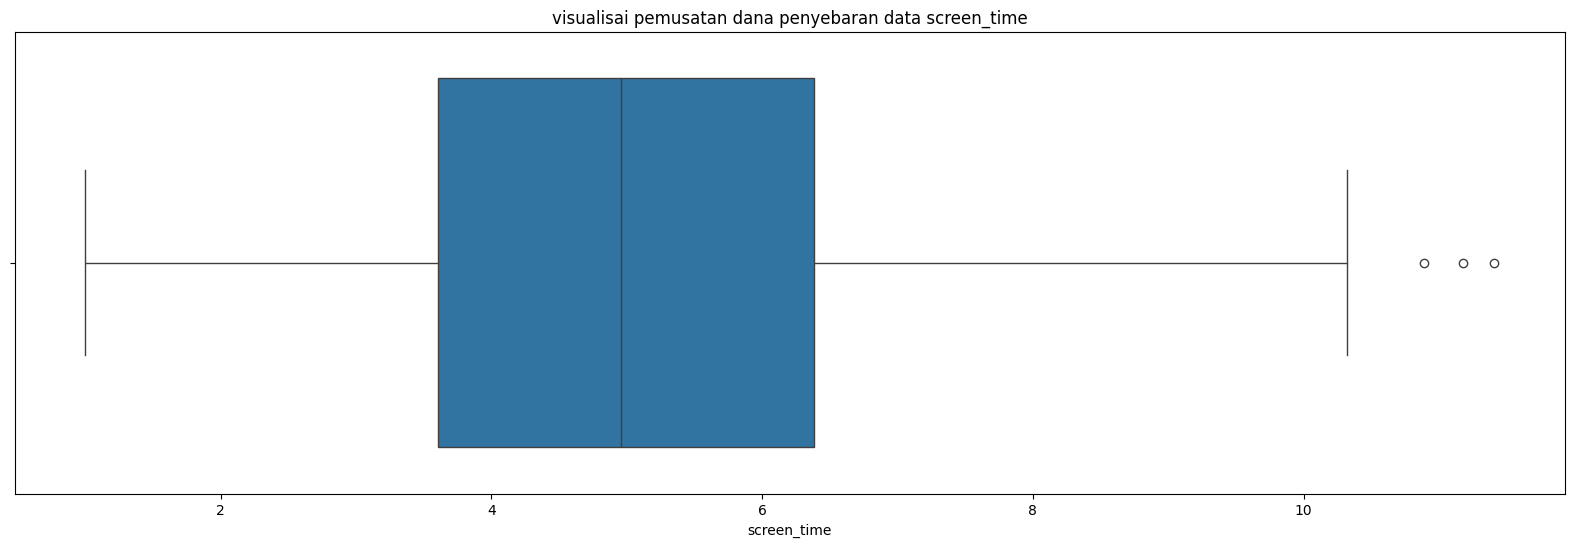

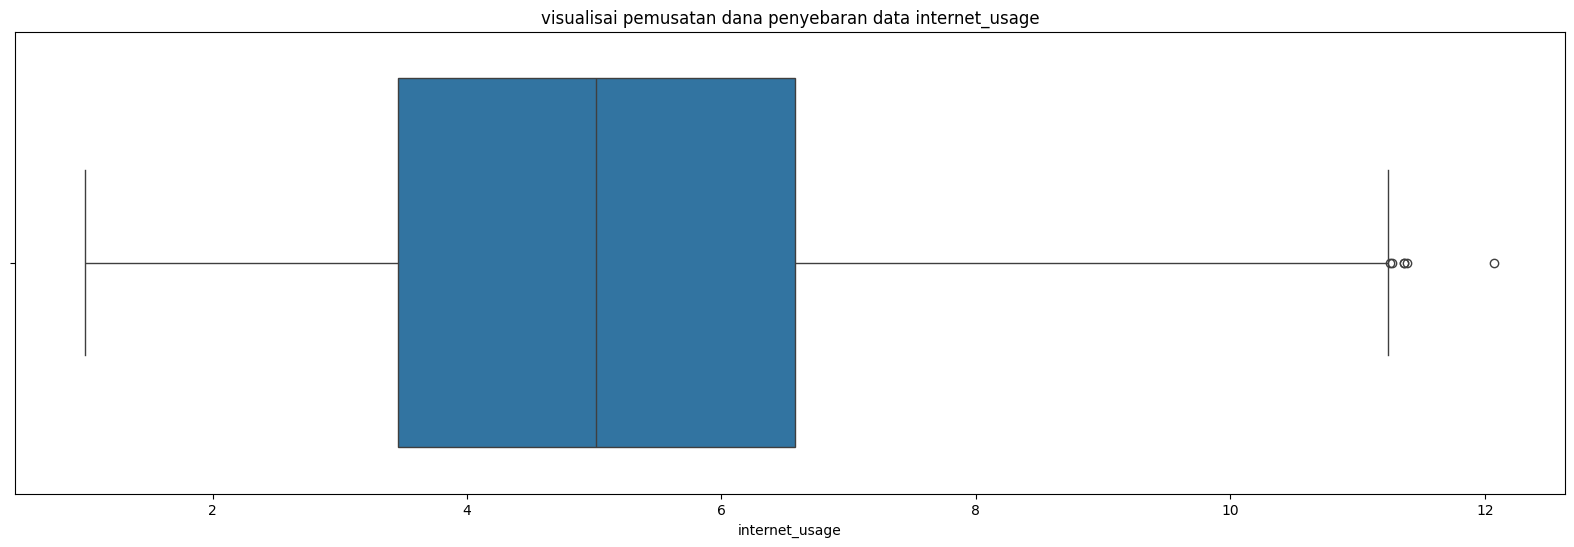

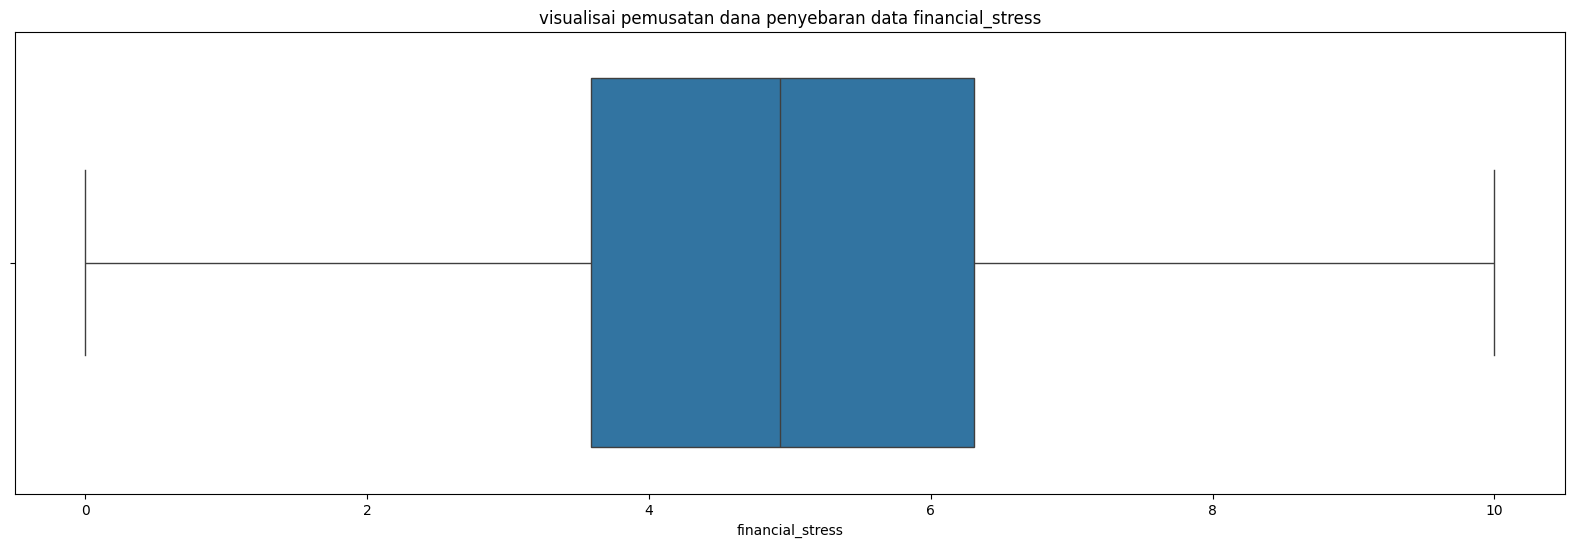

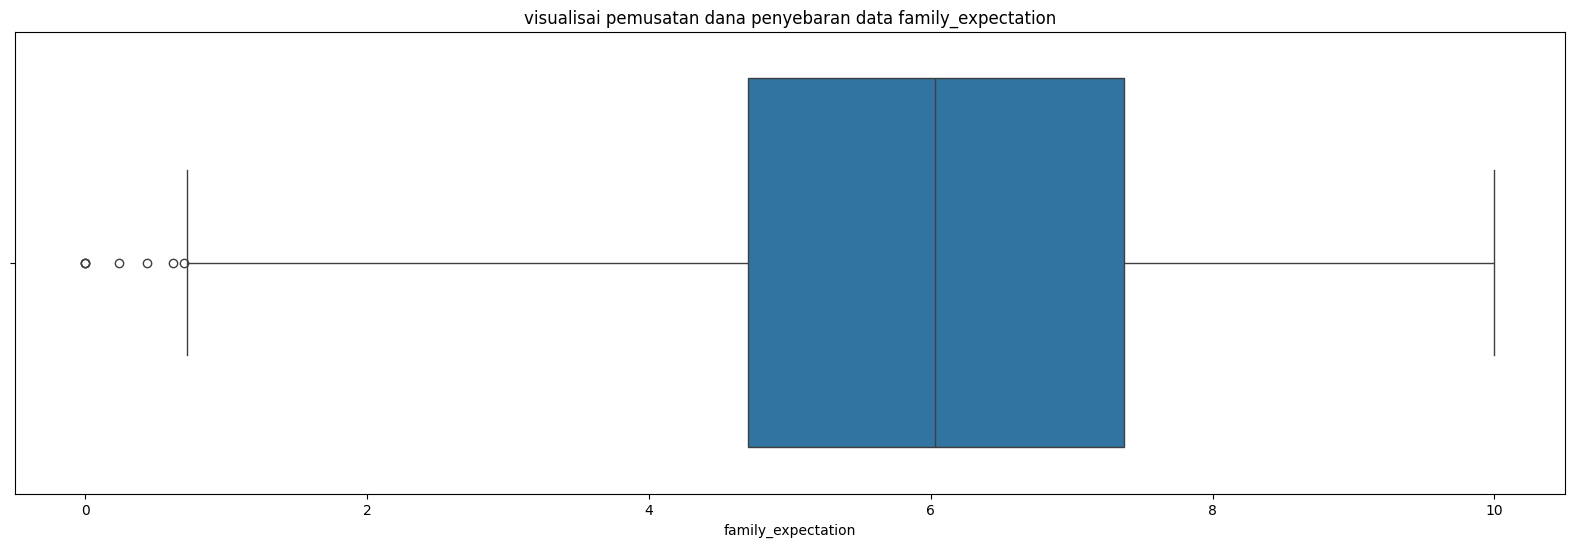

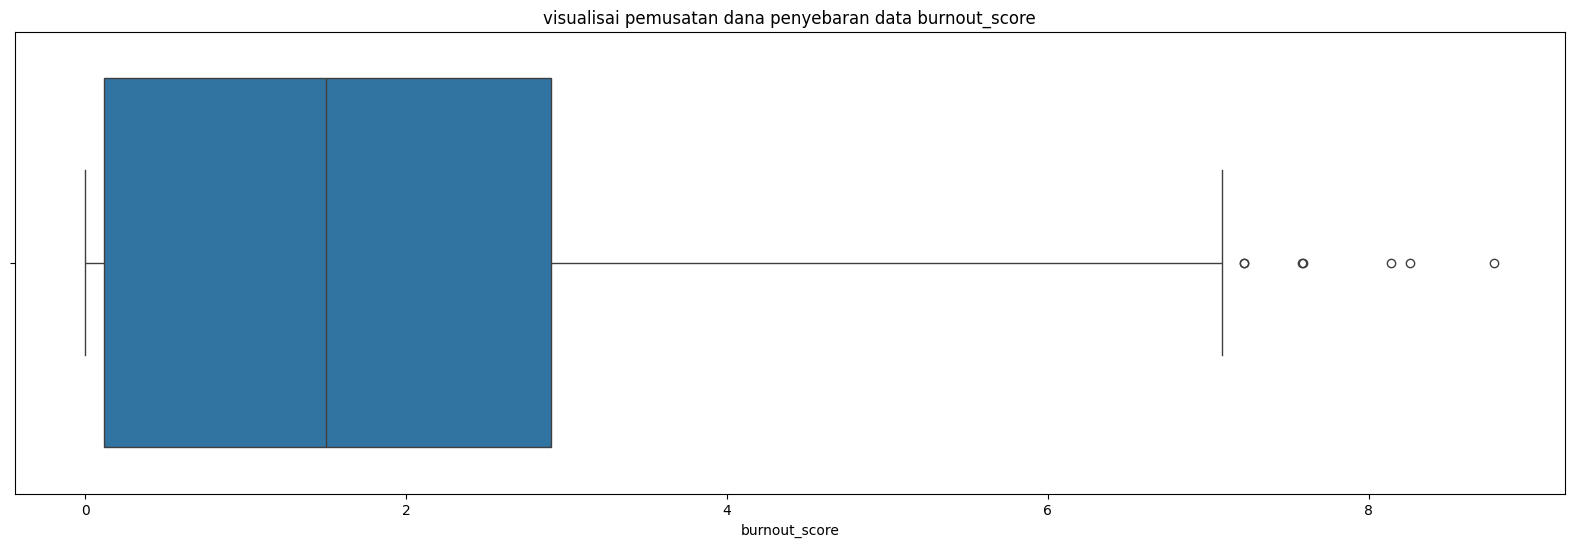

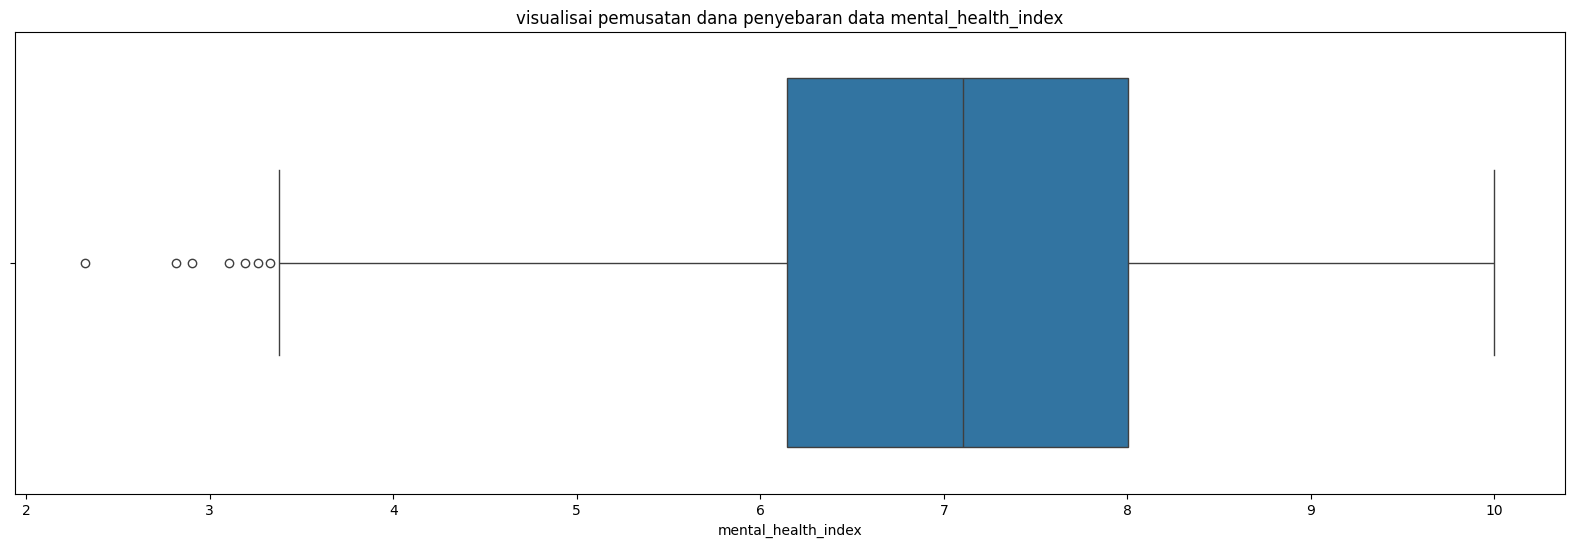

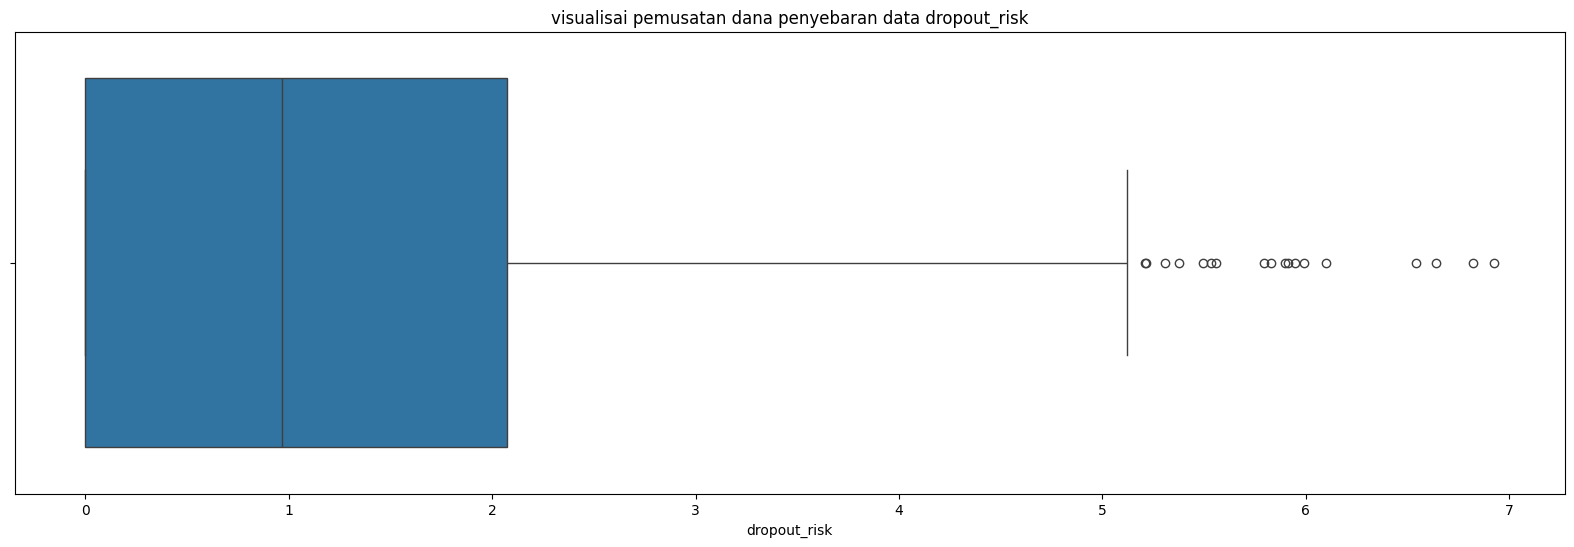

In [152]:
for i in data_numerik.columns:
    plt.figure(figsize=(20,6))
    plt.title(f'visualisai pemusatan dana penyebaran data {i}')
    sns.boxplot(data=data_numerik, x=i)
    plt.show()

In [153]:
#aspliting data set

x = data_model.drop(columns=['risk_level']) #memisahkan data fitur dengan data target
y = data_model['risk_level']

x_latih, x_uji, y_latih, y_uji = train_test_split(x, y, test_size= 0.3, random_state=42) #memisahkan data latih dan data uji dengan rasio 70:30

print(x.shape) #melihat jumlah data fitur
print(y.shape) #melihat jumlah data target

(2000, 22)
(2000,)


In [154]:
#melihat isi di dalam x_latih 

print(y_latih.name)

print(y_latih.head())

risk_level
836     Medium
575     Medium
557        Low
1235       Low
1360       Low
Name: risk_level, dtype: object


In [155]:
y_latih.value_counts(normalize=True) * 100

risk_level
Low       76.357143
Medium    22.500000
High       1.142857
Name: proportion, dtype: float64

In [156]:
y_latih = pd.DataFrame(y_latih)

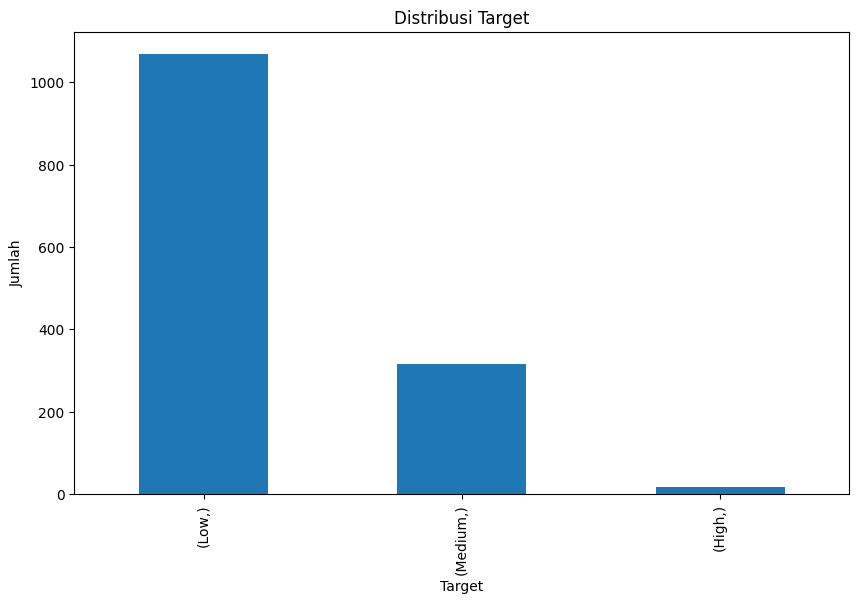

In [157]:
#ditiribusi targer 
plt.figure(figsize=(10,6))
y_latih.value_counts().plot(kind='bar')
plt.title('Distribusi Target')
plt.xlabel('Target')
plt.ylabel('Jumlah')
plt.show()


In [158]:
data_object.describe()

,gender,risk_level,stress_group,support_group,age_group
count,2000,2000,2000,2000,2000
unique,3,3,3,3,3
top,Male,Low,Medium (4-7),Medium (4-7),>23
freq,968,1529,1356,1369,959


In [159]:
#melihat data IR ( imabalence rasio) mengunakn if statement


for i in x_latih.columns:
    
    jumlan = x_latih[i].value_counts() #bagian ini untuk menghitung dsitribusi data disetiap class

    
    max_value = jumlan.max()
    min_value = jumlan.min()
    
    rasio = max_value / min_value
    
    if rasio < 1.5:
        print(f"data tidak imbalence pada kolom {i} dengan rasio{rasio:.2f}")
    elif rasio > 1.5 and rasio <= 3:
        print(f"data sedikit imbalence pada kolom {i} dengan rasio{rasio:.2f}")
    else:
        print(f"data imbalence pada kolom {i} dengan rasio{rasio:.2f}")

data tidak imbalence pada kolom age dengan rasio1.30
data imbalence pada kolom gender dengan rasio13.80
data tidak imbalence pada kolom academic_year dengan rasio1.07
data imbalence pada kolom study_hours_per_day dengan rasio12.00
data imbalence pada kolom exam_pressure dengan rasio10.00
data tidak imbalence pada kolom academic_performance dengan rasio1.00
data imbalence pada kolom stress_level dengan rasio7.00
data imbalence pada kolom anxiety_score dengan rasio43.00
data imbalence pada kolom depression_score dengan rasio376.00
data imbalence pada kolom sleep_hours dengan rasio20.00
data imbalence pada kolom physical_activity dengan rasio36.00
data imbalence pada kolom social_support dengan rasio11.00
data imbalence pada kolom screen_time dengan rasio24.00
data imbalence pada kolom internet_usage dengan rasio47.00
data imbalence pada kolom financial_stress dengan rasio10.00
data imbalence pada kolom family_expectation dengan rasio35.00
data imbalence pada kolom burnout_score dengan ra

In [160]:

imbalance_rasio = y_latih.value_counts()
rasio = imbalance_rasio.max() / imbalance_rasio.min()

if rasio < 1.5:
    print(f'data aman tidak imbalence {rasio}')
elif rasio > 1.5 and rasio <= 3:
    print(f"sedikit imbalence {rasio}")
else:
    print(f"data imbalence {rasio}")


data imbalence 66.8125


In [161]:
x_latih_numeik = x_latih.select_dtypes(include=['float64', 'int64'])
print(x_latih_numeik)

      age  academic_year  study_hours_per_day  exam_pressure  \
836    18              1             5.413068       5.994534   
575    27              1             5.565487       6.731264   
557    19              1             8.030170       8.544266   
1235   29              2             7.952031       7.749328   
1360   19              1             5.162216       6.973838   
...   ...            ...                  ...            ...   
1130   28              1             7.904527       8.065165   
1294   19              4             6.286462       7.823477   
860    21              2             4.399679       7.893692   
1459   29              4             3.689182       5.838742   
1126   19              2             6.593217       7.113224   

      academic_performance  stress_level  anxiety_score  depression_score  \
836              70.204900      5.367322       2.818262          2.524558   
575              72.052354      3.875417       4.097471          2.370141   


In [162]:
#misahkan data disrtik dan data kontinu

nilai_uniq = 15
kontinu = []
distrik = [] 

for i in x_latih_numeik.columns:
    data_unik = x_latih_numeik[i].nunique()
    if data_unik < nilai_uniq:
        distrik.append(i)
    else:
        kontinu.append(i)
print(f'======= data distrik =======')
print(distrik)
print(f'======= data kontinu =======')
print(kontinu)  

======= data distrik =======
['age', 'academic_year']
======= data kontinu =======
['study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'burnout_score', 'mental_health_index', 'dropout_risk']


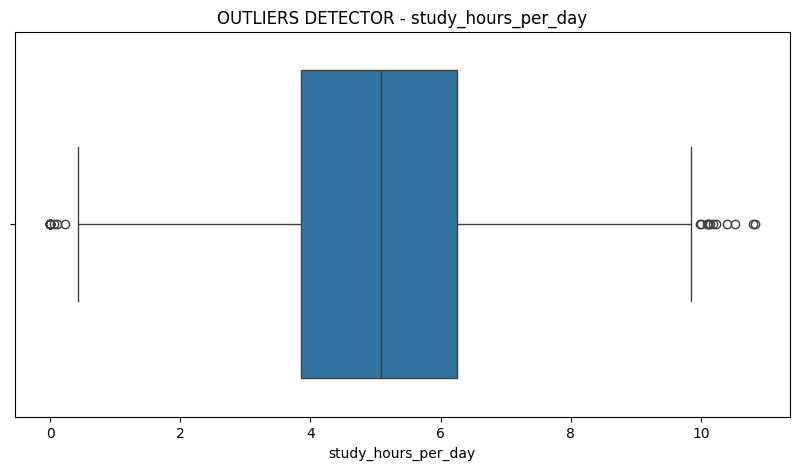

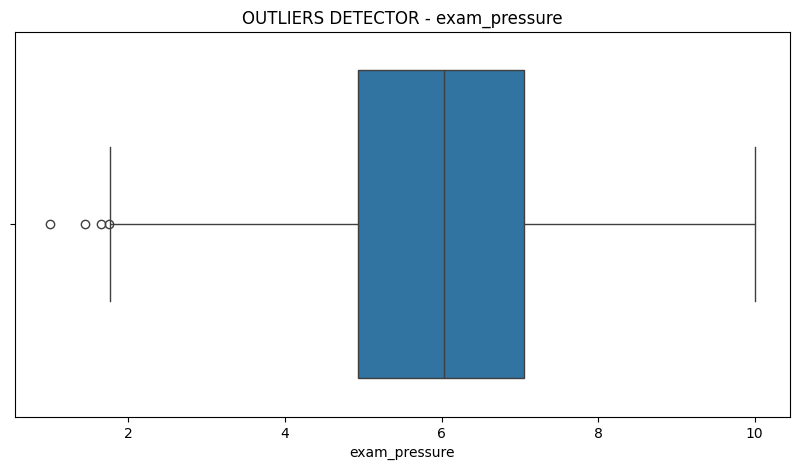

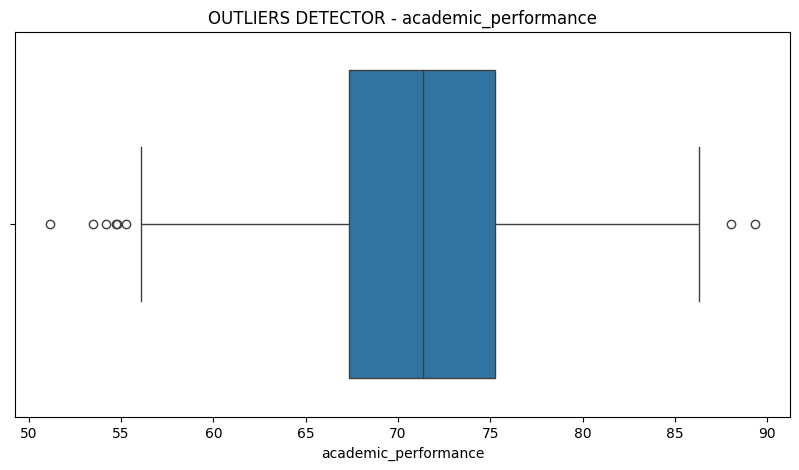

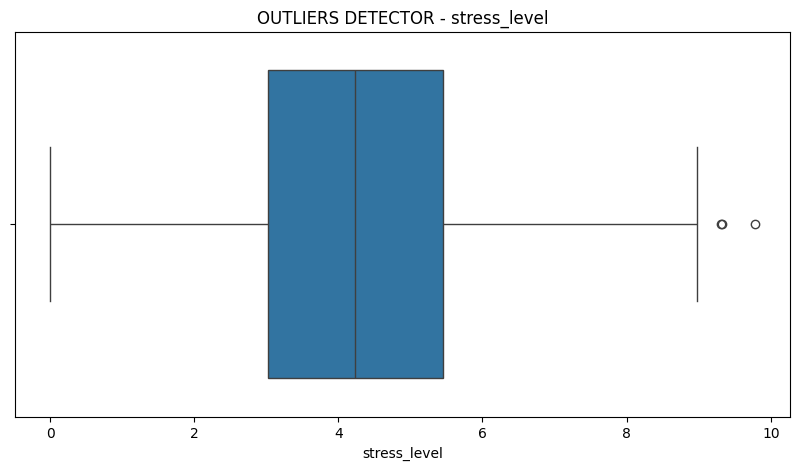

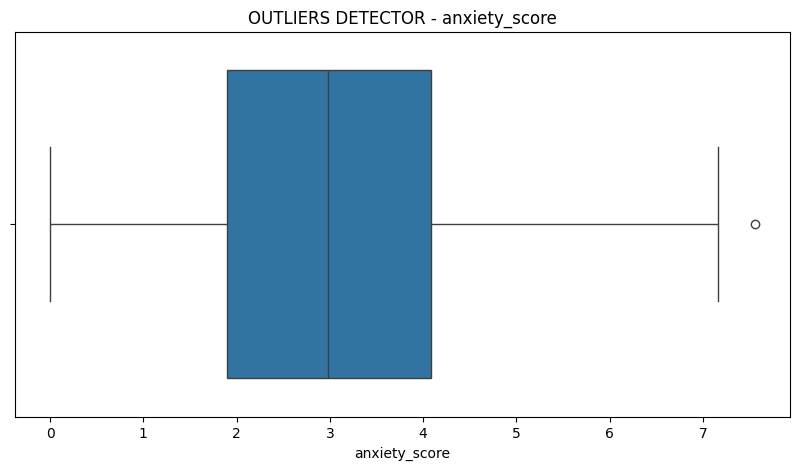

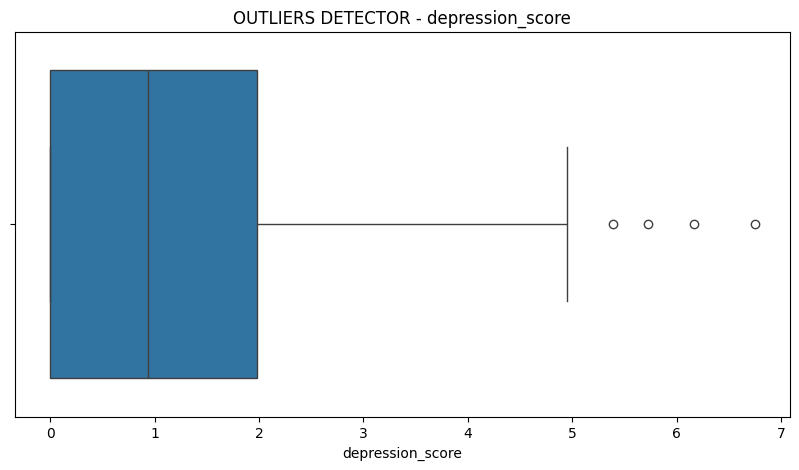

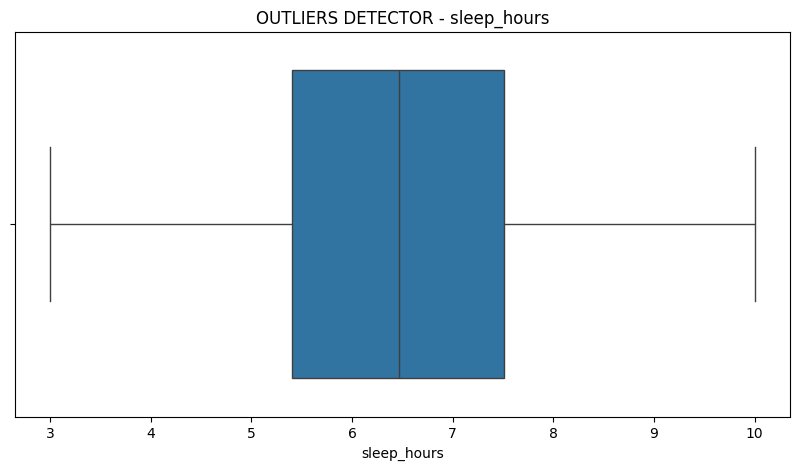

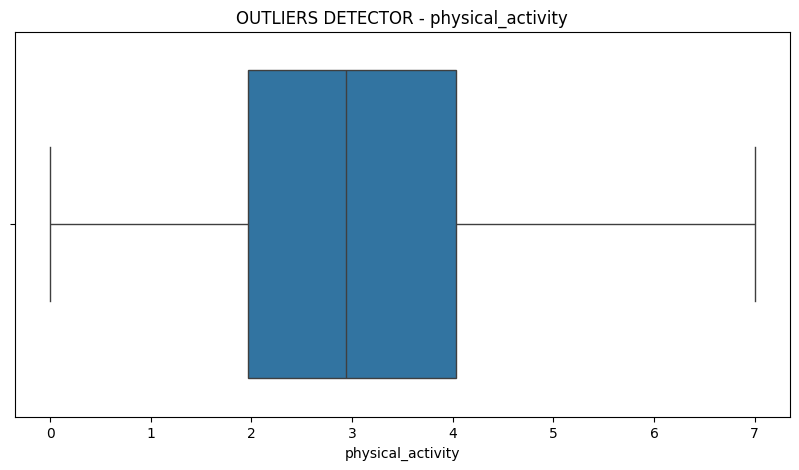

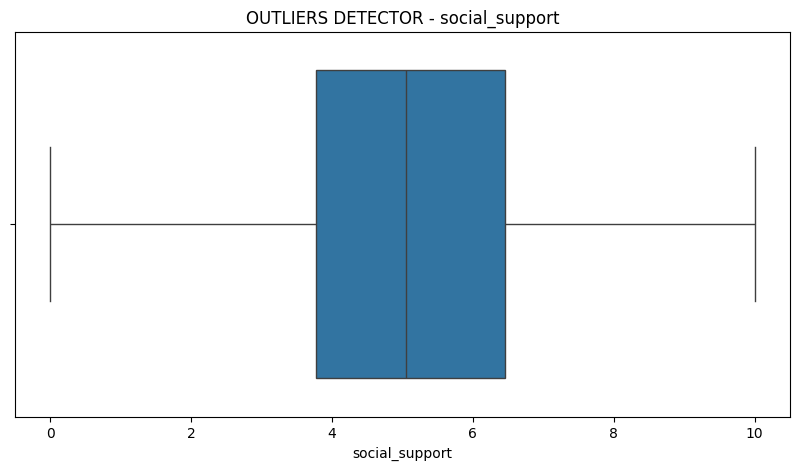

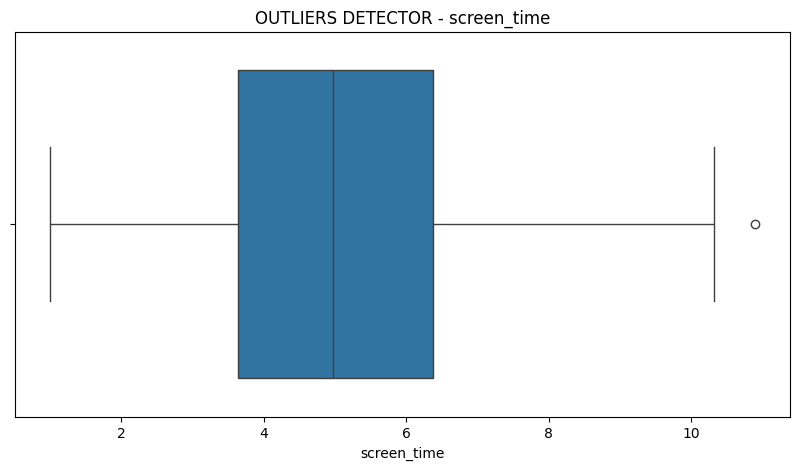

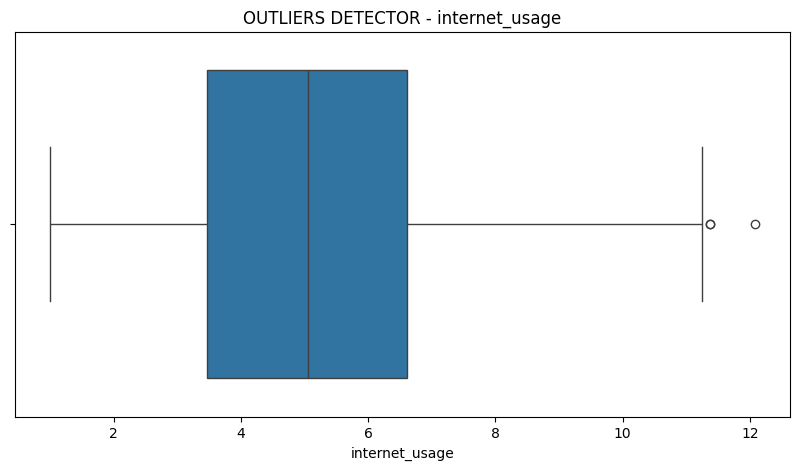

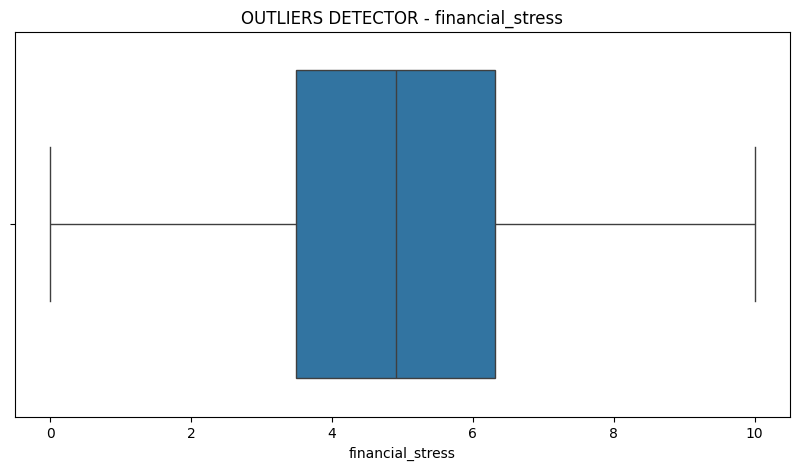

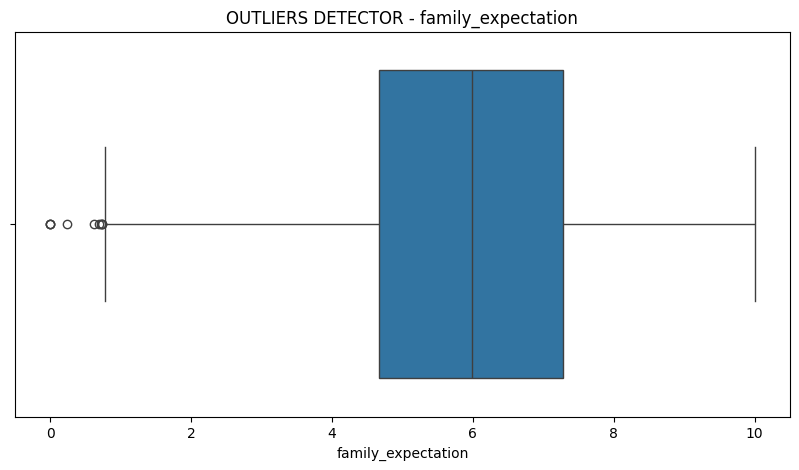

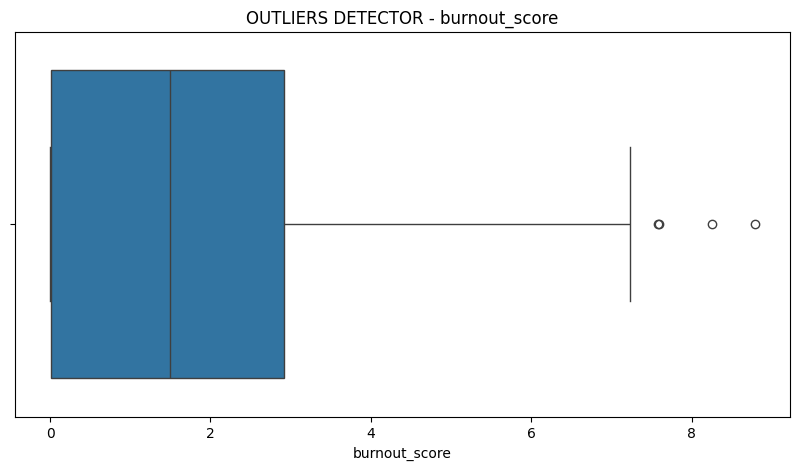

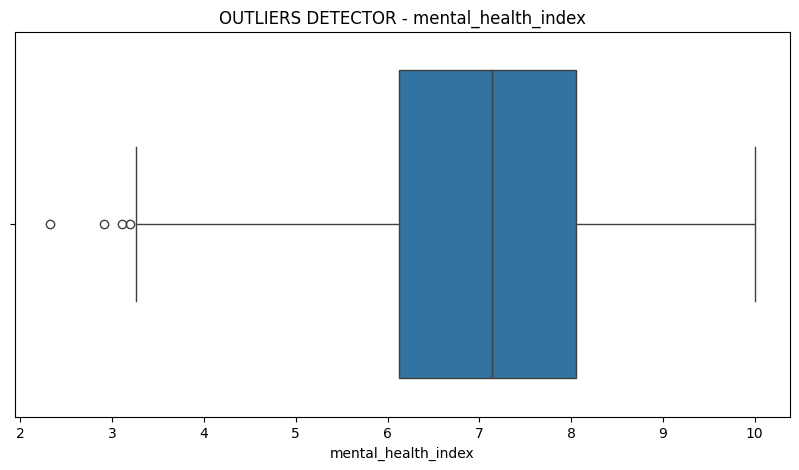

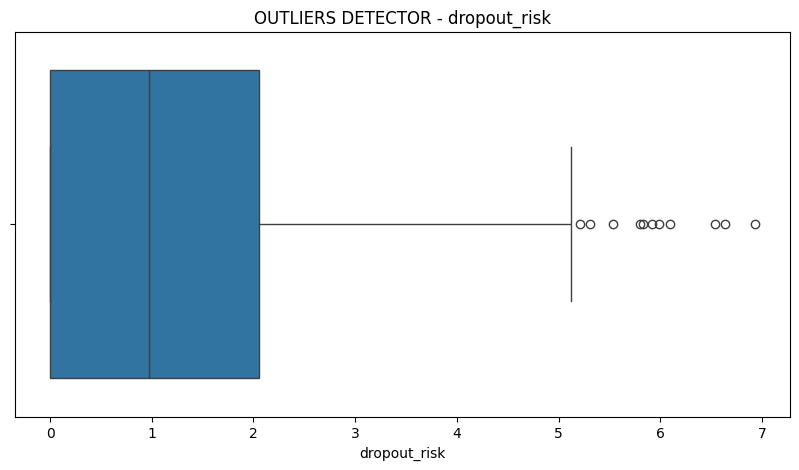

In [163]:


#outlier detection mengunkan boxplot
#kirta gunakan x_latih karna kita sudah spliting dahulu data nya
for column in kontinu: #disini kita menggabil data numerik saja karna outliers biasa nya hanya untuk data numerik
    plt.figure(figsize=(10, 5))
    sns.boxplot(x =x_latih[column])
    plt.title(f'OUTLIERS DETECTOR - {column}')
    plt.show()

In [164]:
#menghitung matrix kolerasi antar variabel numerik

kolerasi = x_latih_numeik.corr()
print(kolerasi)

                           age  academic_year  study_hours_per_day  \
age                   1.000000       0.026145             0.014526   
academic_year         0.026145       1.000000             0.007037   
study_hours_per_day   0.014526       0.007037             1.000000   
exam_pressure         0.036554      -0.006649             0.779648   
academic_performance -0.056484       0.038352             0.357631   
stress_level          0.050537      -0.002813             0.376476   
anxiety_score         0.054561      -0.003901             0.255538   
depression_score      0.043346      -0.015296             0.227801   
sleep_hours          -0.028407      -0.044302             0.000686   
physical_activity    -0.008450      -0.005882            -0.022462   
social_support       -0.003275       0.028433             0.007198   
screen_time           0.055495       0.044405             0.017228   
internet_usage        0.069928       0.056990             0.016332   
financial_stress    

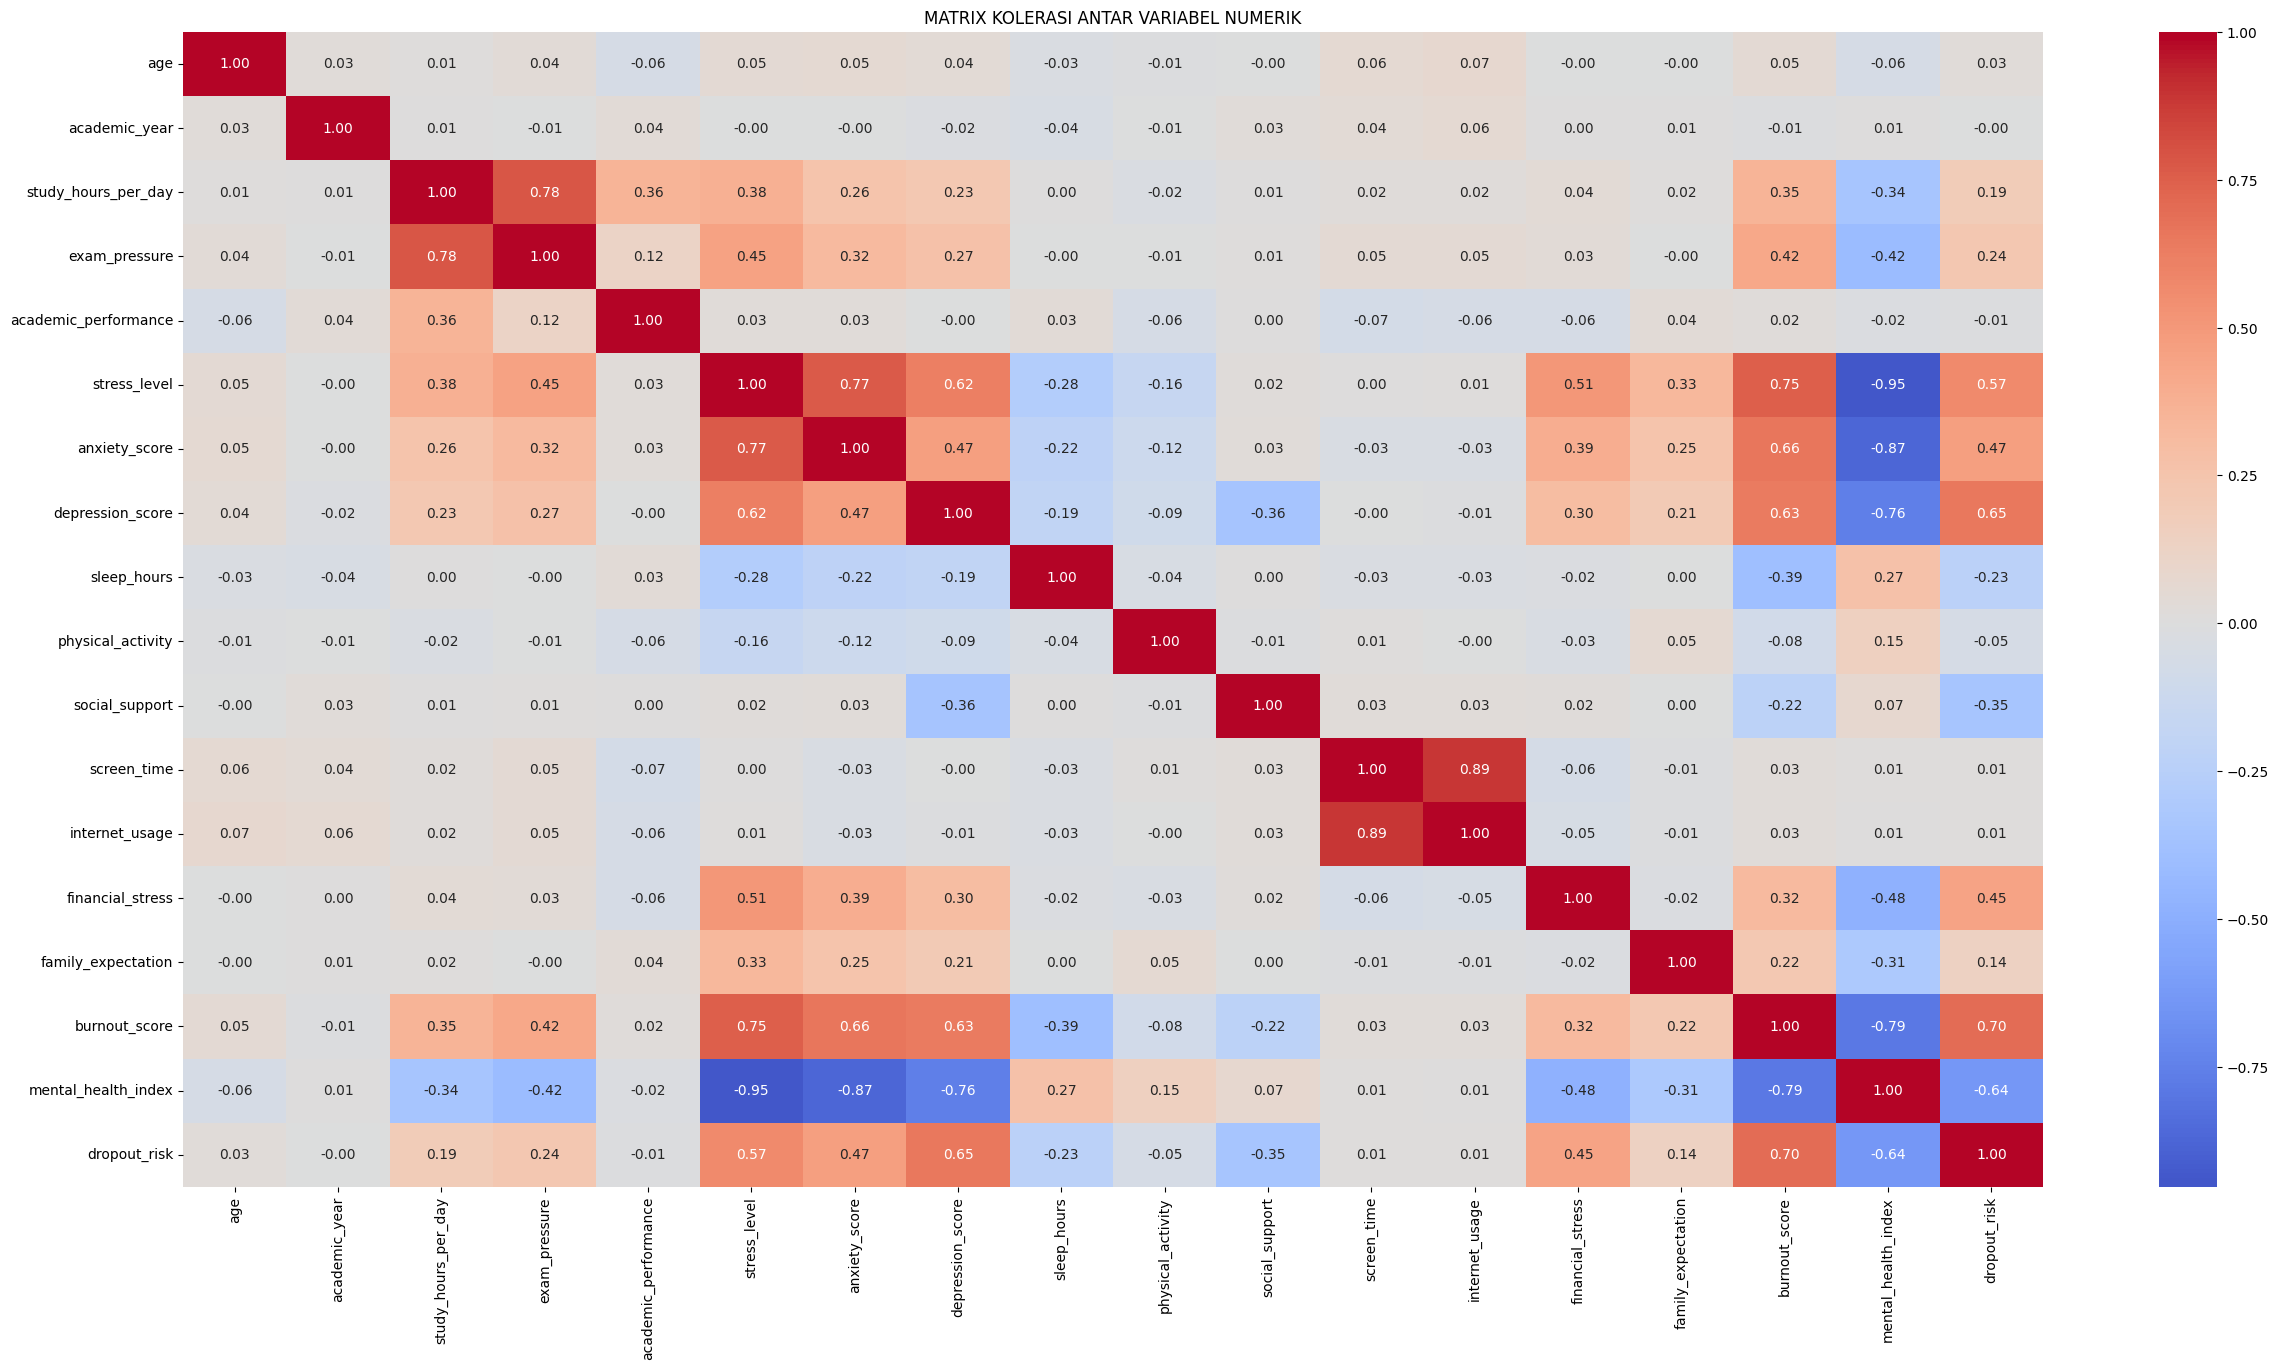

In [165]:
#visualisasi kolerasi

plt.figure(figsize=(30, 15))
sns.heatmap(kolerasi, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('MATRIX KOLERASI ANTAR VARIABEL NUMERIK')
plt.show()

In [166]:
#PREPROCESSING DATA
print(x_latih)

      age  gender  academic_year  study_hours_per_day  exam_pressure  \
836    18    Male              1             5.413068       5.994534   
575    27    Male              1             5.565487       6.731264   
557    19    Male              1             8.030170       8.544266   
1235   29    Male              2             7.952031       7.749328   
1360   19  Female              1             5.162216       6.973838   
...   ...     ...            ...                  ...            ...   
1130   28    Male              1             7.904527       8.065165   
1294   19  Female              4             6.286462       7.823477   
860    21    Male              2             4.399679       7.893692   
1459   29    Male              4             3.689182       5.838742   
1126   19  Female              2             6.593217       7.113224   

      academic_performance  stress_level  anxiety_score  depression_score  \
836              70.204900      5.367322       2.818262   

In [167]:
print(x_latih["stress_group"].unique())
print(x_latih["support_group"].unique())
print(x_latih["age_group"].unique())

['Medium (4-7)' 'Low (0-3)' 'High (8-10)']
['Medium (4-7)' 'High (8-10)' 'Low (0-3)']
['<20' '>23' '21-23']


In [168]:
#melakukan encoding data kategorik unutk data ordinal menggunakan mapping

mapping_item = {
    "stress_group" : {"Low (0-3)" : 0 , "Medium (4-7)" : 1, "High (8-10)" : 2},
    "support_group" : {"Low (0-3)" : 0 , "Medium (4-7)" : 1, "High (8-10)" : 2},
    "age_group" : {"<20" : 0 , "21-23" : 1, ">23" : 2}
    }

for key, valuue in mapping_item.items():
    x_latih[key] = x_latih[key].map(valuue)
    
    
print(x_latih.shape)
print(x_latih[["stress_group", "support_group", "age_group"]].isnull().sum())

(1400, 22)
stress_group     0
support_group    0
age_group        0
dtype: int64


In [169]:
print(x_latih["age_group"].unique())

[0 2 1]


In [170]:
#encoding data nominal menggunakan get dummes dan concat 

encod_nominal = pd.get_dummies(x_latih["gender"], drop_first=True)

x_latih = x_latih.drop(columns="gender")

x_latih = pd.concat([x_latih, encod_nominal], axis=1)

In [171]:
print(x_latih.shape)

(1400, 23)


In [172]:
#encoe  data target

mapping_target = {
    'Low' : 0, 'Medium' : 1, 'High' : 2
}

y_latih= y_latih['risk_level'].map(mapping_target)

In [173]:
print(x_latih.columns.tolist())

['age', 'academic_year', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'burnout_score', 'mental_health_index', 'dropout_risk', 'stress_group', 'support_group', 'age_group', 'Male', 'Other']


In [174]:
#bagian scaling data dan trasnfrom data

data_scaling = x_latih.select_dtypes(include=['float64','int64'])
print(data_scaling)

      age  academic_year  study_hours_per_day  exam_pressure  \
836    18              1             5.413068       5.994534   
575    27              1             5.565487       6.731264   
557    19              1             8.030170       8.544266   
1235   29              2             7.952031       7.749328   
1360   19              1             5.162216       6.973838   
...   ...            ...                  ...            ...   
1130   28              1             7.904527       8.065165   
1294   19              4             6.286462       7.823477   
860    21              2             4.399679       7.893692   
1459   29              4             3.689182       5.838742   
1126   19              2             6.593217       7.113224   

      academic_performance  stress_level  anxiety_score  depression_score  \
836              70.204900      5.367322       2.818262          2.524558   
575              72.052354      3.875417       4.097471          2.370141   


In [175]:
#menghitung skwekness 

data_skw = data_scaling.skew()

print('========== HASIL SCALING ==========')
print(data_skw)

========== HASIL SCALING ==========
age                    -0.034537
academic_year          -0.001612
study_hours_per_day    -0.021786
exam_pressure          -0.043881
academic_performance   -0.009480
stress_level            0.068803
anxiety_score           0.090404
depression_score        0.925361
sleep_hours             0.021586
physical_activity       0.170814
social_support         -0.011937
screen_time             0.140241
internet_usage          0.180099
financial_stress        0.065245
family_expectation     -0.116006
burnout_score           0.767313
mental_health_index    -0.235861
dropout_risk            1.019883
stress_group            0.000007
support_group           0.005076
age_group              -0.334544
dtype: float64


In [176]:
print(data_scaling.shape)
print(data_scaling.columns.tolist())

(1400, 21)
['age', 'academic_year', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'burnout_score', 'mental_health_index', 'dropout_risk', 'stress_group', 'support_group', 'age_group']


In [177]:
#memisahkan data yang skw

distribusi_normal = []
distribusi_skw = []


for i in data_skw.index:
    if data_skw[i] >= -0.5 and data_skw[i] <= 0.5:
        distribusi_normal.append(i)
        
    else:
        distribusi_skw.append(i)
        
print('=========== HASIL PEMISAHAN DATA ==========')
print(distribusi_normal)
print(distribusi_skw)

=========== HASIL PEMISAHAN DATA ==========
['age', 'academic_year', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'mental_health_index', 'stress_group', 'support_group', 'age_group']
['depression_score', 'burnout_score', 'dropout_risk']


In [178]:
#melakukan scaling pada data nromal 

scaling = StandardScaler()
data_scaling[distribusi_normal] = scaling.fit_transform(data_scaling[distribusi_normal])

In [179]:
#transfrom data skw

power = PowerTransformer(method='yeo-johnson')
data_scaling[distribusi_skw] = power.fit_transform(x_latih[distribusi_skw])

In [180]:
#menggabungkan kemabnli hasil scaling dan transfrom ke x_latih

x_latih.update(data_scaling)
x_latih.shape

(1400, 23)

In [181]:
#MENGHITUNG KOLORASI PERSTION 
kolerasi_terget = x_latih.corrwith(y_latih)
print(kolerasi_terget)

age                     0.027851
academic_year          -0.003134
study_hours_per_day     0.254183
exam_pressure           0.322383
academic_performance   -0.011514
stress_level            0.596946
anxiety_score           0.512284
depression_score        0.495410
sleep_hours            -0.288573
physical_activity      -0.052580
social_support         -0.200984
screen_time             0.021850
internet_usage          0.018815
financial_stress        0.246070
family_expectation      0.179106
burnout_score           0.709081
mental_health_index    -0.632866
dropout_risk            0.540352
stress_group            0.203384
support_group          -0.187738
age_group               0.041613
Male                   -0.007972
Other                  -0.009728
dtype: float64


In [182]:
kolerasi_terget = pd.DataFrame(kolerasi_terget)

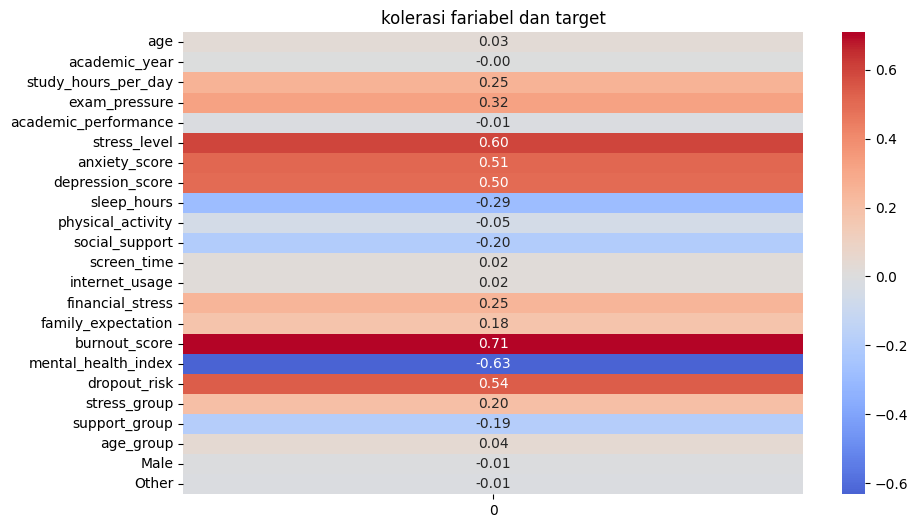

In [183]:
plt.figure(figsize=(10, 6))
plt.title("kolerasi fariabel dan target")
sns.heatmap(kolerasi_terget, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.show()

In [184]:
#menguturkan nilai kolerasi 

kolerasi_terget.sort_values(by=0, ascending=False)
print(kolerasi_terget)

                             0
age                   0.027851
academic_year        -0.003134
study_hours_per_day   0.254183
exam_pressure         0.322383
academic_performance -0.011514
stress_level          0.596946
anxiety_score         0.512284
depression_score      0.495410
sleep_hours          -0.288573
physical_activity    -0.052580
social_support       -0.200984
screen_time           0.021850
internet_usage        0.018815
financial_stress      0.246070
family_expectation    0.179106
burnout_score         0.709081
mental_health_index  -0.632866
dropout_risk          0.540352
stress_group          0.203384
support_group        -0.187738
age_group             0.041613
Male                 -0.007972
Other                -0.009728


In [185]:
#memilih data yang akan kita buang 

batas = 0.04
for i in kolerasi_terget:
    koleras_kaut = kolerasi_terget[i].abs() >= batas
    koleras_lemah = kolerasi_terget[i].abs() < batas
    
print('======== hasil data  ===========')
print("======== fitur kuat ============")
print(koleras_kaut)
print('======== fitur lemah ===========')
print(koleras_lemah)

======== hasil data  ===========
======== fitur kuat ============
age                     False
academic_year           False
study_hours_per_day      True
exam_pressure            True
academic_performance    False
stress_level             True
anxiety_score            True
depression_score         True
sleep_hours              True
physical_activity        True
social_support           True
screen_time             False
internet_usage          False
financial_stress         True
family_expectation       True
burnout_score            True
mental_health_index      True
dropout_risk             True
stress_group             True
support_group            True
age_group                True
Male                    False
Other                   False
Name: 0, dtype: bool
======== fitur lemah ===========
age                      True
academic_year            True
study_hours_per_day     False
exam_pressure           False
academic_performance     True
stress_level            False
anxiety_sc

In [186]:
#meihskan variabel yang kurang berkolerasi terhadap target

x_latih_final = x_latih.drop(columns=['age', 'academic_year', 'academic_performance', 'screen_time','internet_usage', 'Male', 'Other' ])
print(x_latih_final)

      study_hours_per_day  exam_pressure  stress_level  anxiety_score  \
836              0.181857      -0.009033      0.654986      -0.105646   
575              0.259647       0.475262     -0.212291       0.725508   
557              1.517556       1.667050      0.487408       0.806590   
1235             1.477676       1.144492      1.008776       0.766933   
1360             0.053829       0.634719      0.101266      -0.162737   
...                   ...            ...           ...            ...   
1130             1.453432       1.352109     -1.167221      -1.936785   
1294             0.627614       1.193235     -0.765052      -0.532315   
860             -0.335350       1.239391      0.308213       1.709761   
1459            -0.697969      -0.111443      0.187169      -0.972142   
1126             0.784173       0.726346      0.516588       0.128695   

      depression_score  sleep_hours  physical_activity  social_support  \
836           1.146014    -2.239505           0.0

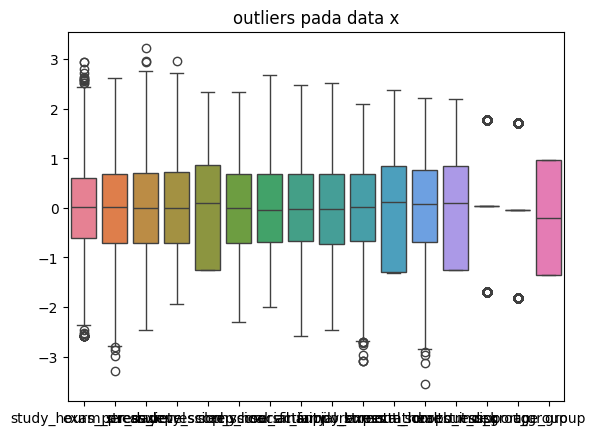

In [187]:
#detection dan handling outliers

#detection outliers menggunakan boxplot 

plt.Figure(figsize=(10, 6))
plt.title("outliers pada data x")
sns.boxplot(data=x_latih_final)
plt.show()


In [188]:
#handling outliers menggunakan metode capping


def outliers_capp(kolom):
    Q1 = kolom.quantile(0.25)
    Q3 = kolom.quantile(0.57)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return lower, upper

for i in x_latih_final:
        #disini kita menggunakann tuple unpacking
        lower, upper = outliers_capp(x_latih_final[i])
        x_latih_final[i] = x_latih_final[i].clip(lower,upper)
        
print(x_latih_final)

      study_hours_per_day  exam_pressure  stress_level  anxiety_score  \
836              0.181857      -0.009033      0.654986      -0.105646   
575              0.259647       0.475262     -0.212291       0.725508   
557              1.340124       1.609782      0.487408       0.806590   
1235             1.340124       1.144492      1.008776       0.766933   
1360             0.053829       0.634719      0.101266      -0.162737   
...                   ...            ...           ...            ...   
1130             1.340124       1.352109     -1.167221      -1.936785   
1294             0.627614       1.193235     -0.765052      -0.532315   
860             -0.335350       1.239391      0.308213       1.505962   
1459            -0.697969      -0.111443      0.187169      -0.972142   
1126             0.784173       0.726346      0.516588       0.128695   

      depression_score  sleep_hours  physical_activity  social_support  \
836           1.146014    -2.075936           0.0

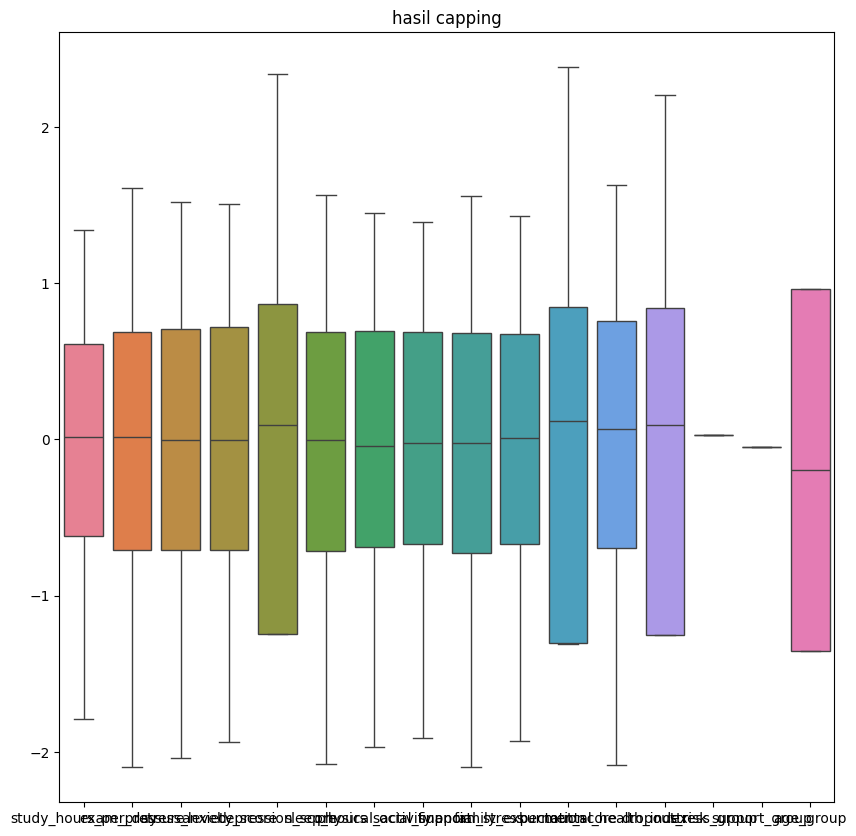

In [189]:
plt.figure(figsize=(10 , 10))
plt.title('hasil capping')
sns.boxplot(data=x_latih_final)
plt.show()

In [190]:
#penganan imbalence data pda data x


smote_x = SMOTE(random_state=42, k_neighbors=5)

x_data, y_data = smote_x.fit_resample(x_latih_final, y_latih)

print(x_data.shape)
print(y_data.value_counts())

(3207, 16)
risk_level
1    1069
0    1069
2    1069
Name: count, dtype: int64


In [191]:
#cek hasil oversampel 

print(x_data.shape)


(3207, 16)


In [192]:
print(y_data.value_counts())

risk_level
1    1069
0    1069
2    1069
Name: count, dtype: int64


Matplotlib version: 3.7.5


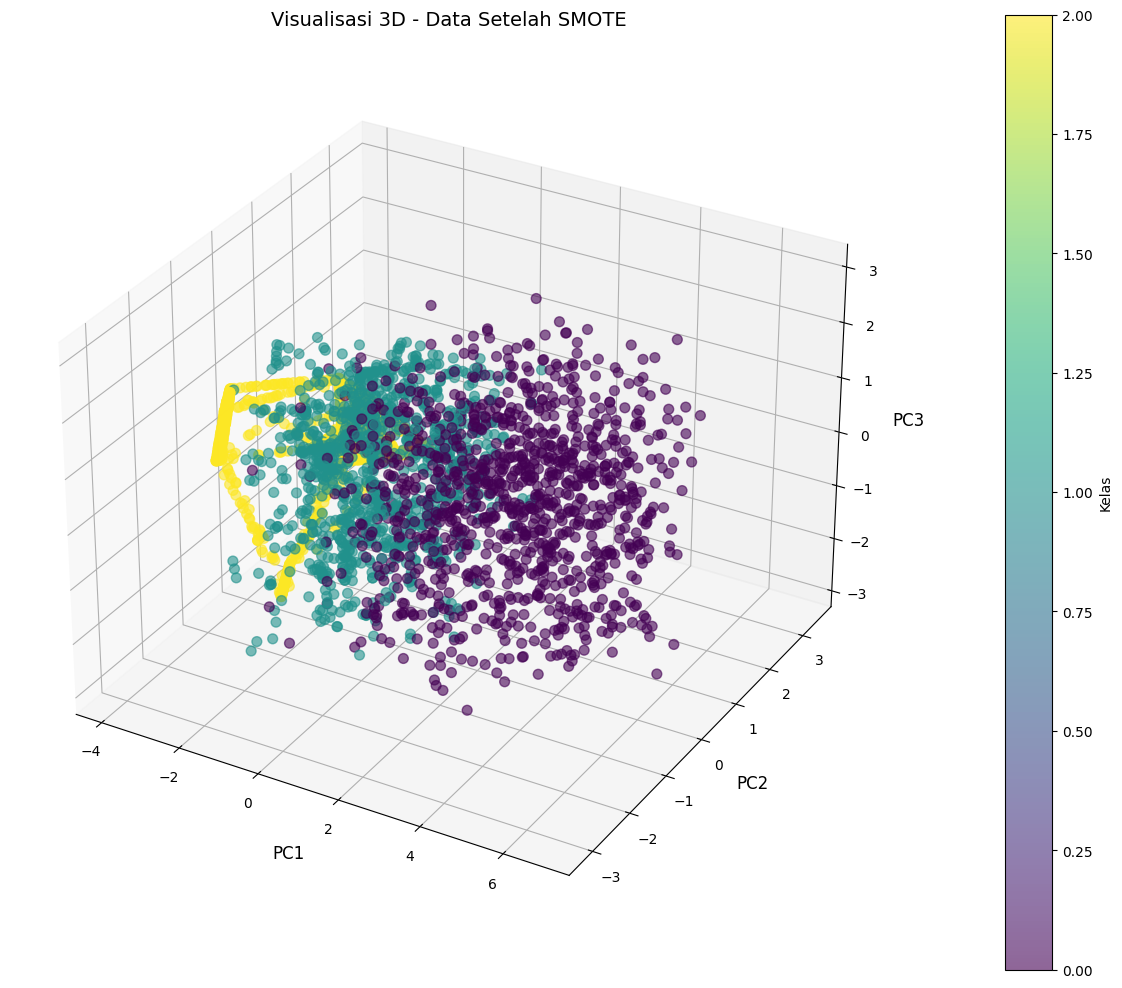

In [193]:


# Cek versi matplotlib
import matplotlib
print(f"Matplotlib version: {matplotlib.__version__}")

# Reduksi ke 3D
pca = PCA(n_components=3)
x_3d = pca.fit_transform(x_data)

# Plot 3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot dengan warna per kelas
scatter = ax.scatter(x_3d[:, 0], x_3d[:, 1], x_3d[:, 2],
                     c=y_data, cmap='viridis', alpha=0.6, s=50)

# Label
ax.set_xlabel('PC1', fontsize=12, labelpad=10)
ax.set_ylabel('PC2', fontsize=12, labelpad=10)
ax.set_zlabel('PC3', fontsize=12, labelpad=10)
ax.set_title('Visualisasi 3D - Data Setelah SMOTE', fontsize=14, pad=20)

# Colorbar
plt.colorbar(scatter, label='Kelas', pad=0.1)

# Grid
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

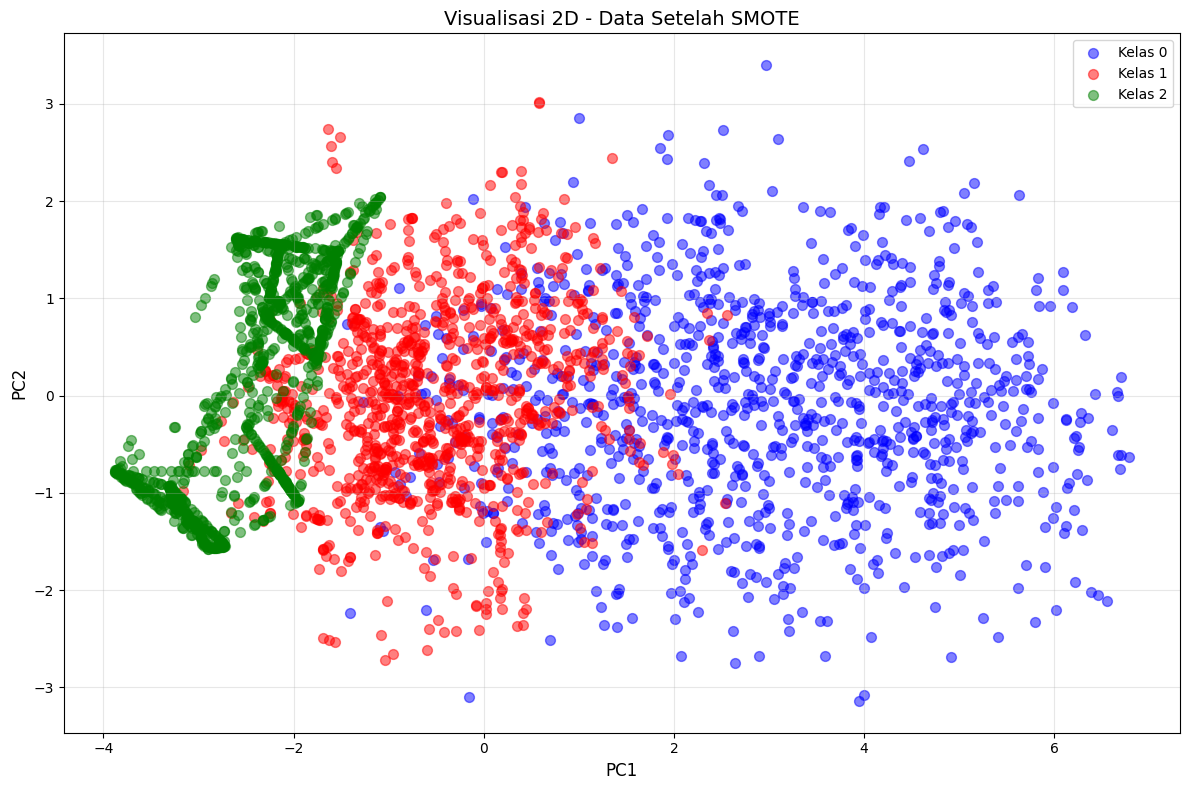

In [194]:
# Reduksi ke 2D
pca = PCA(n_components=2)
x_2d = pca.fit_transform(x_data)

# Buat figure
plt.figure(figsize=(12, 8))

# Plot setiap kelas dengan warna berbeda
# Kelas 0
plt.scatter(x_2d[y_data==0, 0], x_2d[y_data==0, 1], 
            c='blue', label='Kelas 0', alpha=0.5, s=50)

# Kelas 1
plt.scatter(x_2d[y_data==1, 0], x_2d[y_data==1, 1], 
            c='red', label='Kelas 1', alpha=0.5, s=50)

# Kelas 2
plt.scatter(x_2d[y_data==2, 0], x_2d[y_data==2, 1], 
            c='green', label='Kelas 2', alpha=0.5, s=50)

# Label dan title
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('Visualisasi 2D - Data Setelah SMOTE', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()